# Table of Contents

## Section 1. Setup

## Section 2. Load the Dataset

## Section 3. Visualization

### 3.1 Weekly Volume and Participation
- Graph 1. Weekly AI Cover Video Count
- Graph 2. Weekly Active AI Cover Channel Count

### 3.2 New Channel Creation and Early Entry
- Graph 3. Weekly New Channel Count
- Graph 4. Channel Creation Date Heatmap
- Graph 5. New Channels Uploading AI Cover Within 7 Days

### 3.3 New Entrants vs Reactivated Channels
- Graph 6. Weekly New Entrant Channels vs Reactivated Channels
- Graph 7. Weekly Supply Share Decomposition (Supplementary)

### 3.4 Reactivation Dynamics
- Graph 8. Reactivated Upload Share (28-day, 56-day, 84-day Thresholds)
- Graph 9. Reactivated Upload Share (56-day Threshold)
- Graph 10. Weekly Count of Reactivated Channels (28-day, 56-day, 84-day Thresholds)
- Graph 11. Share of Active Channels that are Reactivated

### 3.5 Cohort Dynamics
- Graph 12. Weekly Upload Count of the Pre-announcement Fixed Cohort
- Graph 13. Weekly Active Channel Count of the Pre-announcement Fixed Cohort
- Graph 14. Average Upload Count per Channel in the Pre-announcement Fixed Cohort

### 3.6 Market Structure and Channel Heterogeneity
- Graph 15. Upload Dynamics of the Top 10 Channels
- Graph 16. Upload Concentration by Rank Cutoffs (Top 1, Top 5, Top 10)
- Graph 17. Market Concentration and Small-Channel Supply Share (CR4, HHI, Gini, and Upload Share from Channels with Fewer than 100 Subscribers)
- Graph 18. Median Subscriber Count by Channel Cohort
- Graph 19. Entropy Over Time
- Graph 20. Upload Comparison between heavy Channels and light Channels
- Graph 21. Small-Channel Upload Share Comparison (Fewer than 100 Subscribers, Fewer than 500 Subscribers, Bottom 30%)

### 3.7 Transition Visualization
- Graph 22. Upload-weighted Alluvial Plot
- Graph 23. 100% Stacked Bar Version

## Section 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ---------------------------------------------------------
# Project paths
# ---------------------------------------------------------
# Keep file paths explicit so that coauthors can immediately see
# which raw files are used in the analysis.

DATA_DIR = Path("data")

VIDEOS_02_PATH = DATA_DIR / "02_videos_meta.csv"
VIDEOS_05_PATH = DATA_DIR / "05_uploads_meta.csv"
CHANNELS_PATH  = DATA_DIR / "03_channels_meta.csv"

# Output folder for figures / tables if needed later
OUTPUT_DIR = DATA_DIR / "visualization_outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

DATA_DIR: /Users/haewon/Downloads/유투브 데이터/data
OUTPUT_DIR: /Users/haewon/Downloads/유투브 데이터/data/visualization_outputs


In [3]:
# ---------------------------------------------------------
# Analysis dates
# ---------------------------------------------------------
# We define the broad calendar window here.
# Later, in weekly visualization sections, weekly plots will be aligned to:
#   - the first Monday within the analysis window
#   - the last observed week with actual activity
#
# This avoids misleading partial first and partial last weeks.

ANALYSIS_START_RAW = pd.Timestamp("2023-09-01", tz="UTC")
ANALYSIS_END_RAW   = pd.Timestamp("2025-08-31 23:59:59", tz="UTC")

# Policy-related dates
PRE_ANNOUNCEMENT_DATE = pd.Timestamp("2023-11-14")
POLICY_DATE           = pd.Timestamp("2024-03-18")

# Optional later milestone sometimes used in robustness checks
MONETIZATION_DATE     = pd.Timestamp("2025-07-15")

print("ANALYSIS_START_RAW:", ANALYSIS_START_RAW)
print("ANALYSIS_END_RAW  :", ANALYSIS_END_RAW)
print("PRE_ANNOUNCEMENT_DATE:", PRE_ANNOUNCEMENT_DATE)
print("POLICY_DATE          :", POLICY_DATE)
print("MONETIZATION_DATE    :", MONETIZATION_DATE)

ANALYSIS_START_RAW: 2023-09-01 00:00:00+00:00
ANALYSIS_END_RAW  : 2025-08-31 23:59:59+00:00
PRE_ANNOUNCEMENT_DATE: 2023-11-14 00:00:00
POLICY_DATE          : 2024-03-18 00:00:00
MONETIZATION_DATE    : 2025-07-15 00:00:00


In [4]:
# ---------------------------------------------------------
# Minimal helper functions
# ---------------------------------------------------------
# In this notebook, we intentionally keep global helpers minimal.
# The goal is to reduce hidden dependencies and make later sections easier to read.
#
# These helpers are general enough to be reused across sections without creating
# confusion about section-specific logic.

def to_datetime_utc(series):
    """
    Convert a pandas Series to timezone-aware UTC datetime.
    Invalid parsing becomes NaT.
    """
    return pd.to_datetime(series, utc=True, errors="coerce")


def clean_string_id(series):
    """
    Standardize id-like columns such as video_id or channel_id.
    This helps prevent merge mismatches caused by whitespace.
    """
    return series.astype(str).str.strip()

In [5]:
# ---------------------------------------------------------
# Early file existence check
# ---------------------------------------------------------
# It is better to fail early if a required raw file is missing.
# This makes the notebook easier to reproduce for coauthors.

required_files = [VIDEOS_02_PATH, VIDEOS_05_PATH, CHANNELS_PATH]

for path in required_files:
    if not path.exists():
        raise FileNotFoundError(f"Missing required file: {path}")

print("All required files are available:")
for path in required_files:
    print("-", path)

All required files are available:
- data/02_videos_meta.csv
- data/05_uploads_meta.csv
- data/03_channels_meta.csv


In [6]:
# ---------------------------------------------------------
# Load raw input tables
# ---------------------------------------------------------
# Section 1 only loads raw data.
# We do not merge or transform heavily yet.
# This makes it easier for coauthors to inspect the original inputs first.

videos_02 = pd.read_csv(VIDEOS_02_PATH, low_memory=False)
videos_05 = pd.read_csv(VIDEOS_05_PATH, low_memory=False)
channels_raw = pd.read_csv(CHANNELS_PATH, low_memory=False)

print("videos_02 shape :", videos_02.shape)
print("videos_05 shape :", videos_05.shape)
print("channels_raw shape:", channels_raw.shape)

videos_02 shape : (11189, 15)
videos_05 shape : (561102, 14)
channels_raw shape: (3993, 7)


In [7]:
# ---------------------------------------------------------
# Quick schema preview
# ---------------------------------------------------------
# Before doing any transformation, we inspect column names.
# This helps collaborators confirm what fields exist and what is missing.

print("videos_02 columns:")
print(sorted(videos_02.columns.tolist()))

print("\nvideos_05 columns:")
print(sorted(videos_05.columns.tolist()))

print("\nchannels_raw columns:")
print(sorted(channels_raw.columns.tolist()))

videos_02 columns:
['channel_id', 'collected_at_utc', 'duration_sec', 'is_ai_cover', 'like_count', 'published_at', 'search_window_start', 'video_description', 'video_id', 'video_tags', 'video_title', 'view_count', 'week_start_date', 'weeks_from_policy1', 'weeks_from_policy2']

videos_05 columns:
['channel_id', 'collected_at_utc', 'duration_sec', 'is_ai_cover', 'like_count', 'published_at', 'video_description', 'video_id', 'video_tags', 'video_title', 'view_count', 'week_start_date', 'weeks_from_policy1', 'weeks_from_policy2']

channels_raw columns:
['channel_created_at', 'channel_id', 'channel_title', 'channel_video_count', 'collected_at_utc', 'subscriber_count', 'uploads_playlist_id']


In [8]:
# ---------------------------------------------------------
# Basic raw-file checks
# ---------------------------------------------------------
# We only check for truly essential columns here.
# More detailed assumptions will be checked in later sections close to usage.

required_video_cols = ["video_id", "channel_id", "published_at", "is_ai_cover"]
required_channel_cols = ["channel_id", "channel_created_at"]

missing_video_02 = [c for c in required_video_cols if c not in videos_02.columns]
missing_video_05 = [c for c in required_video_cols if c not in videos_05.columns]
missing_channels = [c for c in required_channel_cols if c not in channels_raw.columns]

if missing_video_02:
    raise KeyError(f"videos_02 is missing required columns: {missing_video_02}")
if missing_video_05:
    raise KeyError(f"videos_05 is missing required columns: {missing_video_05}")
if missing_channels:
    raise KeyError(f"channels_raw is missing required columns: {missing_channels}")

print("Basic raw-file checks passed.")

Basic raw-file checks passed.


## Section 2. Load the Dataset

**핵심 객체**
1. videos : 02_videos_meta + 05_uploads_meta 결합한 video-level dataset
2. channels : 정리된 channel metadata
3. base : video-level + channel metadata 결합 테이블
4. ai_all : 전체 기간 AI-cover 업로드
5. ai_window : 분석기간 내 AI-cover 업로드
6. channels_in_sample : AI-cover 표본에 등장하는 채널
7. channels_window : 분석기간 내 생성된 표본 채널

In [9]:
# ---------------------------------------------------------
# Section 2.1
# Check the raw inputs loaded in Section 1
# ---------------------------------------------------------
# We start by confirming that the raw tables from Section 1
# are available in memory before building the merged dataset.

print("videos_02 loaded:", "videos_02" in globals())
print("videos_05 loaded:", "videos_05" in globals())
print("channels_raw loaded:", "channels_raw" in globals())

if "videos_02" not in globals() or "videos_05" not in globals() or "channels_raw" not in globals():
    raise RuntimeError("Please run Section 1 first. Raw input tables are not available.")

videos_02 loaded: True
videos_05 loaded: True
channels_raw loaded: True


In [10]:
# ---------------------------------------------------------
# Section 2.2
# Copy raw tables into working objects
# ---------------------------------------------------------
# We create local working copies so later transformations do not
# accidentally modify the raw input tables loaded in Section 1.

videos_02_work = videos_02.copy()
videos_05_work = videos_05.copy()
channels_work = channels_raw.copy()

print("videos_02_work:", videos_02_work.shape)
print("videos_05_work:", videos_05_work.shape)
print("channels_work :", channels_work.shape)

videos_02_work: (11189, 15)
videos_05_work: (561102, 14)
channels_work : (3993, 7)


In [11]:
# ---------------------------------------------------------
# Section 2.3
# Keep only the shared columns across the two video-level tables
# ---------------------------------------------------------
# Why do this?
# - 02_videos_meta.csv and 05_uploads_meta.csv are both video-level tables
# - but their column sets may differ slightly
# - using only common columns avoids accidental schema mismatch
# - this makes the merge step easier for collaborators to inspect

common_video_cols = sorted(set(videos_02_work.columns).intersection(set(videos_05_work.columns)))

print("Number of common video-level columns:", len(common_video_cols))
print(common_video_cols)

Number of common video-level columns: 14
['channel_id', 'collected_at_utc', 'duration_sec', 'is_ai_cover', 'like_count', 'published_at', 'video_description', 'video_id', 'video_tags', 'video_title', 'view_count', 'week_start_date', 'weeks_from_policy1', 'weeks_from_policy2']


In [12]:
# ---------------------------------------------------------
# Section 2.4
# Build the merged video-level dataset
# ---------------------------------------------------------
# We vertically concatenate the two video-level datasets using only
# the columns that exist in both files.
#
# Then we deduplicate by video_id.
# This is important because the same video can appear in both sources.

videos = pd.concat(
    [
        videos_02_work[common_video_cols].copy(),
        videos_05_work[common_video_cols].copy()
    ],
    ignore_index=True
)

# Standardize key identifiers before deduplication
videos["video_id"] = clean_string_id(videos["video_id"])
videos["channel_id"] = clean_string_id(videos["channel_id"])

before_dedup = len(videos)
videos = videos.drop_duplicates(subset=["video_id"]).copy()
after_dedup = len(videos)

print("videos before dedup:", before_dedup)
print("videos after dedup :", after_dedup)
print("videos shape       :", videos.shape)

videos before dedup: 572291
videos after dedup : 572291
videos shape       : (572291, 14)


In [13]:
# ---------------------------------------------------------
# Section 2.5
# Clean the core video-level fields
# ---------------------------------------------------------
# We standardize the fields that will be used repeatedly in later sections:
# - published_at
# - is_ai_cover
# - week
#
# Note:
# We do not define weekly plotting logic here.
# We only make sure a weekly date variable exists.

# Parse upload timestamp
videos["published_at"] = to_datetime_utc(videos["published_at"])

# Standardize AI-cover indicator
videos["is_ai_cover"] = pd.to_numeric(videos["is_ai_cover"], errors="coerce")

# Build a week variable if needed
# We align weeks to Monday because later sections will construct weekly plots
# from the first Monday inside the analysis window.
if "week_start_date" in videos.columns:
    videos["week"] = to_datetime_utc(videos["week_start_date"])
else:
    published_temp = pd.to_datetime(videos["published_at"], utc=True, errors="coerce")
    videos["week"] = pd.Series(
        [
            pd.NaT if pd.isna(x) else x.to_period("W-SUN").start_time
            for x in published_temp
        ],
        index=videos.index
    ).pipe(pd.to_datetime, utc=True)

# Optional numeric columns: convert only if they exist
optional_video_numeric_cols = [
    "view_count", "like_count", "duration_sec",
    "weeks_from_policy1", "weeks_from_policy2"
]

for col in optional_video_numeric_cols:
    if col in videos.columns:
        videos[col] = pd.to_numeric(videos[col], errors="coerce")

print(videos[["video_id", "channel_id", "published_at", "week", "is_ai_cover"]].head())

      video_id                channel_id              published_at  \
0  --3m-wH7xVo  UC-DadGUHxVxgs_gwadyf5VQ 2024-01-23 13:14:28+00:00   
1  --8hdkEhVO0  UCZO_SjK_cZHbR8ePQwHTxEQ 2023-10-07 12:29:25+00:00   
2  --Gsy8rmw3I  UCaGjNXckDVvMa_kCCQGfoKw 2025-01-13 16:45:39+00:00   
3  --Zd4iRSAwM  UC-HPVjsGX6kmx9FXmBmf_5A 2024-01-02 11:58:18+00:00   
4  -09A-WFUVtc  UCciWHiZfVbF-ylV4KCIKqyg 2024-10-22 15:17:24+00:00   

                       week  is_ai_cover  
0 2024-01-22 00:00:00+00:00            0  
1 2023-10-02 00:00:00+00:00            1  
2 2025-01-13 00:00:00+00:00            1  
3 2024-01-01 00:00:00+00:00            1  
4 2024-10-21 00:00:00+00:00            1  


In [14]:
# ---------------------------------------------------------
# Section 2.6
# Clean the channel-level dataset
# ---------------------------------------------------------
# The channel metadata table will be used repeatedly in later sections:
# - new channel creation
# - subscriber thresholds
# - cohort definitions
#
# We keep one row per channel_id.

channels = channels_work.copy()

channels["channel_id"] = clean_string_id(channels["channel_id"])
channels["channel_created_at"] = to_datetime_utc(channels["channel_created_at"])

# Optional numeric channel metadata
if "subscriber_count" in channels.columns:
    channels["subscriber_count"] = pd.to_numeric(channels["subscriber_count"], errors="coerce")
else:
    channels["subscriber_count"] = np.nan

if "channel_video_count" in channels.columns:
    channels["channel_video_count"] = pd.to_numeric(channels["channel_video_count"], errors="coerce")
else:
    channels["channel_video_count"] = np.nan

# Keep one row per channel_id
channels = channels.drop_duplicates(subset=["channel_id"]).copy()

print("channels shape:", channels.shape)
print(channels[["channel_id", "channel_created_at", "subscriber_count", "channel_video_count"]].head())

channels shape: (3993, 7)
                 channel_id               channel_created_at  \
0  UC-ApDbE0Ub-Oyt9_rx8jlUw 2023-02-04 10:15:35.623816+00:00   
1  UC-ZST-EDo89vpX41Uepsz-g 2023-08-03 15:21:20.132241+00:00   
2  UC-hJLg5VPv_a3DA12NwaN3Q 2024-06-26 20:24:54.374629+00:00   
3  UC-ZDsnQ66nsZ7tmY1VowuHQ                              NaT   
4  UC-9H1PtHJ79--fnmknYmsyQ 2022-02-25 01:29:40.628010+00:00   

   subscriber_count  channel_video_count  
0                 6                   16  
1               272                    6  
2                10                    5  
3               552                  430  
4               680                   18  


In [15]:
# ---------------------------------------------------------
# Section 2.7
# Merge channel metadata into the video-level dataset
# ---------------------------------------------------------
# This creates a single base table where each AI-cover upload can be linked to:
# - channel creation date
# - subscriber count
# - channel-level metadata
#
# This is the main input for most later visualizations.

base = videos.merge(
    channels[["channel_id", "channel_created_at", "subscriber_count", "channel_video_count"]],
    on="channel_id",
    how="left"
)

print("base shape:", base.shape)
print(base[[
    "video_id", "channel_id", "published_at", "week", "is_ai_cover",
    "channel_created_at", "subscriber_count"
]].head())

base shape: (572291, 18)
      video_id                channel_id              published_at  \
0  --3m-wH7xVo  UC-DadGUHxVxgs_gwadyf5VQ 2024-01-23 13:14:28+00:00   
1  --8hdkEhVO0  UCZO_SjK_cZHbR8ePQwHTxEQ 2023-10-07 12:29:25+00:00   
2  --Gsy8rmw3I  UCaGjNXckDVvMa_kCCQGfoKw 2025-01-13 16:45:39+00:00   
3  --Zd4iRSAwM  UC-HPVjsGX6kmx9FXmBmf_5A 2024-01-02 11:58:18+00:00   
4  -09A-WFUVtc  UCciWHiZfVbF-ylV4KCIKqyg 2024-10-22 15:17:24+00:00   

                       week  is_ai_cover               channel_created_at  \
0 2024-01-22 00:00:00+00:00            0                              NaT   
1 2023-10-02 00:00:00+00:00            1 2023-10-04 14:28:35.085415+00:00   
2 2025-01-13 00:00:00+00:00            1 2023-06-12 04:51:49.034710+00:00   
3 2024-01-01 00:00:00+00:00            1 2022-05-25 06:56:53.997329+00:00   
4 2024-10-21 00:00:00+00:00            1 2020-05-21 09:41:15.727543+00:00   

   subscriber_count  
0               NaN  
1              93.0  
2           10500.0  
3  

In [16]:
# ---------------------------------------------------------
# Section 2.8
# Build the full AI-cover history table
# ---------------------------------------------------------
# ai_all includes all AI-cover uploads in the merged dataset.
# We do not apply the analysis window yet because later sections need:
# - full history for first AI upload timing
# - full history for reactivation gaps
#
# This separation is important:
# - ai_all = full AI-cover history
# - ai_window = AI-cover uploads inside the analysis window

ai_all = base[base["is_ai_cover"] == 1].copy()

# Keep only rows with essential fields available
ai_all = ai_all.dropna(subset=["video_id", "channel_id", "published_at", "week"]).copy()

# Sort explicitly because later sections will compute lags and first upload dates
ai_all = ai_all.sort_values(["channel_id", "published_at", "video_id"]).copy()

print("ai_all shape:", ai_all.shape)
print(ai_all[["video_id", "channel_id", "published_at", "week"]].head())
print(ai_all[["video_id", "channel_id", "published_at", "week"]].tail())

ai_all shape: (138783, 18)
           video_id                channel_id              published_at  \
257857  R4q02VneyM4  UC--Fkf3RGD_0MdJS2H_7tcQ 2025-05-19 15:00:44+00:00   
8849    mtc_Ool-wfA  UC--Fkf3RGD_0MdJS2H_7tcQ 2025-05-22 15:01:25+00:00   
448602  luCKVTgR1mI  UC--Fkf3RGD_0MdJS2H_7tcQ 2025-05-27 16:15:08+00:00   
389286  f6uehYSaILk  UC-26K0B-XV5ieqZsQ3QPrcA 2023-08-07 09:09:11+00:00   
546923  x63_Va-ZFp8  UC-26K0B-XV5ieqZsQ3QPrcA 2023-08-20 10:55:59+00:00   

                            week  
257857 2025-05-19 00:00:00+00:00  
8849   2025-05-19 00:00:00+00:00  
448602 2025-05-26 00:00:00+00:00  
389286 2023-08-07 00:00:00+00:00  
546923 2023-08-14 00:00:00+00:00  
           video_id                channel_id              published_at  \
140500  DjZPTDMbCvs  UCzy1O3Uu1ZKzcPg97wM_Uxg 2026-04-01 12:57:12+00:00   
437941  kfkzVF0__gY  UCzy1O3Uu1ZKzcPg97wM_Uxg 2026-04-03 12:14:30+00:00   
192662  JdppKIhj19o  UCzy1O3Uu1ZKzcPg97wM_Uxg 2026-04-03 12:22:00+00:00   
423282  j-LY

In [17]:
# ---------------------------------------------------------
# Section 2.9
# Restrict AI-cover uploads to the raw analysis window
# ---------------------------------------------------------
# ai_window is the main analysis sample used in most descriptive plots.
#
# Important:
# We intentionally keep the broad calendar window here.
# Later weekly plotting sections will handle:
# - the first Monday inside the analysis window
# - the last observed week with actual activity
#
# This keeps Section 2 simple and transparent.

ai_window = ai_all[
    (ai_all["published_at"] >= ANALYSIS_START_RAW) &
    (ai_all["published_at"] <= ANALYSIS_END_RAW)
].copy()

print("ai_window shape:", ai_window.shape)
print("ai_window date range:")
print(ai_window["published_at"].min(), "to", ai_window["published_at"].max())

ai_window shape: (81670, 18)
ai_window date range:
2023-09-01 00:10:45+00:00 to 2025-08-31 23:43:32+00:00


In [18]:
# ---------------------------------------------------------
# Section 2.10
# Quick sample definitions for later sections
# ---------------------------------------------------------
# These are not yet the final analysis panels.
# They are simple reference samples that later sections will reuse.

# Channels that ever appear in the AI-cover sample
sample_channel_ids = set(ai_all["channel_id"].dropna().astype(str))

channels_in_sample = channels[channels["channel_id"].isin(sample_channel_ids)].copy()

# Channels whose creation date falls inside the broad analysis window
channels_window = channels_in_sample[
    (channels_in_sample["channel_created_at"] >= ANALYSIS_START_RAW) &
    (channels_in_sample["channel_created_at"] <= ANALYSIS_END_RAW)
].copy()

print("channels_in_sample:", channels_in_sample.shape)
print("channels_window   :", channels_window.shape)

channels_in_sample: (3993, 7)
channels_window   : (1285, 7)


In [19]:
# ---------------------------------------------------------
# Section 2.11
# Save a quick schema snapshot for collaborators
# ---------------------------------------------------------
# This is helpful when coauthors inspect the notebook and want to know
# which derived objects exist after Section 2.

print("Objects created in Section 2:")
print("- videos")
print("- channels")
print("- base")
print("- ai_all")
print("- ai_window")
print("- channels_in_sample")
print("- channels_window")

print("\nShapes:")
print("videos            :", videos.shape)
print("channels          :", channels.shape)
print("base              :", base.shape)
print("ai_all            :", ai_all.shape)
print("ai_window         :", ai_window.shape)
print("channels_in_sample:", channels_in_sample.shape)
print("channels_window   :", channels_window.shape)

Objects created in Section 2:
- videos
- channels
- base
- ai_all
- ai_window
- channels_in_sample
- channels_window

Shapes:
videos            : (572291, 15)
channels          : (3993, 7)
base              : (572291, 18)
ai_all            : (138783, 18)
ai_window         : (81670, 18)
channels_in_sample: (3993, 7)
channels_window   : (1285, 7)


In [20]:
# ---------------------------------------------------------
# Section 2.12
# Optional: inspect a few rows from the final working tables
# ---------------------------------------------------------
# This keeps the workflow collaborative and transparent:
# coauthors can directly inspect the objects that later sections rely on.

display(videos.head(3))
display(channels.head(3))
display(base.head(3))
display(ai_window.head(3))

,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2,week
0,UC-DadGUHxVxgs_gwadyf5VQ,2026-04-12T17:01:13.372151+00:00,318.0,0,2085,2024-01-23 13:14:28+00:00,#kangenband #karaokehits #karaoke \n\nSawer yu...,--3m-wH7xVo,kangen band karaoke | karaoke pop Indonesia | ...,KANGEN BAND_ TENTANG JEN (TENTANG KEKASIHNYA) ...,585911,2024-01-22,-7.86,-77.00,2024-01-22 00:00:00+00:00
1,UCZO_SjK_cZHbR8ePQwHTxEQ,2026-04-12T17:01:13.372151+00:00,268.0,1,447,2023-10-07 12:29:25+00:00,#bts #jimin #btsaicover #btsaicover #bts #taeh...,--8hdkEhVO0,NaN,BTS Jimin Hindi AI Cover - Tum Hi Ho,12395,2023-10-02,-23.29,-92.43,2023-10-02 00:00:00+00:00
2,UCaGjNXckDVvMa_kCCQGfoKw,2026-04-12T17:01:13.372151+00:00,325.0,1,26587,2025-01-13 16:45:39+00:00,~~✨Taehyung AI voice cover song✨~~\n:\n:\n:\n:...,--Gsy8rmw3I,bts ai cover | ai cover | bts | bts ai | black...,Sanam Re {Taehyung AI }🍂| Sanam Re in Taehyung...,1570889,2025-01-13,43.00,-26.14,2025-01-13 00:00:00+00:00


,channel_id,channel_title,channel_created_at,subscriber_count,channel_video_count,uploads_playlist_id,collected_at_utc
0,UC-ApDbE0Ub-Oyt9_rx8jlUw,Luminar Music,2023-02-04 10:15:35.623816+00:00,6,16,UU-ApDbE0Ub-Oyt9_rx8jlUw,2026-04-12T17:34:07.163386+00:00
1,UC-ZST-EDo89vpX41Uepsz-g,AMIAI,2023-08-03 15:21:20.132241+00:00,272,6,UU-ZST-EDo89vpX41Uepsz-g,2026-04-12T17:34:07.163386+00:00
2,UC-hJLg5VPv_a3DA12NwaN3Q,박빠,2024-06-26 20:24:54.374629+00:00,10,5,UU-hJLg5VPv_a3DA12NwaN3Q,2026-04-12T17:34:07.163386+00:00


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2,week,channel_created_at,subscriber_count,channel_video_count
0,UC-DadGUHxVxgs_gwadyf5VQ,2026-04-12T17:01:13.372151+00:00,318.0,0,2085,2024-01-23 13:14:28+00:00,#kangenband #karaokehits #karaoke \n\nSawer yu...,--3m-wH7xVo,kangen band karaoke | karaoke pop Indonesia | ...,KANGEN BAND_ TENTANG JEN (TENTANG KEKASIHNYA) ...,585911,2024-01-22,-7.86,-77.00,2024-01-22 00:00:00+00:00,NaT,NaN,NaN
1,UCZO_SjK_cZHbR8ePQwHTxEQ,2026-04-12T17:01:13.372151+00:00,268.0,1,447,2023-10-07 12:29:25+00:00,#bts #jimin #btsaicover #btsaicover #bts #taeh...,--8hdkEhVO0,NaN,BTS Jimin Hindi AI Cover - Tum Hi Ho,12395,2023-10-02,-23.29,-92.43,2023-10-02 00:00:00+00:00,2023-10-04 14:28:35.085415+00:00,93.0,4.0
2,UCaGjNXckDVvMa_kCCQGfoKw,2026-04-12T17:01:13.372151+00:00,325.0,1,26587,2025-01-13 16:45:39+00:00,~~✨Taehyung AI voice cover song✨~~\n:\n:\n:\n:...,--Gsy8rmw3I,bts ai cover | ai cover | bts | bts ai | black...,Sanam Re {Taehyung AI }🍂| Sanam Re in Taehyung...,1570889,2025-01-13,43.00,-26.14,2025-01-13 00:00:00+00:00,2023-06-12 04:51:49.034710+00:00,10500.0,23.0


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2,week,channel_created_at,subscriber_count,channel_video_count
257857,UC--Fkf3RGD_0MdJS2H_7tcQ,2026-04-13T04:06:51.627834+00:00,156.0,1,24,2025-05-19 15:00:44+00:00,All Rights Administered by Cube Entertainment\...,R4q02VneyM4,NaN,[AI COVER] How would BLACKPINK Sing 'GOOD THIN...,930,2025-05-19,61.00,-8.14,2025-05-19 00:00:00+00:00,2024-04-14 02:53:02.923826+00:00,29.0,3.0
8849,UC--Fkf3RGD_0MdJS2H_7tcQ,2026-04-12T17:02:19.625377+00:00,299.0,1,139,2025-05-22 15:01:25+00:00,© All Credit and content goes to respective ow...,mtc_Ool-wfA,NaN,[AI COVER] How would BLACKPINK Sing 'LOVE STOR...,3992,2025-05-19,61.43,-7.71,2025-05-19 00:00:00+00:00,2024-04-14 02:53:02.923826+00:00,29.0,3.0
448602,UC--Fkf3RGD_0MdJS2H_7tcQ,2026-04-13T04:32:20.417675+00:00,226.0,1,27,2025-05-27 16:15:08+00:00,❤️ Like & Share to support the channel! \n🔔 S...,luCKVTgR1mI,NaN,[AI COVER] How would BLACKPINK Sing 'SWIN' by ...,927,2025-05-26,62.14,-7.00,2025-05-26 00:00:00+00:00,2024-04-14 02:53:02.923826+00:00,29.0,3.0


## Section 3. Visualization

### 3.1 Weekly Volume and Participation

<a id="graph-1-weekly-ai-cover-video-count"></a>
#### Graph 1. Weekly AI Cover Video Count

In [21]:
# ---------------------------------------------------------
# Section 3.1 local helper functions
# ---------------------------------------------------------
# In this notebook, we define plotting helpers close to the section where they are used.
# This makes the workflow easier to audit for coauthors and reduces hidden dependencies.

def first_full_monday(start_ts):
    """
    Return the first Monday inside the analysis window.

    Why do this?
    If the raw analysis window starts on a Friday (for example 2023-09-01),
    then the first calendar week is incomplete. Plotting that week as if it were
    a full week would mechanically depress the first data point.

    So for weekly plots we start from the first Monday within the analysis window.
    """
    ts = pd.Timestamp(start_ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    ts = ts.normalize()

    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def week_floor_local(series):
    """
    Convert any datetime-like series to the Monday of its week.
    NaT is preserved.
    """
    s = pd.to_datetime(series, utc=True, errors="coerce")
    return pd.Series(
        [pd.NaT if pd.isna(x) else x.to_period("W-SUN").start_time for x in s],
        index=s.index
    ).pipe(pd.to_datetime, utc=True)


def complete_weekly_to_last_observed(df, week_col, value_col, analysis_start):
    """
    Build a continuous weekly series from:
    - the first Monday inside the analysis window
    - to the last observed week with positive activity

    Why not fill all the way to ANALYSIS_END_RAW?
    Because that can create artificial zero weeks at the end,
    which look like a sharp decline but are actually empty padded weeks.
    """
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday(analysis_start)

    observed = out[out[value_col] > 0].copy()
    if len(observed) == 0:
        return out.iloc[0:0].copy()

    last_week = observed[week_col].max()

    full_weeks = pd.date_range(start=start_week, end=last_week, freq="W-MON", tz="UTC")

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .fillna(0)
           .rename_axis(week_col)
           .reset_index()
    )
    return out


def add_policy_lines_local(ax):
    """
    Add the two main policy dates to the figure.
    """
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_weekly_axis_local(ax, title, ylabel):
    """
    Consistent axis formatting for weekly line charts.
    """
    ax.set_title(title)
    ax.set_xlabel("Week")
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [22]:
# ---------------------------------------------------------
# Graph 1. Weekly AI Cover Video Count
# ---------------------------------------------------------
# Outcome definition:
# Number of AI-cover videos uploaded in each week.
#
# Input table:
# ai_window from Section 2
#
# Important:
# - We use ai_window, not ai_all, because the figure is meant to describe
#   the selected analysis window.
# - We still align the plot to the first full Monday and the last observed week.

if "ai_window" not in globals():
    raise RuntimeError("Please run Section 2 first. 'ai_window' is not available.")

graph1_raw = (
    ai_window
    .dropna(subset=["week", "video_id"])
    .groupby("week", as_index=False)
    .agg(ai_cover_videos=("video_id", "count"))
    .sort_values("week")
)

graph1 = complete_weekly_to_last_observed(
    df=graph1_raw,
    week_col="week",
    value_col="ai_cover_videos",
    analysis_start=ANALYSIS_START_RAW
)

print("graph1_raw shape:", graph1_raw.shape)
print("graph1 shape    :", graph1.shape)
display(graph1.head())
display(graph1.tail())

graph1_raw shape: (105, 2)
graph1 shape    : (104, 2)


,week,ai_cover_videos
0,2023-09-04 00:00:00+00:00,652
1,2023-09-11 00:00:00+00:00,639
2,2023-09-18 00:00:00+00:00,668
3,2023-09-25 00:00:00+00:00,600
4,2023-10-02 00:00:00+00:00,596


,week,ai_cover_videos
99,2025-07-28 00:00:00+00:00,848
100,2025-08-04 00:00:00+00:00,903
101,2025-08-11 00:00:00+00:00,824
102,2025-08-18 00:00:00+00:00,921
103,2025-08-25 00:00:00+00:00,888


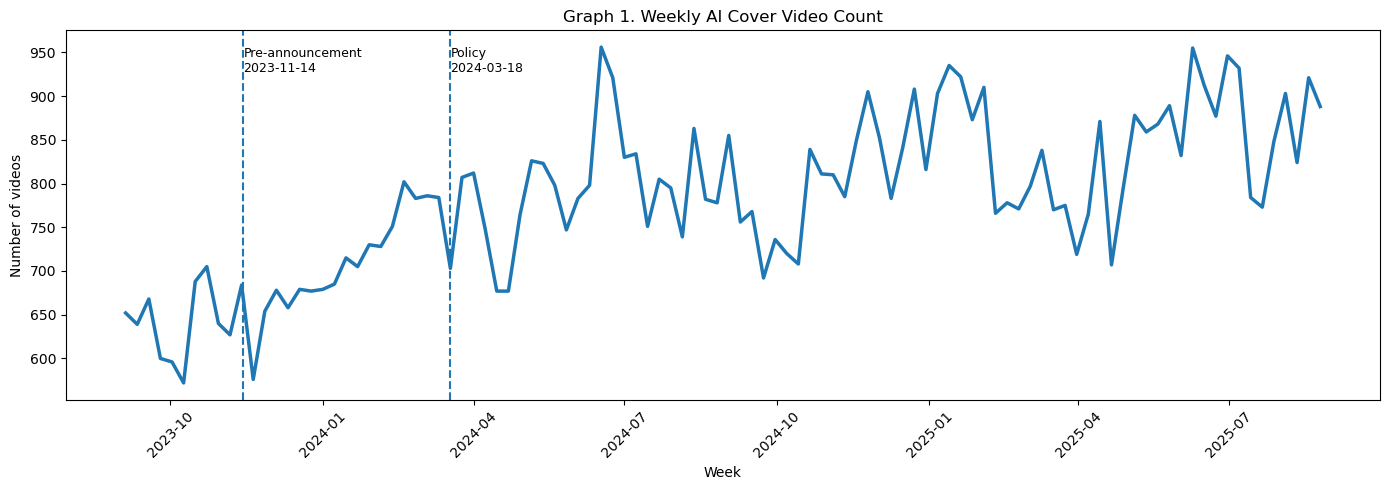

In [23]:
# Plot Graph 1

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph1["week"].dt.tz_localize(None),
    graph1["ai_cover_videos"],
    linewidth=2.5
)

add_policy_lines_local(ax)

# Optional y-axis zoom:
# Uncomment the next two lines if you want a tighter range
# ax.set_ylim(400, 1000)
# ax.set_yticks(range(400, 1001, 100))

format_weekly_axis_local(
    ax,
    title="Graph 1. Weekly AI Cover Video Count",
    ylabel="Number of videos"
)

plt.show()

<a id="graph-2-weekly-active-ai-cover-channel-count"></a>
#### Graph 2. Weekly Active AI Cover Channel Count

In [24]:
# ---------------------------------------------------------
# Graph 2. Weekly Active AI Cover Channel Count
# ---------------------------------------------------------
# Outcome definition:
# Number of unique channels that uploaded at least one AI-cover video in a given week.
#
# This differs from Graph 1:
# - Graph 1 counts videos
# - Graph 2 counts unique active channels
#
# Together, the two figures help distinguish:
# - more supply from more videos per channel
# versus
# - more supply from more participating channels

graph2_raw = (
    ai_window
    .dropna(subset=["week", "channel_id"])
    .groupby("week", as_index=False)
    .agg(active_ai_cover_channels=("channel_id", "nunique"))
    .sort_values("week")
)

graph2 = complete_weekly_to_last_observed(
    df=graph2_raw,
    week_col="week",
    value_col="active_ai_cover_channels",
    analysis_start=ANALYSIS_START_RAW
)

print("graph2_raw shape:", graph2_raw.shape)
print("graph2 shape    :", graph2.shape)
display(graph2.head())
display(graph2.tail())

graph2_raw shape: (105, 2)
graph2 shape    : (104, 2)


,week,active_ai_cover_channels
0,2023-09-04 00:00:00+00:00,222
1,2023-09-11 00:00:00+00:00,216
2,2023-09-18 00:00:00+00:00,205
3,2023-09-25 00:00:00+00:00,193
4,2023-10-02 00:00:00+00:00,202


,week,active_ai_cover_channels
99,2025-07-28 00:00:00+00:00,348
100,2025-08-04 00:00:00+00:00,329
101,2025-08-11 00:00:00+00:00,337
102,2025-08-18 00:00:00+00:00,334
103,2025-08-25 00:00:00+00:00,321


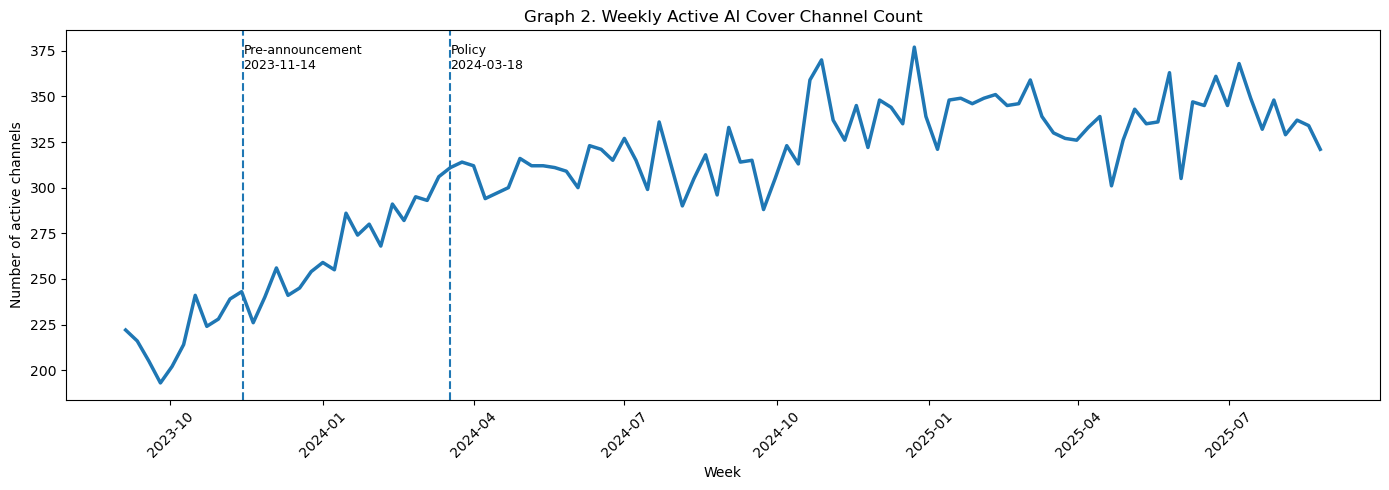

In [25]:
# Plot Graph 2

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph2["week"].dt.tz_localize(None),
    graph2["active_ai_cover_channels"],
    linewidth=2.5
)

add_policy_lines_local(ax)

format_weekly_axis_local(
    ax,
    title="Graph 2. Weekly Active AI Cover Channel Count",
    ylabel="Number of active channels"
)

plt.show()

In [26]:
# ---------------------------------------------------------
# Optional export for collaborators
# ---------------------------------------------------------
# Saving the weekly tables helps coauthors inspect the exact values
# behind the figures without rerunning the whole notebook.

graph1.to_csv(OUTPUT_DIR / "graph1_weekly_ai_cover_video_count.csv", index=False)
graph2.to_csv(OUTPUT_DIR / "graph2_weekly_active_ai_cover_channel_count.csv", index=False)

print("Saved:")
print("-", OUTPUT_DIR / "graph1_weekly_ai_cover_video_count.csv")
print("-", OUTPUT_DIR / "graph2_weekly_active_ai_cover_channel_count.csv")

Saved:
- data/visualization_outputs/graph1_weekly_ai_cover_video_count.csv
- data/visualization_outputs/graph2_weekly_active_ai_cover_channel_count.csv


<a id="32-new-channel-creation-and-early-entry"></a>
### 3.2 New Channel Creation and Early Entry

<a id="graph-3-weekly-new-channel-count"></a>
#### Graph 3. Weekly New Channel Count

In [27]:
# ---------------------------------------------------------
# Section 3.2 local helper functions
# ---------------------------------------------------------
# We define helpers locally here because they are only needed
# for the "new channel creation / early entry" section.

def first_full_monday_section32(start_ts):
    """
    Return the first Monday inside the analysis window.

    This avoids a misleading partial first week when the analysis
    window starts mid-week (for example, 2023-09-01 is a Friday).
    """
    ts = pd.Timestamp(start_ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    ts = ts.normalize()

    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def week_floor_section32(series):
    """
    Convert a datetime-like series to the Monday of its week.
    NaT values remain NaT.
    """
    s = pd.to_datetime(series, utc=True, errors="coerce")
    return pd.Series(
        [pd.NaT if pd.isna(x) else x.to_period("W-SUN").start_time for x in s],
        index=s.index
    ).pipe(pd.to_datetime, utc=True)


def complete_weekly_to_last_observed_section32(df, week_col, value_col, analysis_start):
    """
    Create a continuous weekly series from:
    - the first Monday inside the analysis window
    - to the last observed week with positive activity

    This prevents artificial zero-padding beyond the observed last week.
    """
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday_section32(analysis_start)

    observed = out[out[value_col] > 0].copy()
    if len(observed) == 0:
        return out.iloc[0:0].copy()

    last_week = observed[week_col].max()

    full_weeks = pd.date_range(start=start_week, end=last_week, freq="W-MON", tz="UTC")

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .fillna(0)
           .rename_axis(week_col)
           .reset_index()
    )
    return out


def add_policy_lines_section32(ax):
    """
    Add the two main policy dates used throughout the notebook.
    """
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_axis_section32(ax, title, xlabel, ylabel):
    """
    Consistent formatting for this section.
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [28]:
# ---------------------------------------------------------
# Build a channel-level table of first AI Cover upload timing
# ---------------------------------------------------------
# Why do we do this here?
# Graph 5 needs to know how quickly a newly created channel uploads
# its first AI Cover video.
#
# We compute this from ai_all (full AI-cover history), not ai_window,
# because "first AI upload" should be based on the full observed history.

if "ai_all" not in globals():
    raise RuntimeError("Please run Section 2 first. 'ai_all' is not available.")

first_ai_by_channel = (
    ai_all
    .groupby("channel_id", as_index=False)
    .agg(first_ai_upload_at=("published_at", "min"))
)

print("first_ai_by_channel shape:", first_ai_by_channel.shape)
display(first_ai_by_channel.head())

first_ai_by_channel shape: (3993, 2)


,channel_id,first_ai_upload_at
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 15:00:44+00:00
1,UC-26K0B-XV5ieqZsQ3QPrcA,2023-08-07 09:09:11+00:00
2,UC-36LC4gre8sqz4PtWbaLcw,2025-10-30 08:50:31+00:00
3,UC-3JqzhyphVp9PD83tC0MJQ,2025-12-28 14:01:17+00:00
4,UC-4mQA-mv5rbe8W-mgbl7vQ,2024-11-18 21:03:12+00:00


Graph 3 counts how many sampled channels were created in each week within the analysis window.

In [29]:
# ---------------------------------------------------------
# Graph 3. Weekly New Channel Count
# ---------------------------------------------------------
# Outcome definition:
# Number of channels in the AI-cover sample whose channel creation date
# falls in each week of the analysis window.
#
# Input table:
# channels_window from Section 2
#
# Interpretation:
# This is not the number of all new YouTube channels platform-wide.
# It is the number of newly created channels within our AI-cover-related sample.

if "channels_window" not in globals():
    raise RuntimeError("Please run Section 2 first. 'channels_window' is not available.")

graph3_input = channels_window.copy()

# Rebuild created_week locally for transparency
graph3_input["created_week"] = week_floor_section32(graph3_input["channel_created_at"])

graph3_raw = (
    graph3_input
    .dropna(subset=["created_week", "channel_id"])
    .groupby("created_week", as_index=False)
    .agg(new_channels=("channel_id", "nunique"))
    .rename(columns={"created_week": "week"})
    .sort_values("week")
)

graph3 = complete_weekly_to_last_observed_section32(
    df=graph3_raw,
    week_col="week",
    value_col="new_channels",
    analysis_start=ANALYSIS_START_RAW
)

print("graph3_raw shape:", graph3_raw.shape)
print("graph3 shape    :", graph3.shape)
display(graph3.head())
display(graph3.tail())

graph3_raw shape: (105, 2)
graph3 shape    : (104, 2)


/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/3036607433.py:30: UserWarning: Converting to Period representation will drop timezone information.
  [pd.NaT if pd.isna(x) else x.to_period("W-SUN").start_time for x in s],


,week,new_channels
0,2023-09-04 00:00:00+00:00,17
1,2023-09-11 00:00:00+00:00,18
2,2023-09-18 00:00:00+00:00,17
3,2023-09-25 00:00:00+00:00,12
4,2023-10-02 00:00:00+00:00,19


,week,new_channels
99,2025-07-28 00:00:00+00:00,6
100,2025-08-04 00:00:00+00:00,6
101,2025-08-11 00:00:00+00:00,6
102,2025-08-18 00:00:00+00:00,3
103,2025-08-25 00:00:00+00:00,2


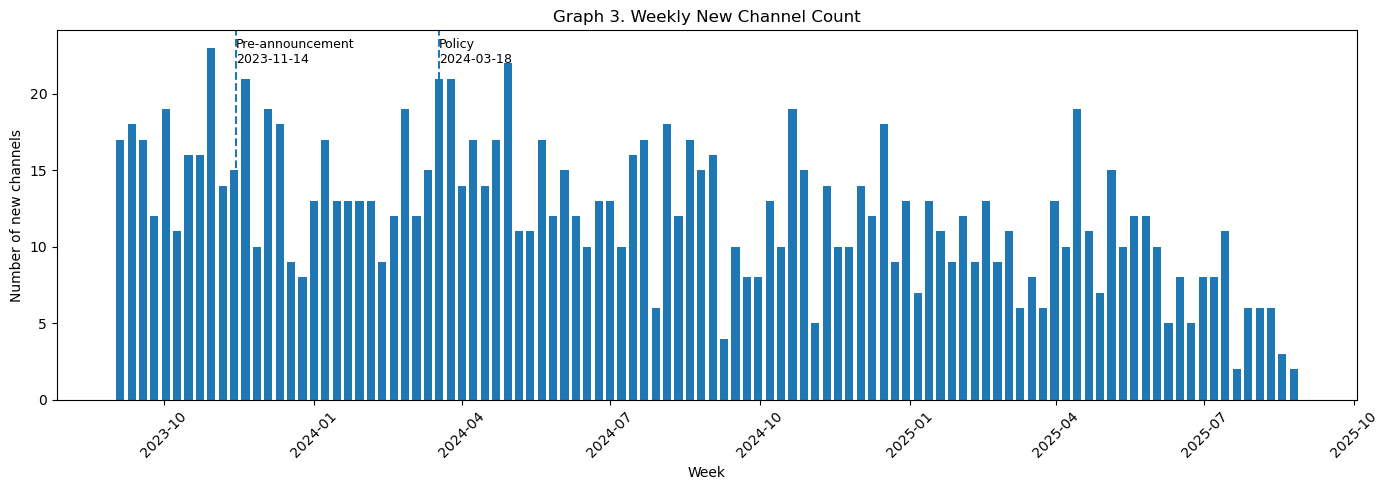

In [30]:
# Plot Graph 3

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    graph3["week"].dt.tz_localize(None),
    graph3["new_channels"],
    width=5
)

add_policy_lines_section32(ax)

format_axis_section32(
    ax,
    title="Graph 3. Weekly New Channel Count",
    xlabel="Week",
    ylabel="Number of new channels"
)

plt.show()

<a id="graph-4-channel-creation-date-heatmap"></a>
#### Graph 4. Channel Creation Date Heatmap

In [31]:
# ---------------------------------------------------------
# Graph 4. Channel Creation Date Heatmap
# ---------------------------------------------------------
# Purpose:
# Instead of aggregating only to the weekly level, we visualize
# the distribution of channel creation dates across:
# - month (rows)
# - day of month (columns)
#
# This can reveal whether channel creation is concentrated in a few
# specific dates or more broadly distributed across each month.

graph4_input = channels_window.copy()
graph4_input = graph4_input.dropna(subset=["channel_created_at"]).copy()

graph4_input["month"] = graph4_input["channel_created_at"].dt.strftime("%Y-%m")
graph4_input["day_of_month"] = graph4_input["channel_created_at"].dt.day

graph4_heatmap = (
    graph4_input
    .groupby(["month", "day_of_month"])
    .size()
    .unstack(fill_value=0)
)

print("graph4_heatmap shape:", graph4_heatmap.shape)
display(graph4_heatmap.head())

graph4_heatmap shape: (24, 31)


day_of_month,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
month,,,,,,,,,,,,,,,,,,,,,
2023-09,5,1,5,2,1,6,1,2,2,3,...,2,1,2,1,1,2,2,0,3,0
2023-10,3,4,5,2,1,1,3,3,1,3,...,2,4,0,2,4,1,3,2,2,4
2023-11,2,5,4,1,5,3,0,1,2,1,...,6,3,4,3,1,2,2,2,1,0
2023-12,1,2,0,4,3,1,0,3,4,4,...,0,2,2,1,1,1,2,1,2,0
2024-01,2,1,0,4,1,3,2,1,3,2,...,2,3,1,3,1,1,2,3,2,1


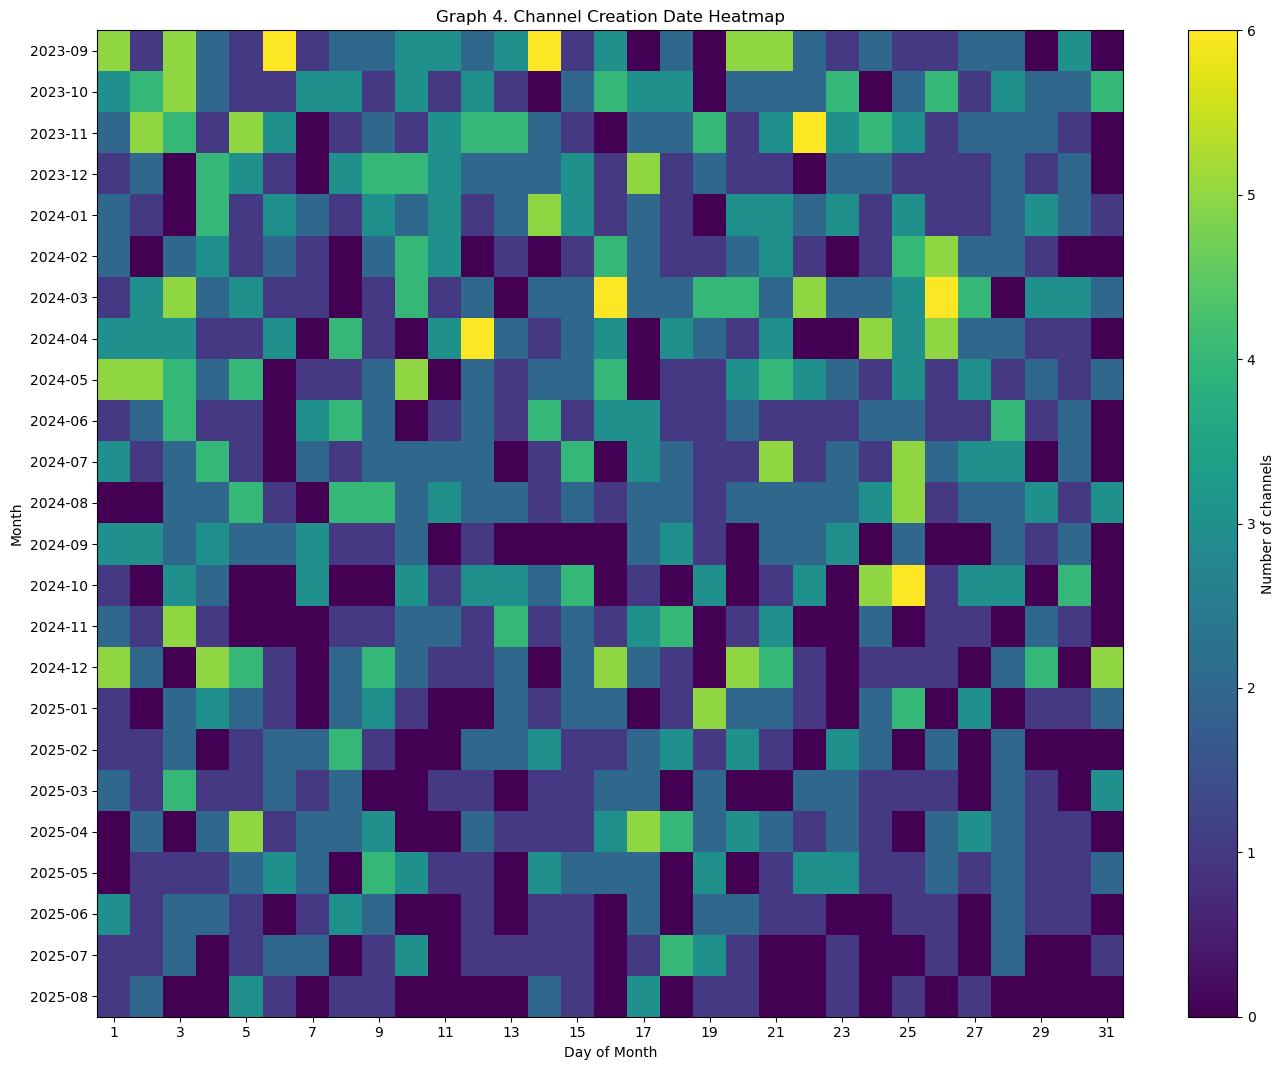

In [32]:
# Plot Graph 4

fig, ax = plt.subplots(figsize=(14, max(4, len(graph4_heatmap) * 0.45)))

im = ax.imshow(graph4_heatmap.values, aspect="auto")

ax.set_title("Graph 4. Channel Creation Date Heatmap")
ax.set_xlabel("Day of Month")
ax.set_ylabel("Month")

# Show every 2nd day label to reduce crowding
ax.set_xticks(range(0, graph4_heatmap.shape[1], 2))
ax.set_xticklabels(graph4_heatmap.columns[::2])

ax.set_yticks(range(len(graph4_heatmap.index)))
ax.set_yticklabels(graph4_heatmap.index)

fig.colorbar(im, ax=ax, label="Number of channels")
plt.tight_layout()
plt.show()

<a id="graph-5-new-channels-uploading-ai-cover-within-7-days"></a>
#### Graph 5. New Channels Uploading AI Cover Within 7 Days

In [33]:
# ---------------------------------------------------------
# Graph 5. New Channels Uploading AI Cover Within 7 Days
# ---------------------------------------------------------
# Outcome definition:
# Among newly created channels in our sample, how many uploaded their
# first AI Cover video within 7 days of channel creation?
#
# Why this matters:
# This helps distinguish channels that appear to be created and used
# quickly for AI Cover activity from channels that were created earlier
# but only later became active in AI Cover.

graph5_input = (
    channels_window[["channel_id", "channel_created_at"]]
    .drop_duplicates()
    .merge(
        first_ai_by_channel[["channel_id", "first_ai_upload_at"]],
        on="channel_id",
        how="left"
    )
)

# Compute elapsed time between channel creation and first AI Cover upload
graph5_input["days_to_first_ai_upload"] = (
    graph5_input["first_ai_upload_at"] - graph5_input["channel_created_at"]
).dt.total_seconds() / (60 * 60 * 24)

graph5_input["created_week"] = week_floor_section32(graph5_input["channel_created_at"])

# Fast-start entry: first AI Cover upload occurs within 7 days
graph5_input["uploaded_within_7d"] = (
    graph5_input["days_to_first_ai_upload"]
    .between(0, 7, inclusive="both")
    .fillna(False)
)

graph5_raw = (
    graph5_input
    .groupby("created_week", as_index=False)
    .agg(new_channels_within_7d=("uploaded_within_7d", "sum"))
    .rename(columns={"created_week": "week"})
    .sort_values("week")
)

graph5 = complete_weekly_to_last_observed_section32(
    df=graph5_raw,
    week_col="week",
    value_col="new_channels_within_7d",
    analysis_start=ANALYSIS_START_RAW
)

print("graph5_input shape:", graph5_input.shape)
print("graph5_raw shape  :", graph5_raw.shape)
print("graph5 shape      :", graph5.shape)
display(graph5.head())
display(graph5.tail())

graph5_input shape: (1285, 6)
graph5_raw shape  : (105, 2)
graph5 shape      : (104, 2)


/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/3036607433.py:30: UserWarning: Converting to Period representation will drop timezone information.
  [pd.NaT if pd.isna(x) else x.to_period("W-SUN").start_time for x in s],


,week,new_channels_within_7d
0,2023-09-04 00:00:00+00:00,8
1,2023-09-11 00:00:00+00:00,4
2,2023-09-18 00:00:00+00:00,9
3,2023-09-25 00:00:00+00:00,6
4,2023-10-02 00:00:00+00:00,7


,week,new_channels_within_7d
99,2025-07-28 00:00:00+00:00,4
100,2025-08-04 00:00:00+00:00,3
101,2025-08-11 00:00:00+00:00,3
102,2025-08-18 00:00:00+00:00,1
103,2025-08-25 00:00:00+00:00,2


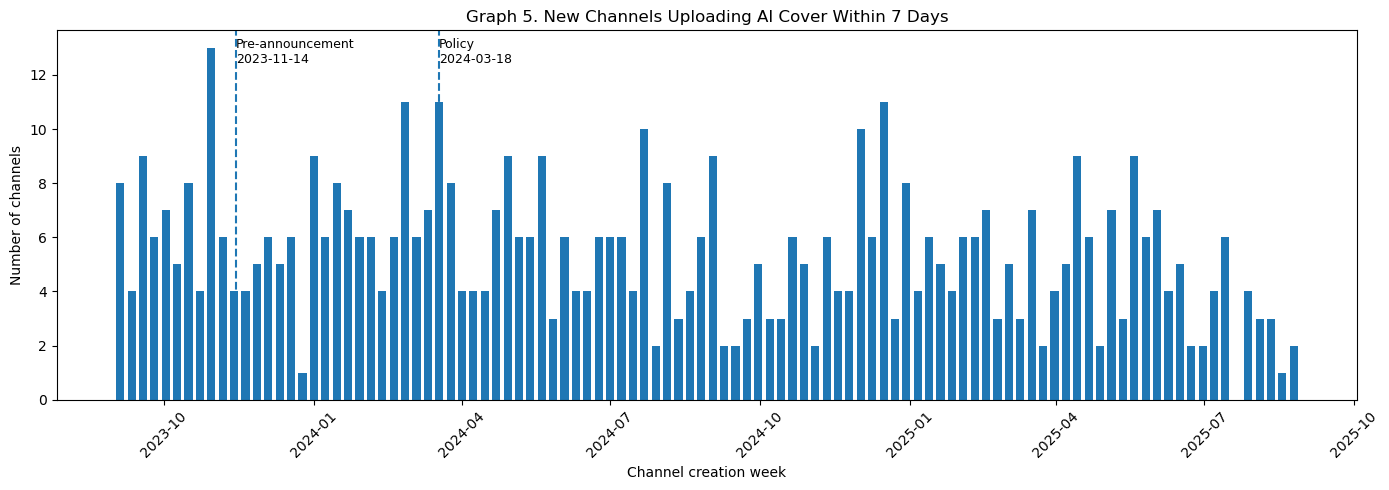

In [34]:
# Plot Graph 5

fig, ax = plt.subplots(figsize=(14, 5))

ax.bar(
    graph5["week"].dt.tz_localize(None),
    graph5["new_channels_within_7d"],
    width=5
)

add_policy_lines_section32(ax)

format_axis_section32(
    ax,
    title="Graph 5. New Channels Uploading AI Cover Within 7 Days",
    xlabel="Channel creation week",
    ylabel="Number of channels"
)

plt.show()

In [35]:
# ---------------------------------------------------------
# Optional export for collaborators
# ---------------------------------------------------------
# Saving the graph-level tables makes it easier for coauthors
# to inspect exact counts without rerunning the notebook.

graph3.to_csv(OUTPUT_DIR / "graph3_weekly_new_channel_count.csv", index=False)
graph5.to_csv(OUTPUT_DIR / "graph5_new_channels_uploading_within_7_days.csv", index=False)
graph4_heatmap.to_csv(OUTPUT_DIR / "graph4_channel_creation_heatmap_table.csv")

print("Saved:")
print("-", OUTPUT_DIR / "graph3_weekly_new_channel_count.csv")
print("-", OUTPUT_DIR / "graph4_channel_creation_heatmap_table.csv")
print("-", OUTPUT_DIR / "graph5_new_channels_uploading_within_7_days.csv")

Saved:
- data/visualization_outputs/graph3_weekly_new_channel_count.csv
- data/visualization_outputs/graph4_channel_creation_heatmap_table.csv
- data/visualization_outputs/graph5_new_channels_uploading_within_7_days.csv


<a id="33-new-entrants-vs-reactivated-channels"></a>
### 3.3 New Entrants vs Reactivated Channels

<a id="graph-6-weekly-new-entrant-channels-vs-reactivated-channels"></a>
#### Graph 6. Weekly New Entrant Channels vs Reactivated Channels

In [36]:
# ---------------------------------------------------------
# Section 3.3 local helper functions
# ---------------------------------------------------------
# We define section-specific helpers here so the logic stays close
# to the figures that use it.

def first_full_monday_section33(start_ts):
    """
    Return the first Monday inside the analysis window.
    This avoids a partial first week.
    """
    ts = pd.Timestamp(start_ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    ts = ts.normalize()

    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def week_floor_section33(series):
    """
    Convert datetimes to the Monday of their week.
    """
    s = pd.to_datetime(series, utc=True, errors="coerce")
    return pd.Series(
        [pd.NaT if pd.isna(x) else x.to_period("W-SUN").start_time for x in s],
        index=s.index
    ).pipe(pd.to_datetime, utc=True)


def complete_weekly_to_last_observed_section33(df, week_col, value_col, analysis_start):
    """
    Build a continuous weekly series from the first Monday in the analysis window
    to the last observed week with positive activity.
    """
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday_section33(analysis_start)

    observed = out[out[value_col] > 0].copy()
    if len(observed) == 0:
        return out.iloc[0:0].copy()

    last_week = observed[week_col].max()

    full_weeks = pd.date_range(start=start_week, end=last_week, freq="W-MON", tz="UTC")

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .fillna(0)
           .rename_axis(week_col)
           .reset_index()
    )
    return out


def add_policy_lines_section33(ax):
    """
    Add policy dates used throughout the notebook.
    """
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_axis_section33(ax, title, xlabel, ylabel):
    """
    Consistent plot formatting for this section.
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [37]:
# ---------------------------------------------------------
# Build a channel-week panel for entrant / reactivation analysis
# ---------------------------------------------------------
# Why create a dedicated panel here?
# Because Graph 6 and Graph 7 are channel-week concepts, not video-level concepts.
#
# We want one row per (channel_id, week), with:
# - uploads in that week
# - first upload date in that week
# - first AI Cover upload date ever
# - reactivation flag based on the gap before the week's first upload

if "ai_all" not in globals() or "ai_window" not in globals():
    raise RuntimeError("Please run Section 2 first. 'ai_all' or 'ai_window' is not available.")

# 1) First AI Cover upload timing at the channel level
section33_first_ai = (
    ai_all
    .groupby("channel_id", as_index=False)
    .agg(first_ai_upload_at=("published_at", "min"))
)

section33_first_ai["first_ai_week"] = week_floor_section33(section33_first_ai["first_ai_upload_at"])

# 2) Compute upload gaps using the full AI Cover history
# Why full history?
# Reactivation should be based on the actual previous upload, not just uploads inside the window.
section33_ai_all = ai_all.copy()
section33_ai_all = section33_ai_all.sort_values(["channel_id", "published_at", "video_id"]).copy()

section33_ai_all["prev_ai_upload_at"] = section33_ai_all.groupby("channel_id")["published_at"].shift(1)
section33_ai_all["gap_days"] = (
    (section33_ai_all["published_at"] - section33_ai_all["prev_ai_upload_at"])
    .dt.total_seconds() / (60 * 60 * 24)
)

# 3) Bring gap information into the windowed sample
section33_ai_window = ai_window.merge(
    section33_ai_all[["video_id", "gap_days"]],
    on="video_id",
    how="left"
)

# 4) Build a channel-week panel
section33_cw = (
    section33_ai_window
    .groupby(["channel_id", "week"], as_index=False)
    .agg(
        uploads=("video_id", "count"),
        first_upload_in_week=("published_at", "min")
    )
)

# 5) Attach first AI upload timing
section33_cw = section33_cw.merge(
    section33_first_ai[["channel_id", "first_ai_upload_at", "first_ai_week"]],
    on="channel_id",
    how="left"
)

# 6) Mark new entrants
section33_cw["is_new_entrant"] = (section33_cw["week"] == section33_cw["first_ai_week"]).astype(int)

# 7) Get the gap of the week's first upload
section33_first_uploads_in_week = (
    section33_ai_window
    .sort_values(["channel_id", "week", "published_at", "video_id"])
    .groupby(["channel_id", "week"], as_index=False)
    .first()[["channel_id", "week", "gap_days"]]
    .rename(columns={"gap_days": "gap_days_first_upload"})
)

section33_cw = section33_cw.merge(
    section33_first_uploads_in_week,
    on=["channel_id", "week"],
    how="left"
)

# Default reactivation threshold for this section
REACTIVATION_THRESHOLD_SECTION33 = 56

section33_cw["is_reactivated"] = (
    (section33_cw["gap_days_first_upload"] >= REACTIVATION_THRESHOLD_SECTION33)
    .fillna(False)
    .astype(int)
)

print("section33_first_ai shape:", section33_first_ai.shape)
print("section33_ai_window shape:", section33_ai_window.shape)
print("section33_cw shape:", section33_cw.shape)
display(section33_cw.head())

/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/829904615.py:27: UserWarning: Converting to Period representation will drop timezone information.
  [pd.NaT if pd.isna(x) else x.to_period("W-SUN").start_time for x in s],


section33_first_ai shape: (3993, 3)
section33_ai_window shape: (81670, 19)
section33_cw shape: (32095, 9)


,channel_id,week,uploads,first_upload_in_week,first_ai_upload_at,first_ai_week,is_new_entrant,gap_days_first_upload,is_reactivated
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 00:00:00+00:00,2,2025-05-19 15:00:44+00:00,2025-05-19 15:00:44+00:00,2025-05-19 00:00:00+00:00,1,3.000475,0
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-26 00:00:00+00:00,1,2025-05-27 16:15:08+00:00,2025-05-19 15:00:44+00:00,2025-05-19 00:00:00+00:00,0,5.051192,0
2,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-04 00:00:00+00:00,1,2023-09-09 05:00:09+00:00,2023-08-07 09:09:11+00:00,2023-08-07 00:00:00+00:00,0,18.791181,0
3,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-18 00:00:00+00:00,1,2023-09-24 17:00:29+00:00,2023-08-07 09:09:11+00:00,2023-08-07 00:00:00+00:00,0,15.500231,0
4,UC-26K0B-XV5ieqZsQ3QPrcA,2024-02-05 00:00:00+00:00,1,2024-02-10 09:58:15+00:00,2023-08-07 09:09:11+00:00,2023-08-07 00:00:00+00:00,0,138.706782,1


In [38]:
# ---------------------------------------------------------
# Graph 6. Weekly New Entrant Channels vs Reactivated Channels
# ---------------------------------------------------------
# Outcome definition:
# - New entrant channels: channels whose first AI Cover upload occurs in that week
# - Reactivated channels: channels whose first upload in that week follows
#   a 56-day or longer gap since the previous AI Cover upload
#
# Interpretation:
# This figure compares two distinct sources of weekly channel entry into supply:
# - first-time entry into AI Cover
# - return of previously inactive channels

graph6_raw = (
    section33_cw.groupby("week", as_index=False)
    .agg(
        new_entrant_channels=("is_new_entrant", "sum"),
        reactivated_channels=("is_reactivated", "sum")
    )
    .sort_values("week")
)

# 완전한 weekly index로 맞추되, 첫 full Monday부터 실제 관측 마지막 주까지만 사용
graph6 = complete_weekly_to_last_observed_section33(
    df=graph6_raw,
    week_col="week",
    value_col="new_entrant_channels",   # last observed week anchor
    analysis_start=ANALYSIS_START_RAW
)

# 혹시 fillna 이후 dtype이 float가 되었으면 보기 좋게 숫자형 정리
graph6["new_entrant_channels"] = graph6["new_entrant_channels"].fillna(0)
graph6["reactivated_channels"] = graph6["reactivated_channels"].fillna(0)

print("graph6_raw shape:", graph6_raw.shape)
print("graph6 shape    :", graph6.shape)
display(graph6.head())
display(graph6.tail())

graph6_raw shape: (105, 3)
graph6 shape    : (104, 3)


,week,new_entrant_channels,reactivated_channels
0,2023-09-04 00:00:00+00:00,47,5
1,2023-09-11 00:00:00+00:00,33,6
2,2023-09-18 00:00:00+00:00,38,11
3,2023-09-25 00:00:00+00:00,26,4
4,2023-10-02 00:00:00+00:00,39,14


,week,new_entrant_channels,reactivated_channels
99,2025-07-28 00:00:00+00:00,20,31
100,2025-08-04 00:00:00+00:00,11,29
101,2025-08-11 00:00:00+00:00,17,44
102,2025-08-18 00:00:00+00:00,16,28
103,2025-08-25 00:00:00+00:00,16,26


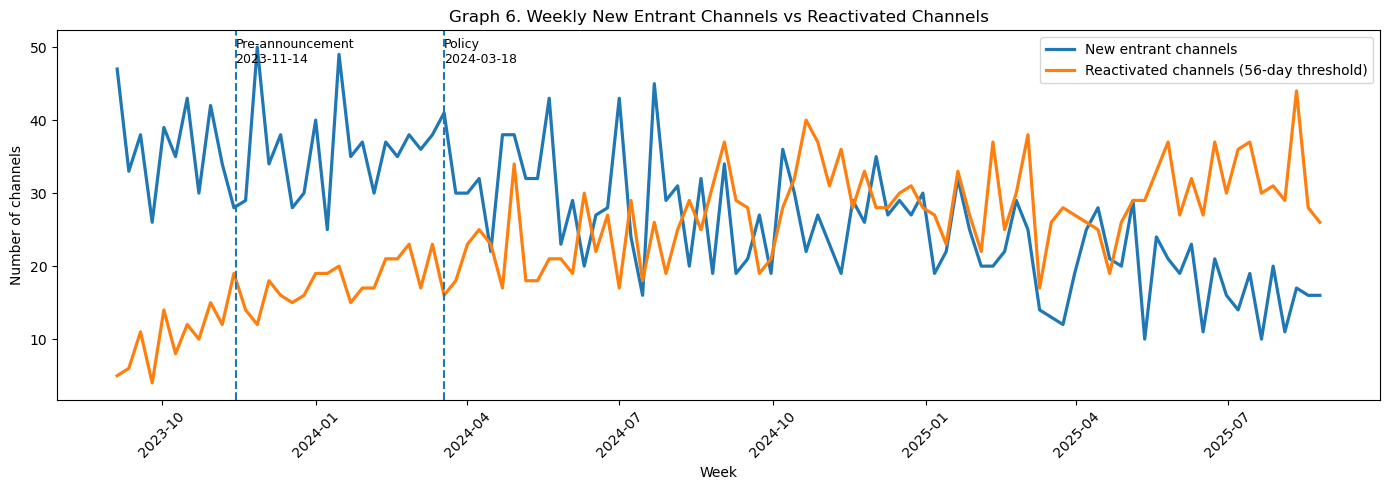

In [39]:
# Plot Graph 6

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph6["week"].dt.tz_localize(None),
    graph6["new_entrant_channels"],
    linewidth=2.3,
    label="New entrant channels"
)

ax.plot(
    graph6["week"].dt.tz_localize(None),
    graph6["reactivated_channels"],
    linewidth=2.3,
    label=f"Reactivated channels ({REACTIVATION_THRESHOLD_SECTION33}-day threshold)"
)

add_policy_lines_section33(ax)
ax.legend()

format_axis_section33(
    ax,
    title="Graph 6. Weekly New Entrant Channels vs Reactivated Channels",
    xlabel="Week",
    ylabel="Number of channels"
)

plt.show()

<a id="graph-7-weekly-supply-share-decomposition-supplementary"></a>
#### Graph 7. Weekly Supply Share Decomposition (Supplementary)

In [40]:

# ---------------------------------------------------------
# Graph 7. Weekly Supply Share Decomposition (Supplementary)
# ---------------------------------------------------------
# Goal:
# Decompose weekly upload supply into:
# - uploads from new entrant channels
# - uploads from existing active channels
#
# Important:
# "Existing active channels" here means channels that uploaded in that week
# but were NOT first-time entrants in that same week.
#
# This graph is supplementary because it is a simple two-way decomposition.
# Later sections may use more refined decompositions.

graph7_input = section33_cw.copy()
graph7_input["is_existing_active_channel"] = (graph7_input["is_new_entrant"] == 0).astype(int)

graph7_raw = (
    graph7_input
    .groupby("week", as_index=False)
    .agg(total_uploads=("uploads", "sum"))
    .merge(
        graph7_input[graph7_input["is_new_entrant"] == 1]
        .groupby("week", as_index=False)
        .agg(new_entrant_uploads=("uploads", "sum")),
        on="week", how="left"
    )
    .merge(
        graph7_input[graph7_input["is_existing_active_channel"] == 1]
        .groupby("week", as_index=False)
        .agg(existing_active_uploads=("uploads", "sum")),
        on="week", how="left"
    )
)

graph7_raw["new_entrant_uploads"] = graph7_raw["new_entrant_uploads"].fillna(0)
graph7_raw["existing_active_uploads"] = graph7_raw["existing_active_uploads"].fillna(0)

graph7_raw["new_entrant_share"] = (
    graph7_raw["new_entrant_uploads"] / graph7_raw["total_uploads"].replace(0, np.nan)
)

graph7_raw["existing_active_share"] = (
    graph7_raw["existing_active_uploads"] / graph7_raw["total_uploads"].replace(0, np.nan)
)

graph7_base = complete_weekly_to_last_observed_section33(
    df=graph7_raw.rename(columns={"total_uploads": "anchor_value"}),
    week_col="week",
    value_col="anchor_value",
    analysis_start=ANALYSIS_START_RAW
).rename(columns={"anchor_value": "total_uploads"})

graph7 = graph7_base[["week"]].merge(
    graph7_raw[["week", "new_entrant_share", "existing_active_share"]],
    on="week",
    how="left"
)

graph7["new_entrant_share"] = graph7["new_entrant_share"].fillna(0)
graph7["existing_active_share"] = graph7["existing_active_share"].fillna(0)

print("graph7_raw shape:", graph7_raw.shape)
print("graph7 shape    :", graph7.shape)
display(graph7.head())
display(graph7.tail())

graph7_raw shape: (105, 6)
graph7 shape    : (104, 3)


,week,new_entrant_share,existing_active_share
0,2023-09-04 00:00:00+00:00,0.162577,0.837423
1,2023-09-11 00:00:00+00:00,0.097027,0.902973
2,2023-09-18 00:00:00+00:00,0.131737,0.868263
3,2023-09-25 00:00:00+00:00,0.108333,0.891667
4,2023-10-02 00:00:00+00:00,0.134228,0.865772


,week,new_entrant_share,existing_active_share
99,2025-07-28 00:00:00+00:00,0.067217,0.932783
100,2025-08-04 00:00:00+00:00,0.032115,0.967885
101,2025-08-11 00:00:00+00:00,0.032767,0.967233
102,2025-08-18 00:00:00+00:00,0.058632,0.941368
103,2025-08-25 00:00:00+00:00,0.066441,0.933559


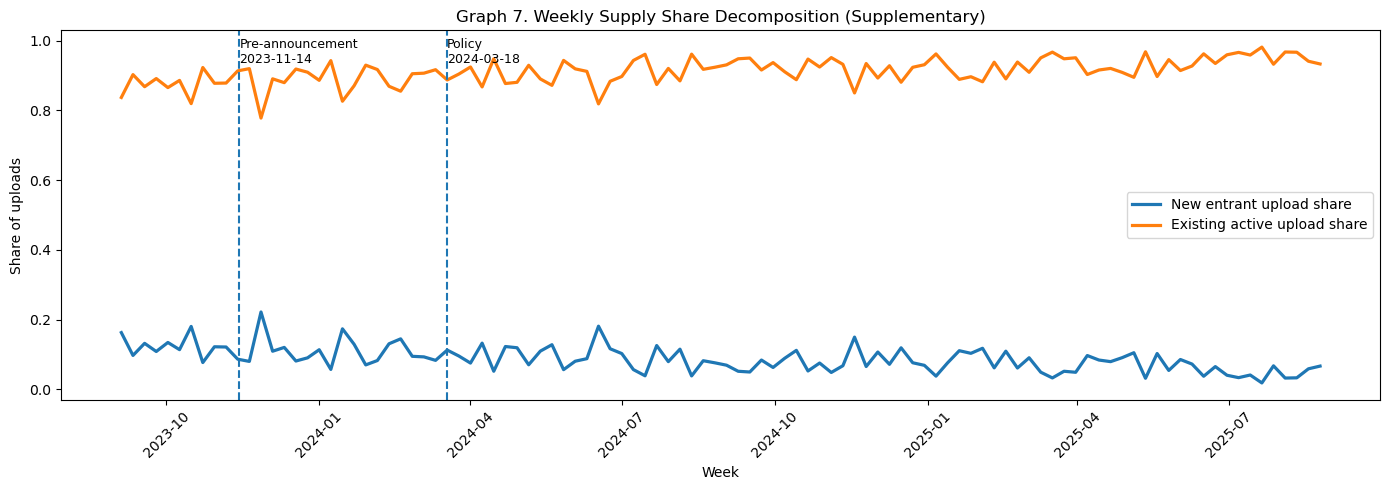

In [41]:
# Line version of Graph 7

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph7["week"].dt.tz_localize(None),
    graph7["new_entrant_share"],
    linewidth=2.3,
    label="New entrant upload share"
)

ax.plot(
    graph7["week"].dt.tz_localize(None),
    graph7["existing_active_share"],
    linewidth=2.3,
    label="Existing active upload share"
)

add_policy_lines_section33(ax)
ax.legend()

format_axis_section33(
    ax,
    title="Graph 7. Weekly Supply Share Decomposition (Supplementary)",
    xlabel="Week",
    ylabel="Share of uploads"
)

plt.show()

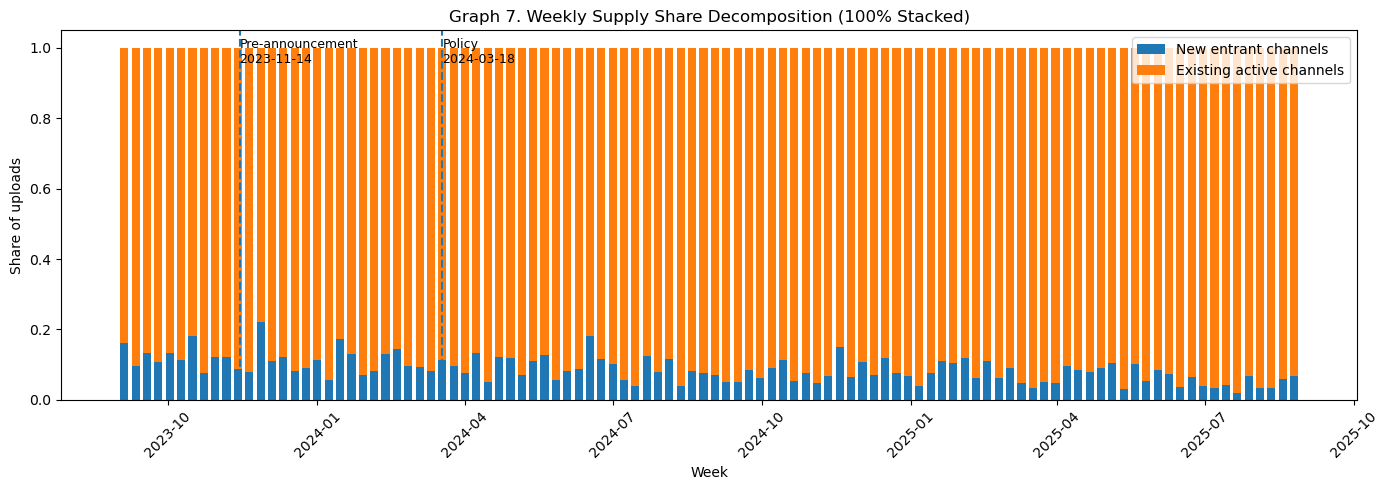

In [42]:
# Optional stacked-bar version of Graph 7
# This version is often more intuitive when the goal is to interpret
# weekly supply composition as parts of a whole.

fig, ax = plt.subplots(figsize=(14, 5))

x = graph7["week"].dt.tz_localize(None)

ax.bar(
    x,
    graph7["new_entrant_share"],
    width=5,
    label="New entrant channels"
)

ax.bar(
    x,
    graph7["existing_active_share"],
    width=5,
    bottom=graph7["new_entrant_share"],
    label="Existing active channels"
)

add_policy_lines_section33(ax)
ax.legend()

format_axis_section33(
    ax,
    title="Graph 7. Weekly Supply Share Decomposition (100% Stacked)",
    xlabel="Week",
    ylabel="Share of uploads"
)

plt.show()

In [43]:
# ---------------------------------------------------------
# Optional export for collaborators
# ---------------------------------------------------------
# Save graph-level tables so coauthors can inspect the exact values
# behind the figures.

graph6.to_csv(OUTPUT_DIR / "graph6_weekly_new_entrant_vs_reactivated_channels.csv", index=False)
graph7.to_csv(OUTPUT_DIR / "graph7_weekly_supply_share_decomposition.csv", index=False)

print("Saved:")
print("-", OUTPUT_DIR / "graph6_weekly_new_entrant_vs_reactivated_channels.csv")
print("-", OUTPUT_DIR / "graph7_weekly_supply_share_decomposition.csv")

Saved:
- data/visualization_outputs/graph6_weekly_new_entrant_vs_reactivated_channels.csv
- data/visualization_outputs/graph7_weekly_supply_share_decomposition.csv


<a id="34-reactivation-dynamics"></a>
### 3.4 Reactivation Dynamics

<a id="graph-8-reactivated-upload-share-28-day-56-day-84-day-thresholds"></a>
#### Graph 8. Reactivated Upload Share (28-day, 56-day, 84-day Thresholds)

In [44]:
# ---------------------------------------------------------
# Section 3.4 local helper functions
# ---------------------------------------------------------

def first_full_monday_section34(start_ts):
    """
    Return the first Monday inside the analysis window.
    """
    ts = pd.Timestamp(start_ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    ts = ts.normalize()
    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def complete_weekly_to_last_observed_section34(df, week_col, value_col, analysis_start):
    """
    Create a continuous weekly series from the first Monday in the analysis window
    to the last observed week with positive activity.
    """
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday_section34(analysis_start)

    observed = out[out[value_col] > 0].copy()
    if len(observed) == 0:
        return out.iloc[0:0].copy()

    last_week = observed[week_col].max()

    full_weeks = pd.date_range(start=start_week, end=last_week, freq="W-MON", tz="UTC")

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .fillna(0)
           .rename_axis(week_col)
           .reset_index()
    )
    return out


def add_policy_lines_section34(ax):
    """
    Add policy dates used throughout the notebook.
    """
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_axis_section34(ax, title, xlabel, ylabel):
    """
    Consistent plot formatting for this section.
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [45]:
# ---------------------------------------------------------
# Build reactivation metrics from full AI Cover history
# ---------------------------------------------------------
# Why rebuild here instead of reusing Section 3.3 objects?
# Because this section focuses specifically on reactivation,
# and we want the logic to remain close to the figures that use it.
#
# Important methodological choice:
# - gap_days must be computed using the full AI Cover history (ai_all),
#   not only the analysis window.
# - Otherwise early-window reactivation would be underestimated.

if "ai_all" not in globals() or "ai_window" not in globals():
    raise RuntimeError("Please run Section 2 first. 'ai_all' or 'ai_window' is not available.")

section34_ai_all = ai_all.copy()
section34_ai_all = section34_ai_all.sort_values(["channel_id", "published_at", "video_id"]).copy()

section34_ai_all["prev_ai_upload_at"] = section34_ai_all.groupby("channel_id")["published_at"].shift(1)
section34_ai_all["gap_days"] = (
    (section34_ai_all["published_at"] - section34_ai_all["prev_ai_upload_at"])
    .dt.total_seconds() / (60 * 60 * 24)
)

# Bring gap information into the analysis window
section34_ai_window = ai_window.merge(
    section34_ai_all[["video_id", "gap_days"]],
    on="video_id",
    how="left"
)

# Upload-level reactivation flags
for threshold in [28, 56, 84]:
    section34_ai_window[f"reactivated_upload_{threshold}d"] = (
        (section34_ai_window["gap_days"] >= threshold)
        .fillna(False)
        .astype(int)
    )

# Channel-week panel:
# one row per channel-week with upload count
section34_cw = (
    section34_ai_window
    .groupby(["channel_id", "week"], as_index=False)
    .agg(
        uploads=("video_id", "count"),
        first_upload_in_week=("published_at", "min")
    )
)

# Gap of the first upload in each channel-week
section34_first_uploads_in_week = (
    section34_ai_window
    .sort_values(["channel_id", "week", "published_at", "video_id"])
    .groupby(["channel_id", "week"], as_index=False)
    .first()[["channel_id", "week", "gap_days"]]
    .rename(columns={"gap_days": "gap_days_first_upload"})
)

section34_cw = section34_cw.merge(
    section34_first_uploads_in_week,
    on=["channel_id", "week"],
    how="left"
)

# Channel-week reactivation flags
for threshold in [28, 56, 84]:
    section34_cw[f"is_reactivated_channel_{threshold}d"] = (
        (section34_cw["gap_days_first_upload"] >= threshold)
        .fillna(False)
        .astype(int)
    )

print("section34_ai_window shape:", section34_ai_window.shape)
print("section34_cw shape:", section34_cw.shape)
display(section34_ai_window.head())
display(section34_cw.head())

section34_ai_window shape: (81670, 22)
section34_cw shape: (32095, 8)


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,video_description,video_id,video_tags,video_title,...,weeks_from_policy1,weeks_from_policy2,week,channel_created_at,subscriber_count,channel_video_count,gap_days,reactivated_upload_28d,reactivated_upload_56d,reactivated_upload_84d
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2026-04-13T04:06:51.627834+00:00,156.0,1,24,2025-05-19 15:00:44+00:00,All Rights Administered by Cube Entertainment\...,R4q02VneyM4,NaN,[AI COVER] How would BLACKPINK Sing 'GOOD THIN...,...,61.00,-8.14,2025-05-19 00:00:00+00:00,2024-04-14 02:53:02.923826+00:00,29.0,3.0,NaN,0,0,0
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2026-04-12T17:02:19.625377+00:00,299.0,1,139,2025-05-22 15:01:25+00:00,© All Credit and content goes to respective ow...,mtc_Ool-wfA,NaN,[AI COVER] How would BLACKPINK Sing 'LOVE STOR...,...,61.43,-7.71,2025-05-19 00:00:00+00:00,2024-04-14 02:53:02.923826+00:00,29.0,3.0,3.000475,0,0,0
2,UC--Fkf3RGD_0MdJS2H_7tcQ,2026-04-13T04:32:20.417675+00:00,226.0,1,27,2025-05-27 16:15:08+00:00,❤️ Like & Share to support the channel! \n🔔 S...,luCKVTgR1mI,NaN,[AI COVER] How would BLACKPINK Sing 'SWIN' by ...,...,62.14,-7.00,2025-05-26 00:00:00+00:00,2024-04-14 02:53:02.923826+00:00,29.0,3.0,5.051192,0,0,0
3,UC-26K0B-XV5ieqZsQ3QPrcA,2026-04-12T17:02:22.203324+00:00,275.0,1,2048,2023-09-09 05:00:09+00:00,I'm bored so I made matpat sings welcome to in...,okYm8ppuLm8,ai cover | welcome to the internet | alnimated...,"Matpat sings ""welcome to internet"" ai cover",...,-27.29,-96.43,2023-09-04 00:00:00+00:00,2020-12-11 21:58:46.058826+00:00,268.0,78.0,18.791181,0,0,0
4,UC-26K0B-XV5ieqZsQ3QPrcA,2026-04-13T04:20:43.262194+00:00,158.0,1,16,2023-09-24 17:00:29+00:00,Yes as a promised this is a part 2 of https://...,c02GGZ4v6Qo,ai cover | JVKE | friday night funkin | ninjam...,This is what heartbreak feels like bf ai cover,...,-25.14,-94.29,2023-09-18 00:00:00+00:00,2020-12-11 21:58:46.058826+00:00,268.0,78.0,15.500231,0,0,0


,channel_id,week,uploads,first_upload_in_week,gap_days_first_upload,is_reactivated_channel_28d,is_reactivated_channel_56d,is_reactivated_channel_84d
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 00:00:00+00:00,2,2025-05-19 15:00:44+00:00,3.000475,0,0,0
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-26 00:00:00+00:00,1,2025-05-27 16:15:08+00:00,5.051192,0,0,0
2,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-04 00:00:00+00:00,1,2023-09-09 05:00:09+00:00,18.791181,0,0,0
3,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-18 00:00:00+00:00,1,2023-09-24 17:00:29+00:00,15.500231,0,0,0
4,UC-26K0B-XV5ieqZsQ3QPrcA,2024-02-05 00:00:00+00:00,1,2024-02-10 09:58:15+00:00,138.706782,1,1,1


In [46]:
# ---------------------------------------------------------
# Graph 8. Reactivated Upload Share (28d / 56d / 84d)
# ---------------------------------------------------------
# Outcome definition:
# For each week, what share of all AI Cover uploads came from uploads
# whose gap since the previous AI Cover upload was at least:
# - 28 days
# - 56 days
# - 84 days
#
# This is an upload-level measure, not a channel-count measure.

graph8_base = (
    section34_ai_window
    .groupby("week", as_index=False)
    .agg(total_uploads=("video_id", "count"))
    .sort_values("week")
)

graph8_28 = (
    section34_ai_window
    .groupby("week", as_index=False)
    .agg(reactivated_uploads_28d=("reactivated_upload_28d", "sum"))
)

graph8_56 = (
    section34_ai_window
    .groupby("week", as_index=False)
    .agg(reactivated_uploads_56d=("reactivated_upload_56d", "sum"))
)

graph8_84 = (
    section34_ai_window
    .groupby("week", as_index=False)
    .agg(reactivated_uploads_84d=("reactivated_upload_84d", "sum"))
)

graph8_raw = (
    graph8_base
    .merge(graph8_28, on="week", how="left")
    .merge(graph8_56, on="week", how="left")
    .merge(graph8_84, on="week", how="left")
)

for col in ["reactivated_uploads_28d", "reactivated_uploads_56d", "reactivated_uploads_84d"]:
    graph8_raw[col] = graph8_raw[col].fillna(0)

graph8_raw["reactivated_upload_share_28d"] = (
    graph8_raw["reactivated_uploads_28d"] / graph8_raw["total_uploads"].replace(0, np.nan)
)
graph8_raw["reactivated_upload_share_56d"] = (
    graph8_raw["reactivated_uploads_56d"] / graph8_raw["total_uploads"].replace(0, np.nan)
)
graph8_raw["reactivated_upload_share_84d"] = (
    graph8_raw["reactivated_uploads_84d"] / graph8_raw["total_uploads"].replace(0, np.nan)
)

graph8 = complete_weekly_to_last_observed_section34(
    df=graph8_raw,
    week_col="week",
    value_col="total_uploads",
    analysis_start=ANALYSIS_START_RAW
)

print("graph8_raw shape:", graph8_raw.shape)
print("graph8 shape    :", graph8.shape)
display(graph8.head())
display(graph8.tail())

graph8_raw shape: (105, 8)
graph8 shape    : (104, 8)


,week,total_uploads,reactivated_uploads_28d,reactivated_uploads_56d,reactivated_uploads_84d,reactivated_upload_share_28d,reactivated_upload_share_56d,reactivated_upload_share_84d
0,2023-09-04 00:00:00+00:00,652,12,5,3,0.018405,0.007669,0.004601
1,2023-09-11 00:00:00+00:00,639,24,6,2,0.037559,0.009390,0.003130
2,2023-09-18 00:00:00+00:00,668,22,11,5,0.032934,0.016467,0.007485
3,2023-09-25 00:00:00+00:00,600,18,4,3,0.030000,0.006667,0.005000
4,2023-10-02 00:00:00+00:00,596,25,14,8,0.041946,0.023490,0.013423


,week,total_uploads,reactivated_uploads_28d,reactivated_uploads_56d,reactivated_uploads_84d,reactivated_upload_share_28d,reactivated_upload_share_56d,reactivated_upload_share_84d
99,2025-07-28 00:00:00+00:00,848,55,31,18,0.064858,0.036557,0.021226
100,2025-08-04 00:00:00+00:00,903,55,29,19,0.060908,0.032115,0.021041
101,2025-08-11 00:00:00+00:00,824,61,44,34,0.074029,0.053398,0.041262
102,2025-08-18 00:00:00+00:00,921,54,28,19,0.058632,0.030402,0.020630
103,2025-08-25 00:00:00+00:00,888,47,26,22,0.052928,0.029279,0.024775


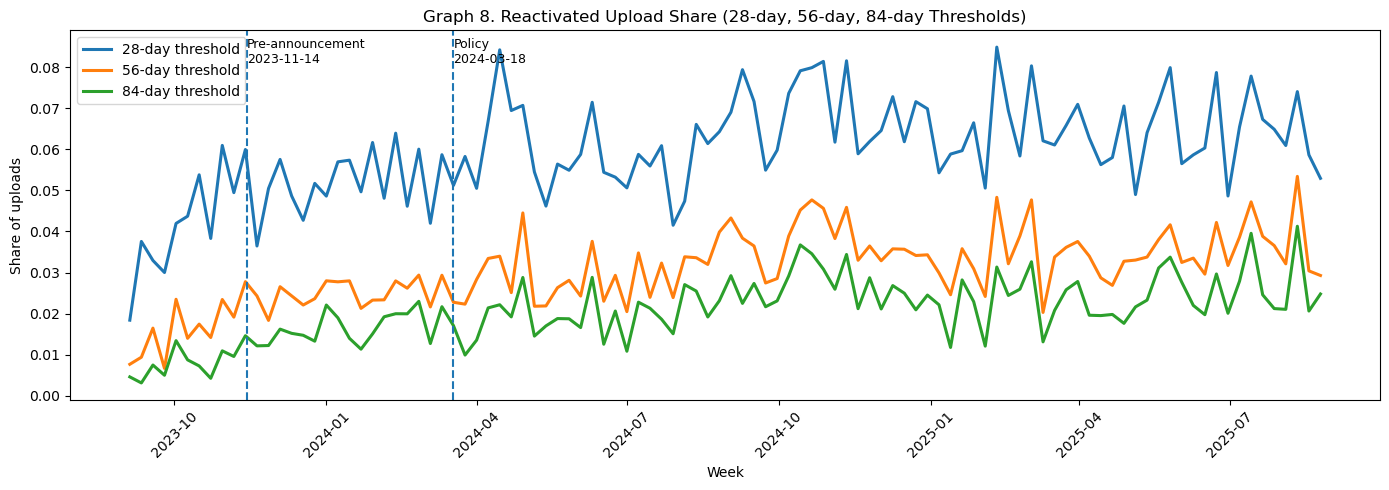

In [47]:
# Plot Graph 8

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph8["week"].dt.tz_localize(None),
    graph8["reactivated_upload_share_28d"],
    linewidth=2.2,
    label="28-day threshold"
)

ax.plot(
    graph8["week"].dt.tz_localize(None),
    graph8["reactivated_upload_share_56d"],
    linewidth=2.2,
    label="56-day threshold"
)

ax.plot(
    graph8["week"].dt.tz_localize(None),
    graph8["reactivated_upload_share_84d"],
    linewidth=2.2,
    label="84-day threshold"
)

add_policy_lines_section34(ax)
ax.legend()

format_axis_section34(
    ax,
    title="Graph 8. Reactivated Upload Share (28-day, 56-day, 84-day Thresholds)",
    xlabel="Week",
    ylabel="Share of uploads"
)

plt.show()

<a id="graph-9-reactivated-upload-share-56-day-threshold"></a>
#### Graph 9. Reactivated Upload Share (56-day Threshold)

In [48]:
# ---------------------------------------------------------
# Graph 9. Reactivated Upload Share (56-day Threshold)
# ---------------------------------------------------------
# This is simply the 56-day series from Graph 8 shown on its own,
# which makes the timing and trend easier to read.

graph9 = graph8[["week", "reactivated_upload_share_56d"]].copy()

print("graph9 shape:", graph9.shape)
display(graph9.head())
display(graph9.tail())

graph9 shape: (104, 2)


,week,reactivated_upload_share_56d
0,2023-09-04 00:00:00+00:00,0.007669
1,2023-09-11 00:00:00+00:00,0.009390
2,2023-09-18 00:00:00+00:00,0.016467
3,2023-09-25 00:00:00+00:00,0.006667
4,2023-10-02 00:00:00+00:00,0.023490


,week,reactivated_upload_share_56d
99,2025-07-28 00:00:00+00:00,0.036557
100,2025-08-04 00:00:00+00:00,0.032115
101,2025-08-11 00:00:00+00:00,0.053398
102,2025-08-18 00:00:00+00:00,0.030402
103,2025-08-25 00:00:00+00:00,0.029279


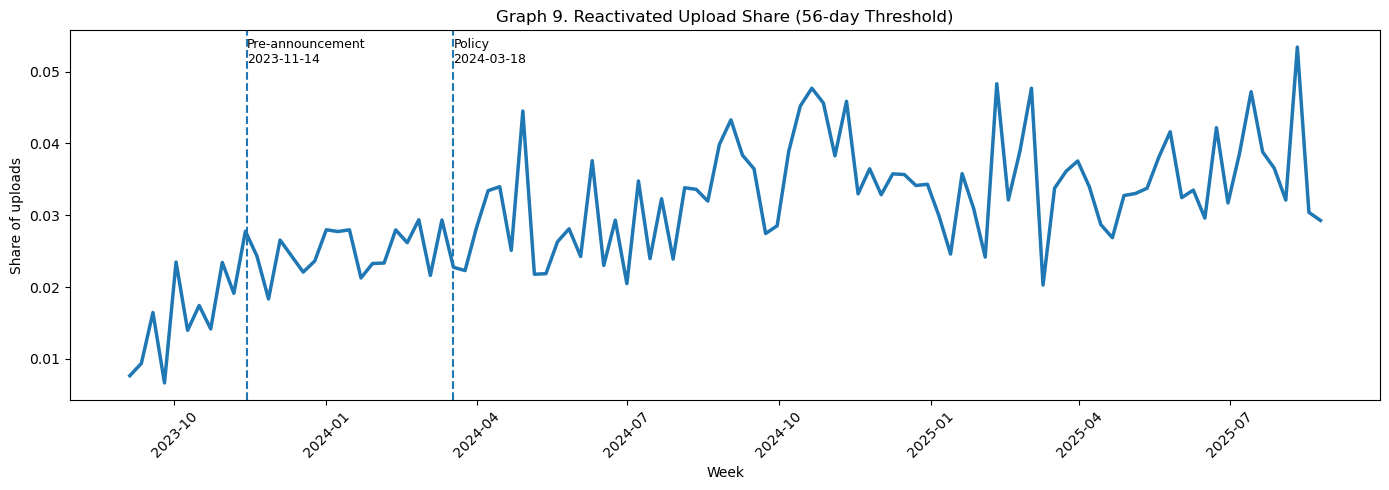

In [49]:
# Plot Graph 9

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph9["week"].dt.tz_localize(None),
    graph9["reactivated_upload_share_56d"],
    linewidth=2.5
)

add_policy_lines_section34(ax)

format_axis_section34(
    ax,
    title="Graph 9. Reactivated Upload Share (56-day Threshold)",
    xlabel="Week",
    ylabel="Share of uploads"
)

plt.show()

<a id="graph-10-weekly-count-of-reactivated-channels-28-day-56-day-84-day-thresholds"></a>
#### Graph 10. Weekly Count of Reactivated Channels (28-day, 56-day, 84-day Thresholds)

In [50]:
# ---------------------------------------------------------
# Graph 10. Weekly Count of Reactivated Channels (28d / 56d / 84d)
# ---------------------------------------------------------
# Outcome definition:
# Number of unique channel-weeks that are classified as reactivated
# under each threshold.
#
# This is a channel-count measure (not upload share).

graph10_raw = (
    section34_cw
    .groupby("week", as_index=False)
    .agg(
        reactivated_channels_28d=("is_reactivated_channel_28d", "sum"),
        reactivated_channels_56d=("is_reactivated_channel_56d", "sum"),
        reactivated_channels_84d=("is_reactivated_channel_84d", "sum")
    )
    .sort_values("week")
)

# Use 28d count as the anchor to identify the last observed active week
graph10 = complete_weekly_to_last_observed_section34(
    df=graph10_raw,
    week_col="week",
    value_col="reactivated_channels_28d",
    analysis_start=ANALYSIS_START_RAW
)

print("graph10_raw shape:", graph10_raw.shape)
print("graph10 shape    :", graph10.shape)
display(graph10.head())
display(graph10.tail())

graph10_raw shape: (105, 4)
graph10 shape    : (104, 4)


,week,reactivated_channels_28d,reactivated_channels_56d,reactivated_channels_84d
0,2023-09-04 00:00:00+00:00,12,5,3
1,2023-09-11 00:00:00+00:00,24,6,2
2,2023-09-18 00:00:00+00:00,22,11,5
3,2023-09-25 00:00:00+00:00,18,4,3
4,2023-10-02 00:00:00+00:00,25,14,8


,week,reactivated_channels_28d,reactivated_channels_56d,reactivated_channels_84d
99,2025-07-28 00:00:00+00:00,55,31,18
100,2025-08-04 00:00:00+00:00,55,29,19
101,2025-08-11 00:00:00+00:00,61,44,34
102,2025-08-18 00:00:00+00:00,54,28,19
103,2025-08-25 00:00:00+00:00,47,26,22


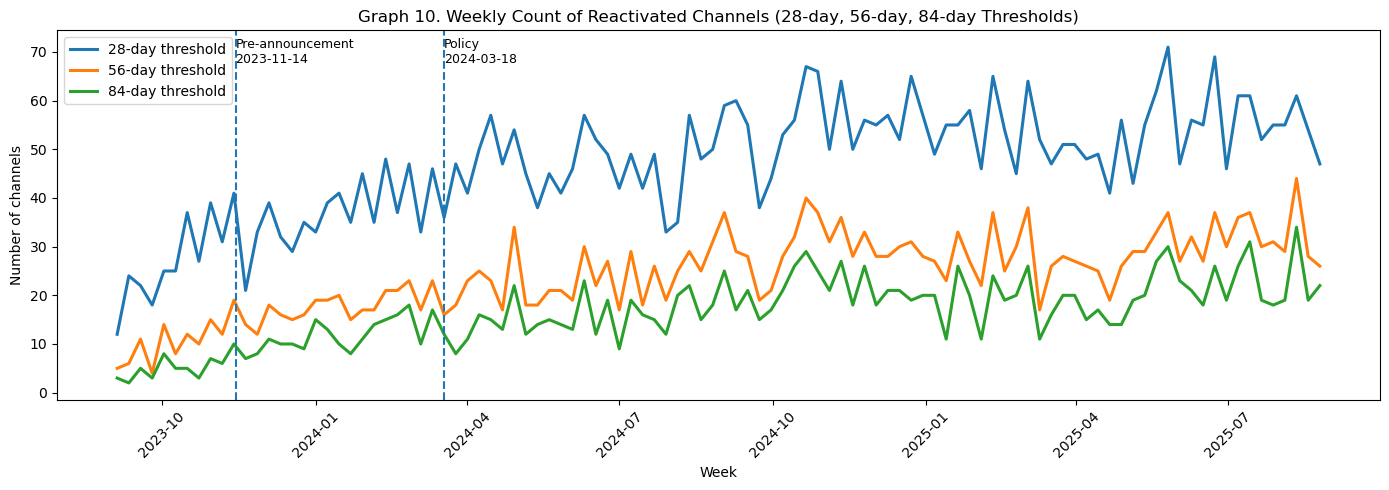

In [51]:
# Plot Graph 10

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph10["week"].dt.tz_localize(None),
    graph10["reactivated_channels_28d"],
    linewidth=2.2,
    label="28-day threshold"
)

ax.plot(
    graph10["week"].dt.tz_localize(None),
    graph10["reactivated_channels_56d"],
    linewidth=2.2,
    label="56-day threshold"
)

ax.plot(
    graph10["week"].dt.tz_localize(None),
    graph10["reactivated_channels_84d"],
    linewidth=2.2,
    label="84-day threshold"
)

add_policy_lines_section34(ax)
ax.legend()

format_axis_section34(
    ax,
    title="Graph 10. Weekly Count of Reactivated Channels (28-day, 56-day, 84-day Thresholds)",
    xlabel="Week",
    ylabel="Number of channels"
)

plt.show()

<a id="graph-11-share-of-active-channels-that-are-reactivated"></a>
#### Graph 11. Share of Active Channels that are Reactivated

In [52]:
# ---------------------------------------------------------
# Graph 11. Share of Active Channels that are Reactivated
# ---------------------------------------------------------
# Outcome definition:
# Among active AI Cover channels in a given week, what share are reactivated?
#
# Default threshold for the main version: 56 days
# (This matches the threshold used in the main entrant vs reactivation comparison.)

graph11_base = (
    section34_cw
    .groupby("week", as_index=False)
    .agg(active_channels=("channel_id", "nunique"))
    .sort_values("week")
)

graph11_reactivated = (
    section34_cw
    .groupby("week", as_index=False)
    .agg(reactivated_channels_56d=("is_reactivated_channel_56d", "sum"))
)

graph11_raw = graph11_base.merge(graph11_reactivated, on="week", how="left")
graph11_raw["reactivated_channels_56d"] = graph11_raw["reactivated_channels_56d"].fillna(0)

graph11_raw["reactivated_channel_share_56d"] = (
    graph11_raw["reactivated_channels_56d"] / graph11_raw["active_channels"].replace(0, np.nan)
)

graph11 = complete_weekly_to_last_observed_section34(
    df=graph11_raw,
    week_col="week",
    value_col="active_channels",
    analysis_start=ANALYSIS_START_RAW
)

print("graph11_raw shape:", graph11_raw.shape)
print("graph11 shape    :", graph11.shape)
display(graph11.head())
display(graph11.tail())

graph11_raw shape: (105, 4)
graph11 shape    : (104, 4)


,week,active_channels,reactivated_channels_56d,reactivated_channel_share_56d
0,2023-09-04 00:00:00+00:00,222,5,0.022523
1,2023-09-11 00:00:00+00:00,216,6,0.027778
2,2023-09-18 00:00:00+00:00,205,11,0.053659
3,2023-09-25 00:00:00+00:00,193,4,0.020725
4,2023-10-02 00:00:00+00:00,202,14,0.069307


,week,active_channels,reactivated_channels_56d,reactivated_channel_share_56d
99,2025-07-28 00:00:00+00:00,348,31,0.089080
100,2025-08-04 00:00:00+00:00,329,29,0.088146
101,2025-08-11 00:00:00+00:00,337,44,0.130564
102,2025-08-18 00:00:00+00:00,334,28,0.083832
103,2025-08-25 00:00:00+00:00,321,26,0.080997


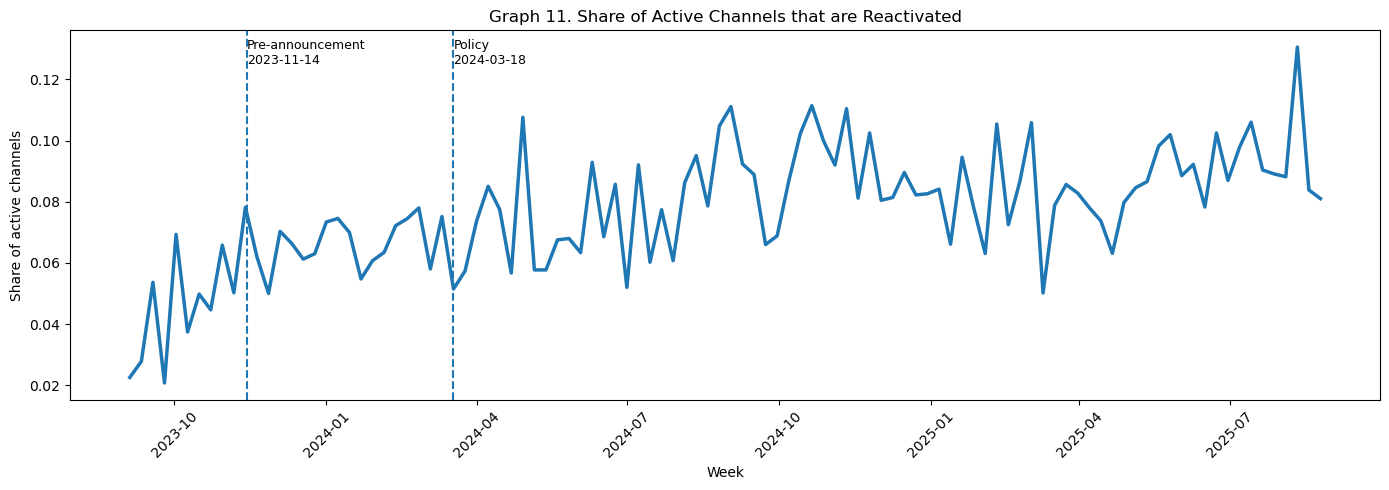

In [53]:
# Plot Graph 11

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph11["week"].dt.tz_localize(None),
    graph11["reactivated_channel_share_56d"],
    linewidth=2.5
)

add_policy_lines_section34(ax)

format_axis_section34(
    ax,
    title="Graph 11. Share of Active Channels that are Reactivated",
    xlabel="Week",
    ylabel="Share of active channels"
)

plt.show()

In [54]:
# ---------------------------------------------------------
# Optional export for collaborators
# ---------------------------------------------------------

graph8.to_csv(OUTPUT_DIR / "graph8_reactivated_upload_share_28_56_84.csv", index=False)
graph9.to_csv(OUTPUT_DIR / "graph9_reactivated_upload_share_56.csv", index=False)
graph10.to_csv(OUTPUT_DIR / "graph10_weekly_count_of_reactivated_channels.csv", index=False)
graph11.to_csv(OUTPUT_DIR / "graph11_share_of_active_channels_that_are_reactivated.csv", index=False)

print("Saved:")
print("-", OUTPUT_DIR / "graph8_reactivated_upload_share_28_56_84.csv")
print("-", OUTPUT_DIR / "graph9_reactivated_upload_share_56.csv")
print("-", OUTPUT_DIR / "graph10_weekly_count_of_reactivated_channels.csv")
print("-", OUTPUT_DIR / "graph11_share_of_active_channels_that_are_reactivated.csv")

Saved:
- data/visualization_outputs/graph8_reactivated_upload_share_28_56_84.csv
- data/visualization_outputs/graph9_reactivated_upload_share_56.csv
- data/visualization_outputs/graph10_weekly_count_of_reactivated_channels.csv
- data/visualization_outputs/graph11_share_of_active_channels_that_are_reactivated.csv


<a id="35-cohort-dynamics"></a>
### 3.5 Cohort Dynamics

<a id="graph-12-weekly-upload-count-of-the-pre-announcement-fixed-cohort"></a>
#### Graph 12. Weekly Upload Count of the Pre-announcement Fixed Cohort

In [55]:
# ---------------------------------------------------------
# Section 3.5 local helper functions
# ---------------------------------------------------------
# These helpers are defined locally because they are only used
# in the cohort-dynamics section.

def first_full_monday_section35(start_ts):
    """
    Return the first Monday inside the analysis window.
    This avoids starting the weekly series with a partial week.
    """
    ts = pd.Timestamp(start_ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    ts = ts.normalize()
    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def complete_weekly_to_last_observed_section35(df, week_col, value_col, analysis_start):
    """
    Create a continuous weekly series from the first Monday in the analysis window
    to the last observed week with positive activity.
    """
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday_section35(analysis_start)

    observed = out[out[value_col] > 0].copy()
    if len(observed) == 0:
        return out.iloc[0:0].copy()

    last_week = observed[week_col].max()

    full_weeks = pd.date_range(start=start_week, end=last_week, freq="W-MON", tz="UTC")

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .fillna(0)
           .rename_axis(week_col)
           .reset_index()
    )
    return out


def add_policy_lines_section35(ax):
    """
    Add the two main policy dates used throughout the notebook.
    """
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_axis_section35(ax, title, xlabel, ylabel):
    """
    Consistent formatting for this section.
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [56]:
# ---------------------------------------------------------
# Build the pre-announcement active cohort
# ---------------------------------------------------------
# New cohort definition:
# A channel belongs to the pre-announcement active cohort if it uploaded
# at least one AI Cover video during:
#   2023-09-01 to 2023-11-13
#
# Important:
# This is NOT a first-upload cohort.
# A channel can have started earlier than 2023-09-01 and still belong
# to this cohort, as long as it was active during the pre-announcement period.

if "ai_all" not in globals() or "ai_window" not in globals():
    raise RuntimeError("Please run Section 2 first. 'ai_all' or 'ai_window' is not available.")

PRE_ACTIVE_START = pd.Timestamp("2023-09-01", tz="UTC")
PRE_ACTIVE_END   = pd.Timestamp("2023-11-13 23:59:59", tz="UTC")

pre_announcement_active_cohort_ids = set(
    ai_all[
        (ai_all["published_at"] >= PRE_ACTIVE_START) &
        (ai_all["published_at"] <= PRE_ACTIVE_END)
    ]["channel_id"].dropna().astype(str).unique()
)

pre_announcement_active_cohort_size = len(pre_announcement_active_cohort_ids)

print("Pre-announcement active cohort size:", pre_announcement_active_cohort_size)

Pre-announcement active cohort size: 796


In [57]:
# ---------------------------------------------------------
# Restrict the analysis-window sample to the active cohort
# ---------------------------------------------------------
# We now keep only analysis-window uploads produced by channels
# that were active during the pre-announcement period.

section35_ai_window_cohort = ai_window[
    ai_window["channel_id"].astype(str).isin(pre_announcement_active_cohort_ids)
].copy()

print("section35_ai_window_cohort shape:", section35_ai_window_cohort.shape)
display(section35_ai_window_cohort.head())

section35_ai_window_cohort shape: (25145, 18)


,channel_id,collected_at_utc,duration_sec,is_ai_cover,like_count,published_at,video_description,video_id,video_tags,video_title,view_count,week_start_date,weeks_from_policy1,weeks_from_policy2,week,channel_created_at,subscriber_count,channel_video_count
9187,UC-26K0B-XV5ieqZsQ3QPrcA,2026-04-12T17:02:22.203324+00:00,275.0,1,2048,2023-09-09 05:00:09+00:00,I'm bored so I made matpat sings welcome to in...,okYm8ppuLm8,ai cover | welcome to the internet | alnimated...,"Matpat sings ""welcome to internet"" ai cover",49208,2023-09-04,-27.29,-96.43,2023-09-04 00:00:00+00:00,2020-12-11 21:58:46.058826+00:00,268.0,78.0
362147,UC-26K0B-XV5ieqZsQ3QPrcA,2026-04-13T04:20:43.262194+00:00,158.0,1,16,2023-09-24 17:00:29+00:00,Yes as a promised this is a part 2 of https://...,c02GGZ4v6Qo,ai cover | JVKE | friday night funkin | ninjam...,This is what heartbreak feels like bf ai cover,717,2023-09-18,-25.14,-94.29,2023-09-18 00:00:00+00:00,2020-12-11 21:58:46.058826+00:00,268.0,78.0
24808,UC-26K0B-XV5ieqZsQ3QPrcA,2026-04-13T03:35:56.840824+00:00,108.0,1,4,2024-02-10 09:58:15+00:00,Ehh what you expect here\n\nspecial thanks for...,0YR8CrZL7zY,#boburhaminside | gametheory | aicover | matpa...,Theory: content but matpat sings it,128,2024-02-05,-5.29,-74.43,2024-02-05 00:00:00+00:00,2020-12-11 21:58:46.058826+00:00,268.0,78.0
408263,UC-26K0B-XV5ieqZsQ3QPrcA,2026-04-13T04:26:56.971366+00:00,303.0,1,174,2024-03-09 20:00:07+00:00,a tribute ai cover for matpat from @GameTheory...,hIMYBRn6R0Q,matpat | ai cover | game theorist | fnaf | dig...,"Bo burham ""GOODBYE"" but matpat sings it || ai ...",3710,2024-03-04,-1.29,-70.43,2024-03-04 00:00:00+00:00,2020-12-11 21:58:46.058826+00:00,268.0,78.0
203247,UC-26K0B-XV5ieqZsQ3QPrcA,2026-04-13T03:59:33.483113+00:00,29.0,1,1,2024-10-25 14:29:02+00:00,NaN,KrvWnxDcehE,NaN,Scrapped Ai cover #1 | LOOK WHOS INSIDE AGAIN?,29,2024-10-21,31.57,-37.57,2024-10-21 00:00:00+00:00,2020-12-11 21:58:46.058826+00:00,268.0,78.0


Graph 12 tracks how many AI Cover uploads per week were produced by channels that were active during the pre-announcement period.

In [58]:
# ---------------------------------------------------------
# Graph 12. Weekly Upload Count of the Pre-announcement Active Cohort
# ---------------------------------------------------------

graph12_raw = (
    section35_ai_window_cohort
    .dropna(subset=["week", "video_id"])
    .groupby("week", as_index=False)
    .agg(cohort_uploads=("video_id", "count"))
    .sort_values("week")
)

graph12 = complete_weekly_to_last_observed_section35(
    df=graph12_raw,
    week_col="week",
    value_col="cohort_uploads",
    analysis_start=ANALYSIS_START_RAW
)

print("graph12_raw shape:", graph12_raw.shape)
print("graph12 shape    :", graph12.shape)
display(graph12.head())
display(graph12.tail())

graph12_raw shape: (105, 2)
graph12 shape    : (104, 2)


,week,cohort_uploads
0,2023-09-04 00:00:00+00:00,652
1,2023-09-11 00:00:00+00:00,639
2,2023-09-18 00:00:00+00:00,668
3,2023-09-25 00:00:00+00:00,600
4,2023-10-02 00:00:00+00:00,596


,week,cohort_uploads
99,2025-07-28 00:00:00+00:00,108
100,2025-08-04 00:00:00+00:00,113
101,2025-08-11 00:00:00+00:00,98
102,2025-08-18 00:00:00+00:00,86
103,2025-08-25 00:00:00+00:00,93


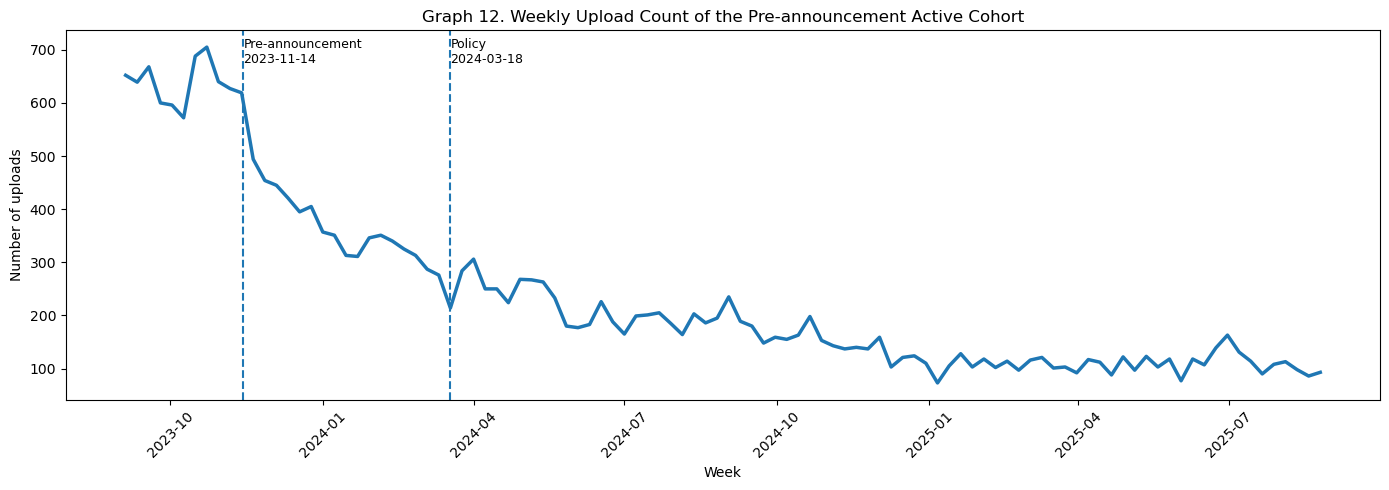

In [59]:
# Plot Graph 12

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph12["week"].dt.tz_localize(None),
    graph12["cohort_uploads"],
    linewidth=2.5
)

add_policy_lines_section35(ax)

format_axis_section35(
    ax,
    title="Graph 12. Weekly Upload Count of the Pre-announcement Active Cohort",
    xlabel="Week",
    ylabel="Number of uploads"
)

plt.show()

<a id="graph-13-weekly-active-channel-count-of-the-pre-announcement-fixed-cohort"></a>
#### Graph 13. Weekly Active Channel Count of the Pre-announcement Active Cohort

In [60]:
# ---------------------------------------------------------
# Graph 13. Weekly Active Channel Count of the Pre-announcement Active Cohort
# ---------------------------------------------------------
# Outcome definition:
# Number of unique cohort channels that uploaded at least one AI Cover video
# in each week of the analysis window.

graph13_raw = (
    section35_ai_window_cohort
    .dropna(subset=["week", "channel_id"])
    .groupby("week", as_index=False)
    .agg(cohort_active_channels=("channel_id", "nunique"))
    .sort_values("week")
)

graph13 = complete_weekly_to_last_observed_section35(
    df=graph13_raw,
    week_col="week",
    value_col="cohort_active_channels",
    analysis_start=ANALYSIS_START_RAW
)

print("graph13_raw shape:", graph13_raw.shape)
print("graph13 shape    :", graph13.shape)
display(graph13.head())
display(graph13.tail())

graph13_raw shape: (105, 2)
graph13 shape    : (104, 2)


,week,cohort_active_channels
0,2023-09-04 00:00:00+00:00,222
1,2023-09-11 00:00:00+00:00,216
2,2023-09-18 00:00:00+00:00,205
3,2023-09-25 00:00:00+00:00,193
4,2023-10-02 00:00:00+00:00,202


,week,cohort_active_channels
99,2025-07-28 00:00:00+00:00,46
100,2025-08-04 00:00:00+00:00,39
101,2025-08-11 00:00:00+00:00,40
102,2025-08-18 00:00:00+00:00,36
103,2025-08-25 00:00:00+00:00,40


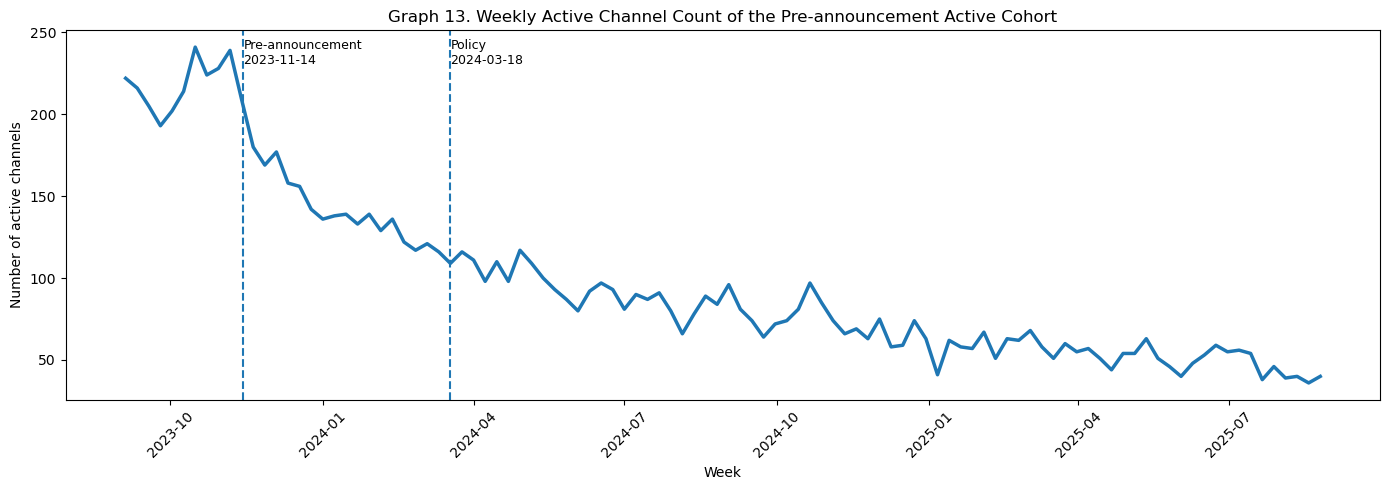

In [61]:
# Plot Graph 13

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph13["week"].dt.tz_localize(None),
    graph13["cohort_active_channels"],
    linewidth=2.5
)

add_policy_lines_section35(ax)

format_axis_section35(
    ax,
    title="Graph 13. Weekly Active Channel Count of the Pre-announcement Active Cohort",
    xlabel="Week",
    ylabel="Number of active channels"
)

plt.show()

<a id="graph-14-average-upload-count-per-channel-in-the-pre-announcement-fixed-cohort"></a>
#### Graph 14. Average Upload Count per Channel in the Pre-announcement Active Cohort

In [62]:
# ---------------------------------------------------------
# Graph 14. Average Upload Count per Channel in the Pre-announcement Active Cohort
# ---------------------------------------------------------
# Outcome definition:
# Average uploads per active cohort channel in each week.
#
# Formula:
#   cohort uploads / cohort active channels

graph14 = graph12.merge(graph13, on="week", how="outer").sort_values("week")

graph14["avg_uploads_per_active_channel"] = (
    graph14["cohort_uploads"] / graph14["cohort_active_channels"].replace(0, np.nan)
)

# Keep the same weekly support structure by anchoring on total cohort uploads
graph14 = complete_weekly_to_last_observed_section35(
    df=graph14,
    week_col="week",
    value_col="cohort_uploads",
    analysis_start=ANALYSIS_START_RAW
)

graph14["avg_uploads_per_active_channel"] = (
    graph14["cohort_uploads"] / graph14["cohort_active_channels"].replace(0, np.nan)
)

print("graph14 shape:", graph14.shape)
display(graph14.head())
display(graph14.tail())

graph14 shape: (104, 4)


,week,cohort_uploads,cohort_active_channels,avg_uploads_per_active_channel
0,2023-09-04 00:00:00+00:00,652,222,2.936937
1,2023-09-11 00:00:00+00:00,639,216,2.958333
2,2023-09-18 00:00:00+00:00,668,205,3.258537
3,2023-09-25 00:00:00+00:00,600,193,3.108808
4,2023-10-02 00:00:00+00:00,596,202,2.950495


,week,cohort_uploads,cohort_active_channels,avg_uploads_per_active_channel
99,2025-07-28 00:00:00+00:00,108,46,2.347826
100,2025-08-04 00:00:00+00:00,113,39,2.897436
101,2025-08-11 00:00:00+00:00,98,40,2.450000
102,2025-08-18 00:00:00+00:00,86,36,2.388889
103,2025-08-25 00:00:00+00:00,93,40,2.325000


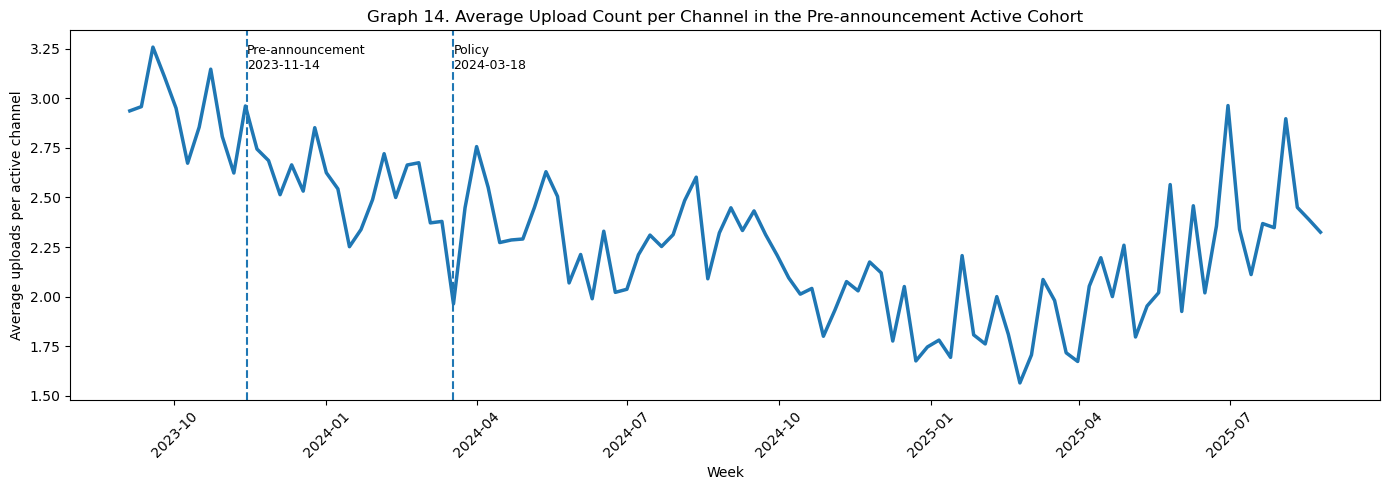

In [63]:
# Plot Graph 14

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph14["week"].dt.tz_localize(None),
    graph14["avg_uploads_per_active_channel"],
    linewidth=2.5
)

add_policy_lines_section35(ax)

format_axis_section35(
    ax,
    title="Graph 14. Average Upload Count per Channel in the Pre-announcement Active Cohort",
    xlabel="Week",
    ylabel="Average uploads per active channel"
)

plt.show()

In [64]:
# ---------------------------------------------------------
# Optional export for collaborators
# ---------------------------------------------------------

graph12.to_csv(OUTPUT_DIR / "graph12_pre_announcement_active_cohort_weekly_upload_count.csv", index=False)
graph13.to_csv(OUTPUT_DIR / "graph13_pre_announcement_active_cohort_weekly_active_channel_count.csv", index=False)
graph14.to_csv(OUTPUT_DIR / "graph14_pre_announcement_active_cohort_avg_upload_per_channel.csv", index=False)

print("Saved:")
print("-", OUTPUT_DIR / "graph12_pre_announcement_active_cohort_weekly_upload_count.csv")
print("-", OUTPUT_DIR / "graph13_pre_announcement_active_cohort_weekly_active_channel_count.csv")
print("-", OUTPUT_DIR / "graph14_pre_announcement_active_cohort_avg_upload_per_channel.csv")

Saved:
- data/visualization_outputs/graph12_pre_announcement_active_cohort_weekly_upload_count.csv
- data/visualization_outputs/graph13_pre_announcement_active_cohort_weekly_active_channel_count.csv
- data/visualization_outputs/graph14_pre_announcement_active_cohort_avg_upload_per_channel.csv


<a id="36-market-structure-and-channel-heterogeneity"></a>
### 3.6 Market Structure and Channel Heterogeneity

<a id="graph-15-upload-dynamics-of-the-top-10-channels"></a>
#### Graph 15. Upload Dynamics of the Top 10 Channels

In [65]:
# ---------------------------------------------------------
# Section 3.6 local helper functions
# ---------------------------------------------------------
# These helpers are used only for market-structure / heterogeneity figures.

def first_full_monday_section36(start_ts):
    """
    Return the first Monday inside the analysis window.
    """
    ts = pd.Timestamp(start_ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    ts = ts.normalize()
    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def complete_weekly_to_last_observed_section36(df, week_col, value_col, analysis_start):
    """
    Build a continuous weekly series from the first Monday in the analysis window
    to the last observed week with positive activity.
    """
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday_section36(analysis_start)

    observed = out[out[value_col] > 0].copy()
    if len(observed) == 0:
        return out.iloc[0:0].copy()

    last_week = observed[week_col].max()

    full_weeks = pd.date_range(start=start_week, end=last_week, freq="W-MON", tz="UTC")

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .fillna(0)
           .rename_axis(week_col)
           .reset_index()
    )
    return out


def add_policy_lines_section36(ax):
    """
    Add the two main policy dates used throughout the notebook.
    """
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_axis_section36(ax, title, xlabel, ylabel):
    """
    Consistent formatting for this section.
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()


def calc_cr4_hhi_gini_entropy(upload_counts):
    """
    Compute concentration metrics from a vector of upload counts.

    upload_counts: pandas Series of nonnegative uploads by channel within a week
    """
    s = pd.to_numeric(upload_counts, errors="coerce").fillna(0)
    s = s[s > 0].sort_values(ascending=False)

    if len(s) == 0:
        return pd.Series({
            "cr4": np.nan,
            "hhi": np.nan,
            "gini": np.nan,
            "entropy": np.nan
        })

    total = s.sum()
    shares = s / total

    # CR4
    cr4 = shares.iloc[:4].sum()

    # HHI
    hhi = (shares ** 2).sum()

    # Gini
    x = np.sort(s.values)
    n = len(x)
    gini = (2 * np.sum((np.arange(1, n + 1)) * x) / (n * np.sum(x))) - (n + 1) / n

    # Entropy
    entropy = -(shares * np.log(shares)).sum()

    return pd.Series({
        "cr4": cr4,
        "hhi": hhi,
        "gini": gini,
        "entropy": entropy
    })

In [66]:
# ---------------------------------------------------------
# Build a weekly channel-upload panel for this section
# ---------------------------------------------------------
# Many market-structure statistics require one row per:
#   (week, channel_id)
# with the channel's upload count in that week.

if "ai_window" not in globals() or "channels" not in globals():
    raise RuntimeError("Please run Section 2 first. 'ai_window' or 'channels' is not available.")

section36_weekly_channel_uploads = (
    ai_window
    .groupby(["week", "channel_id"], as_index=False)
    .agg(uploads=("video_id", "count"))
)

# Attach subscriber metadata where available
section36_weekly_channel_uploads = section36_weekly_channel_uploads.merge(
    channels[["channel_id", "subscriber_count", "channel_created_at"]],
    on="channel_id",
    how="left"
)

print("section36_weekly_channel_uploads shape:", section36_weekly_channel_uploads.shape)
display(section36_weekly_channel_uploads.head())

section36_weekly_channel_uploads shape: (32095, 5)


,week,channel_id,uploads,subscriber_count,channel_created_at
0,2023-08-28 00:00:00+00:00,UC-58AFr18tKsOo6dlp9GlXA,1,1010,2020-06-29 17:42:16.474451+00:00
1,2023-08-28 00:00:00+00:00,UC-6uc1nMrLJUWjj5hHH5hxw,1,976,NaT
2,2023-08-28 00:00:00+00:00,UC-AJuNTBtuIub_tn8yds9ww,2,14800,2020-10-29 00:17:16.585509+00:00
3,2023-08-28 00:00:00+00:00,UC-NqrEU60ZkMFZeOFgQfEMw,1,2350,NaT
4,2023-08-28 00:00:00+00:00,UC-c5wjqPjmli4Zy91nNwsuA,1,17200,2023-06-24 07:29:00.309757+00:00


In [67]:
# ---------------------------------------------------------
# Graph 15. Upload Dynamics of the Top 10 Channels
# ---------------------------------------------------------
# Definition:
# Identify the top 10 channels by total uploads over the analysis window,
# then visualize their monthly upload intensity in a heatmap.
#
# Why monthly rather than weekly?
# Weekly heatmaps for 10 channels can become too sparse and hard to read.
# Monthly aggregation makes long-run dynamics easier to inspect.

top10_channels = (
    ai_window
    .groupby("channel_id", as_index=False)
    .agg(total_uploads=("video_id", "count"))
    .sort_values("total_uploads", ascending=False)
    .head(10)["channel_id"]
    .tolist()
)

graph15_input = ai_window[ai_window["channel_id"].isin(top10_channels)].copy()
graph15_input["month"] = graph15_input["published_at"].dt.tz_localize(None).dt.to_period("M").astype(str)

graph15_heat = (
    graph15_input
    .groupby(["channel_id", "month"])
    .size()
    .unstack(fill_value=0)
)

# Order channels by total uploads within the top-10 set
graph15_heat = graph15_heat.loc[graph15_heat.sum(axis=1).sort_values(ascending=False).index]

print("graph15_heat shape:", graph15_heat.shape)
display(graph15_heat.head())

graph15_heat shape: (10, 24)


month,2023-09,2023-10,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,...,2024-11,2024-12,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08
channel_id,,,,,,,,,,,,,,,,,,,,,
UCwC0dvNBcVzhLr-zs3FolOA,238,198,180,164,69,110,41,60,89,11,...,16,10,17,5,10,7,4,5,0,0
UCpQPIukKb4w8tbwyiPIYxKQ,1,0,1,0,0,0,10,54,83,63,...,30,11,15,3,21,13,34,110,64,7
UCU37rP8Iae7P2gf7P8MehWw,0,16,22,58,77,89,54,57,45,46,...,21,16,20,8,8,16,13,15,17,10
UC6sJ95QRkiBenvKiIt1bfjQ,0,0,0,0,0,0,0,0,0,0,...,136,160,218,0,48,132,12,0,9,0
UCvNnSz6kfo8Ss4KAtXWTlxQ,0,0,0,0,0,0,0,0,0,96,...,14,20,207,54,62,22,11,0,0,1


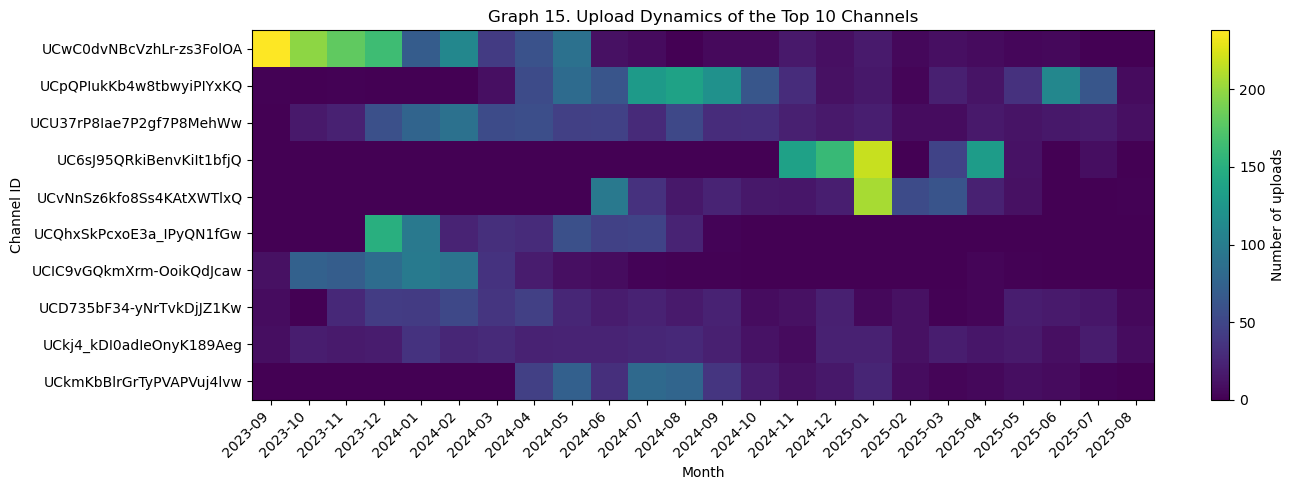

In [68]:
# Plot Graph 15

fig, ax = plt.subplots(figsize=(14, max(4, len(graph15_heat) * 0.5)))

im = ax.imshow(graph15_heat.values, aspect="auto")

ax.set_title("Graph 15. Upload Dynamics of the Top 10 Channels")
ax.set_xlabel("Month")
ax.set_ylabel("Channel ID")

ax.set_xticks(range(len(graph15_heat.columns)))
ax.set_xticklabels(graph15_heat.columns, rotation=45, ha="right")

ax.set_yticks(range(len(graph15_heat.index)))
ax.set_yticklabels(graph15_heat.index)

fig.colorbar(im, ax=ax, label="Number of uploads")
plt.tight_layout()
plt.show()

<a id="graph-16-upload-concentration-by-rank-cutoffs-top-1-top-5-top-10"></a>
#### Graph 16. Upload Concentration by Rank Cutoffs (Top 1, Top 5, Top 10)

In [69]:
# ---------------------------------------------------------
# Graph 16. Upload Concentration by Rank Cutoffs
# ---------------------------------------------------------
# Definition:
# For each week, compute the share of uploads accounted for by:
# - the top 1 channel
# - the top 5 channels
# - the top 10 channels
#
# This complements CR4/HHI by providing directly interpretable rank-based concentration.

def rank_cutoff_shares(df_week):
    s = df_week["uploads"].sort_values(ascending=False).reset_index(drop=True)
    total = s.sum()
    if total == 0:
        return pd.Series({
            "top1_share": np.nan,
            "top5_share": np.nan,
            "top10_share": np.nan
        })
    shares = s / total
    return pd.Series({
        "top1_share": shares.iloc[:1].sum(),
        "top5_share": shares.iloc[:5].sum(),
        "top10_share": shares.iloc[:10].sum()
    })

graph16_raw = (
    section36_weekly_channel_uploads
    .groupby("week")
    .apply(rank_cutoff_shares)
    .reset_index()
)

graph16 = complete_weekly_to_last_observed_section36(
    df=graph16_raw,
    week_col="week",
    value_col="top1_share",
    analysis_start=ANALYSIS_START_RAW
)

print("graph16_raw shape:", graph16_raw.shape)
display(graph16.head())

graph16_raw shape: (105, 4)


,week,top1_share,top5_share,top10_share
0,2023-09-04 00:00:00+00:00,0.070552,0.214724,0.296012
1,2023-09-11 00:00:00+00:00,0.131455,0.305164,0.378717
2,2023-09-18 00:00:00+00:00,0.109281,0.300898,0.396707
3,2023-09-25 00:00:00+00:00,0.103333,0.271667,0.381667
4,2023-10-02 00:00:00+00:00,0.109060,0.243289,0.330537


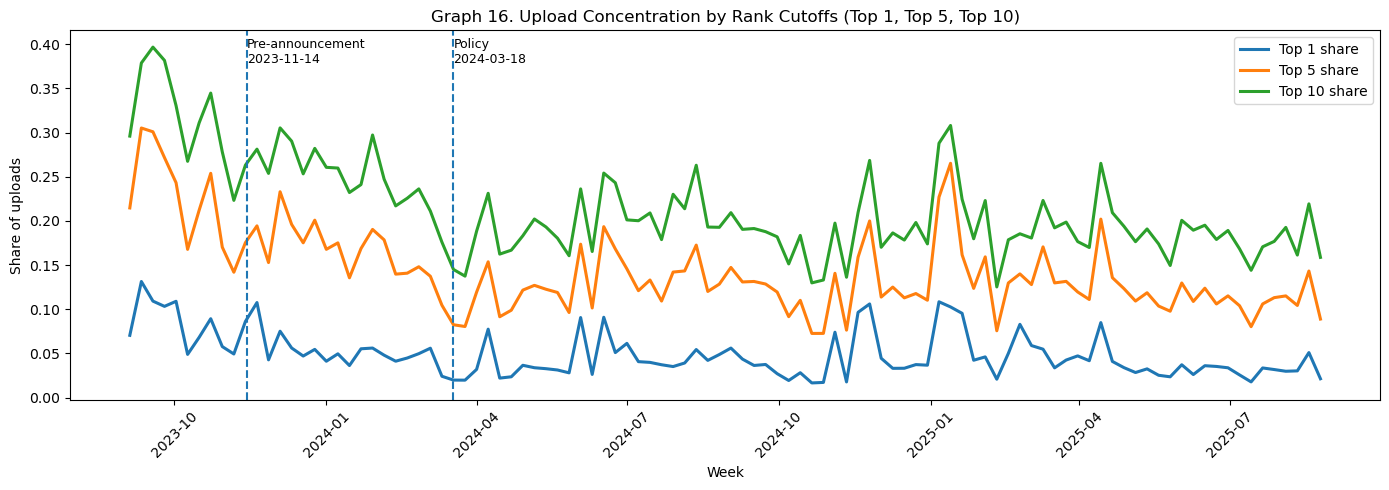

In [70]:
# Plot Graph 16

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(graph16["week"].dt.tz_localize(None), graph16["top1_share"], linewidth=2.2, label="Top 1 share")
ax.plot(graph16["week"].dt.tz_localize(None), graph16["top5_share"], linewidth=2.2, label="Top 5 share")
ax.plot(graph16["week"].dt.tz_localize(None), graph16["top10_share"], linewidth=2.2, label="Top 10 share")

add_policy_lines_section36(ax)
ax.legend()

format_axis_section36(
    ax,
    title="Graph 16. Upload Concentration by Rank Cutoffs (Top 1, Top 5, Top 10)",
    xlabel="Week",
    ylabel="Share of uploads"
)

plt.show()

<a id="graph-17-market-concentration-and-small-channel-supply-share-cr4-hhi-gini-and-upload-share-from-channels-with-fewer-than-100-subscribers"></a>
#### Graph 17. Market Concentration and Small-Channel Supply Share (CR4, HHI, Gini, and Upload Share from Channels with Fewer than 100 Subscribers)

In [71]:
# ---------------------------------------------------------
# Graph 17. Concentration metrics + small-channel share
# ---------------------------------------------------------
# We compute weekly:
# - CR4
# - HHI
# - Gini
# - share of uploads from channels with <100 subscribers
#
# These measures capture different aspects of concentration / inequality.

graph17_conc = (
    section36_weekly_channel_uploads
    .groupby("week")
    .apply(lambda x: calc_cr4_hhi_gini_entropy(x["uploads"]))
    .reset_index()
)

graph17_small = (
    section36_weekly_channel_uploads
    .assign(is_sub_lt_100=lambda x: (pd.to_numeric(x["subscriber_count"], errors="coerce") < 100).fillna(False))
    .groupby("week", as_index=False)
    .agg(
        total_uploads=("uploads", "sum"),
        small_uploads_lt_100=("uploads", lambda s: s[
            section36_weekly_channel_uploads.loc[s.index, "subscriber_count"].lt(100).fillna(False)
        ].sum())
    )
)

# The lambda above is fragile because it references the parent frame by index;
# rebuild more transparently below for safety.
graph17_small = (
    section36_weekly_channel_uploads
    .assign(is_sub_lt_100=lambda x: (pd.to_numeric(x["subscriber_count"], errors="coerce") < 100).fillna(False))
    .groupby("week", as_index=False)
    .agg(
        total_uploads=("uploads", "sum"),
        small_uploads_lt_100=("uploads", lambda s: 0)   # placeholder overwritten below
    )
)

small_100_weekly = (
    section36_weekly_channel_uploads
    .assign(is_sub_lt_100=lambda x: (pd.to_numeric(x["subscriber_count"], errors="coerce") < 100).fillna(False))
    .query("is_sub_lt_100 == True")
    .groupby("week", as_index=False)
    .agg(small_uploads_lt_100=("uploads", "sum"))
)

graph17_small = (
    graph17_small.drop(columns=["small_uploads_lt_100"])
    .merge(small_100_weekly, on="week", how="left")
)

graph17_small["small_uploads_lt_100"] = graph17_small["small_uploads_lt_100"].fillna(0)
graph17_small["small_channel_share_lt_100"] = (
    graph17_small["small_uploads_lt_100"] / graph17_small["total_uploads"].replace(0, np.nan)
)

graph17_raw = graph17_conc.merge(
    graph17_small[["week", "small_channel_share_lt_100"]],
    on="week",
    how="left"
)

graph17 = complete_weekly_to_last_observed_section36(
    df=graph17_raw,
    week_col="week",
    value_col="cr4",
    analysis_start=ANALYSIS_START_RAW
)

print("graph17_raw shape:", graph17_raw.shape)
display(graph17.head())

graph17_raw shape: (105, 6)


,week,cr4,hhi,gini,entropy,small_channel_share_lt_100
0,2023-09-04 00:00:00+00:00,0.187117,0.015850,0.506826,4.836514,0.085890
1,2023-09-11 00:00:00+00:00,0.287950,0.032154,0.544869,4.554106,0.065728
2,2023-09-18 00:00:00+00:00,0.276946,0.028380,0.579480,4.487755,0.053892
3,2023-09-25 00:00:00+00:00,0.243333,0.024211,0.549758,4.545198,0.048333
4,2023-10-02 00:00:00+00:00,0.223154,0.023518,0.526912,4.641258,0.060403


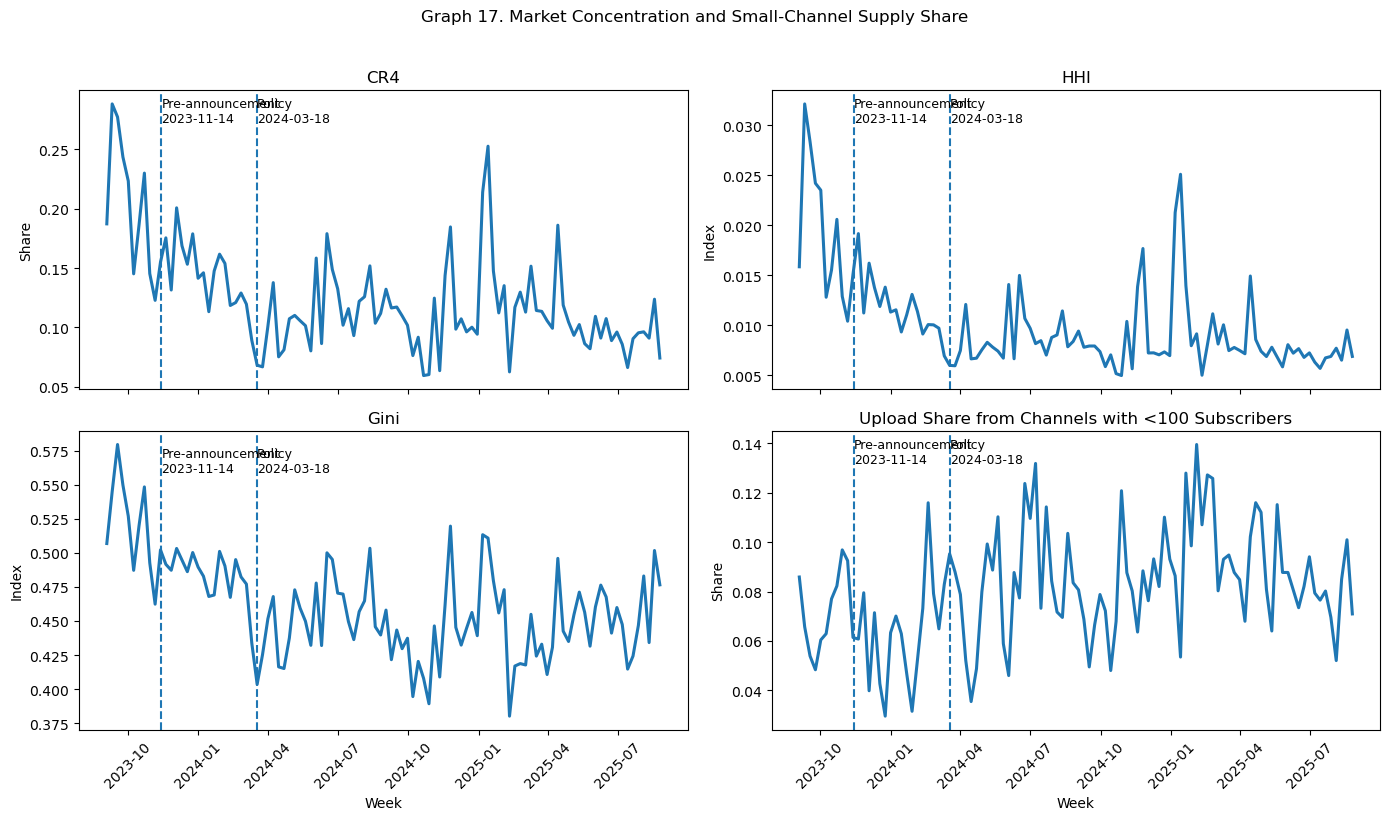

In [72]:
# Plot Graph 17
# Because the four metrics are on different scales, we show them in separate panels.

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

# CR4
axes[0, 0].plot(graph17["week"].dt.tz_localize(None), graph17["cr4"], linewidth=2.2)
add_policy_lines_section36(axes[0, 0])
axes[0, 0].set_title("CR4")
axes[0, 0].set_ylabel("Share")

# HHI
axes[0, 1].plot(graph17["week"].dt.tz_localize(None), graph17["hhi"], linewidth=2.2)
add_policy_lines_section36(axes[0, 1])
axes[0, 1].set_title("HHI")
axes[0, 1].set_ylabel("Index")

# Gini
axes[1, 0].plot(graph17["week"].dt.tz_localize(None), graph17["gini"], linewidth=2.2)
add_policy_lines_section36(axes[1, 0])
axes[1, 0].set_title("Gini")
axes[1, 0].set_ylabel("Index")
axes[1, 0].set_xlabel("Week")

# Small-channel share
axes[1, 1].plot(graph17["week"].dt.tz_localize(None), graph17["small_channel_share_lt_100"], linewidth=2.2)
add_policy_lines_section36(axes[1, 1])
axes[1, 1].set_title("Upload Share from Channels with <100 Subscribers")
axes[1, 1].set_ylabel("Share")
axes[1, 1].set_xlabel("Week")

for ax in axes.flat:
    plt.sca(ax)
    plt.xticks(rotation=45)

fig.suptitle("Graph 17. Market Concentration and Small-Channel Supply Share", y=1.02)
plt.tight_layout()
plt.show()

<a id="graph-18-median-subscriber-count-by-channel-cohort"></a>
#### Graph 18. Median Subscriber Count by Channel Cohort

In [73]:
# ---------------------------------------------------------
# Graph 18. Median Subscriber Count by Channel Cohort
# ---------------------------------------------------------
# Cohorts used here:
# - Pre-announcement active cohort
# - New entrant channels (first AI Cover upload inside analysis window)
# - Reactivated channels (56-day threshold, channel-week level)
#
# For comparability, we summarize median subscriber count by week.

# 1) Pre-announcement active cohort ids
pre_active_start = pd.Timestamp("2023-09-01", tz="UTC")
pre_active_end   = pd.Timestamp("2023-11-13 23:59:59", tz="UTC")

pre_active_ids = set(
    ai_all[
        (ai_all["published_at"] >= pre_active_start) &
        (ai_all["published_at"] <= pre_active_end)
    ]["channel_id"].dropna().astype(str).unique()
)

# 2) First AI upload timing
section36_first_ai = (
    ai_all
    .groupby("channel_id", as_index=False)
    .agg(first_ai_upload_at=("published_at", "min"))
)

section36_first_ai["first_ai_week"] = section36_first_ai["first_ai_upload_at"].dt.to_period("W-SUN").apply(lambda r: r.start_time)
section36_first_ai["first_ai_week"] = pd.to_datetime(section36_first_ai["first_ai_week"], utc=True)

# 3) Channel-week panel for entrant/reactivation
section36_ai_all = ai_all.sort_values(["channel_id", "published_at", "video_id"]).copy()
section36_ai_all["prev_ai_upload_at"] = section36_ai_all.groupby("channel_id")["published_at"].shift(1)
section36_ai_all["gap_days"] = (
    (section36_ai_all["published_at"] - section36_ai_all["prev_ai_upload_at"])
    .dt.total_seconds() / (60 * 60 * 24)
)

section36_ai_window = ai_window.merge(
    section36_ai_all[["video_id", "gap_days"]],
    on="video_id",
    how="left"
)

section36_cw = (
    section36_ai_window
    .groupby(["channel_id", "week"], as_index=False)
    .agg(
        uploads=("video_id", "count"),
        subscriber_count=("subscriber_count", "first")
    )
)

section36_cw = section36_cw.merge(
    section36_first_ai[["channel_id", "first_ai_week"]],
    on="channel_id",
    how="left"
)

section36_cw["is_new_entrant"] = (section36_cw["week"] == section36_cw["first_ai_week"]).astype(int)

# Reactivation at 56-day threshold based on first upload in week
section36_first_uploads = (
    section36_ai_window
    .sort_values(["channel_id", "week", "published_at", "video_id"])
    .groupby(["channel_id", "week"], as_index=False)
    .first()[["channel_id", "week", "gap_days"]]
    .rename(columns={"gap_days": "gap_days_first_upload"})
)

section36_cw = section36_cw.merge(section36_first_uploads, on=["channel_id", "week"], how="left")
section36_cw["is_reactivated_56d"] = (section36_cw["gap_days_first_upload"] >= 56).fillna(False).astype(int)

# Cohort weekly medians
graph18_pre = (
    section36_cw[section36_cw["channel_id"].astype(str).isin(pre_active_ids)]
    .groupby("week", as_index=False)
    .agg(median_subscribers_pre_active=("subscriber_count", "median"))
)

graph18_new = (
    section36_cw[section36_cw["is_new_entrant"] == 1]
    .groupby("week", as_index=False)
    .agg(median_subscribers_new_entrant=("subscriber_count", "median"))
)

graph18_react = (
    section36_cw[section36_cw["is_reactivated_56d"] == 1]
    .groupby("week", as_index=False)
    .agg(median_subscribers_reactivated=("subscriber_count", "median"))
)

graph18_raw = (
    graph18_pre
    .merge(graph18_new, on="week", how="outer")
    .merge(graph18_react, on="week", how="outer")
    .sort_values("week")
)

graph18 = complete_weekly_to_last_observed_section36(
    df=graph18_raw,
    week_col="week",
    value_col="median_subscribers_pre_active",
    analysis_start=ANALYSIS_START_RAW
)

print("graph18_raw shape:", graph18_raw.shape)
display(graph18.head())

/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/2280977382.py:29: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  section36_first_ai["first_ai_week"] = section36_first_ai["first_ai_upload_at"].dt.to_period("W-SUN").apply(lambda r: r.start_time)


graph18_raw shape: (105, 4)


,week,median_subscribers_pre_active,median_subscribers_new_entrant,median_subscribers_reactivated
0,2023-09-04 00:00:00+00:00,1330.0,483.0,985.0
1,2023-09-11 00:00:00+00:00,1330.0,434.0,5335.0
2,2023-09-18 00:00:00+00:00,1480.0,493.5,2830.0
3,2023-09-25 00:00:00+00:00,1960.0,1640.0,8985.0
4,2023-10-02 00:00:00+00:00,1435.0,351.0,1780.0


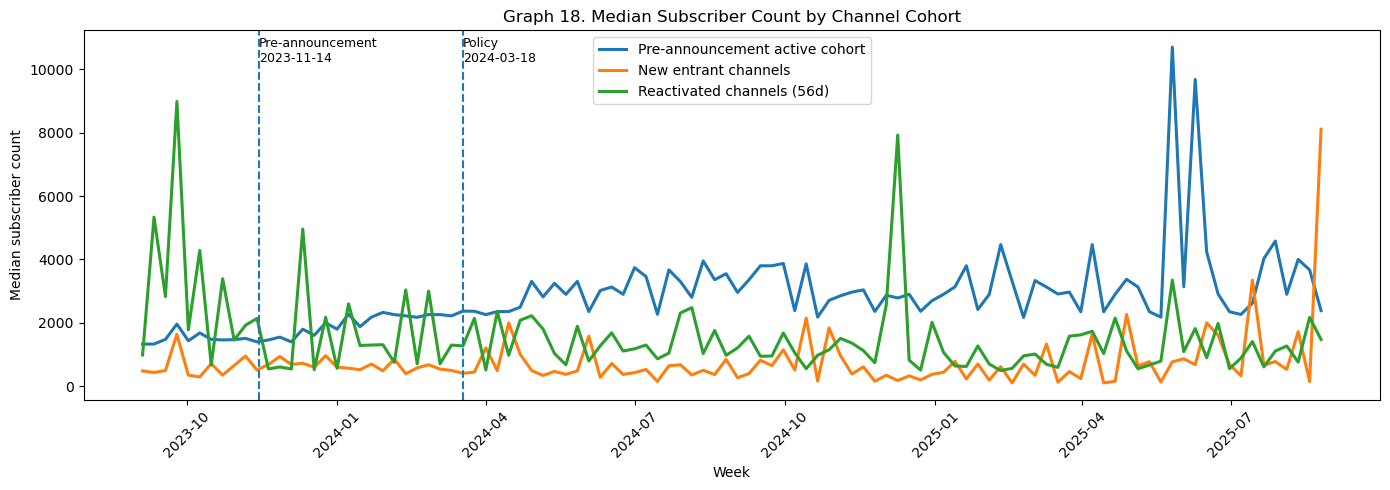

In [74]:
# Plot Graph 18

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph18["week"].dt.tz_localize(None),
    graph18["median_subscribers_pre_active"],
    linewidth=2.2,
    label="Pre-announcement active cohort"
)

ax.plot(
    graph18["week"].dt.tz_localize(None),
    graph18["median_subscribers_new_entrant"],
    linewidth=2.2,
    label="New entrant channels"
)

ax.plot(
    graph18["week"].dt.tz_localize(None),
    graph18["median_subscribers_reactivated"],
    linewidth=2.2,
    label="Reactivated channels (56d)"
)

add_policy_lines_section36(ax)
ax.legend()

format_axis_section36(
    ax,
    title="Graph 18. Median Subscriber Count by Channel Cohort",
    xlabel="Week",
    ylabel="Median subscriber count"
)

plt.show()

<a id="graph-19-entropy-over-time"></a>
#### Graph 19. Entropy Over Time

In [75]:
# ---------------------------------------------------------
# Graph 19. Entropy Over Time
# ---------------------------------------------------------
# Entropy captures how dispersed uploads are across channels.
# Higher entropy generally means more distributed supply across channels.

graph19_raw = (
    section36_weekly_channel_uploads
    .groupby("week")
    .apply(lambda x: calc_cr4_hhi_gini_entropy(x["uploads"]))
    .reset_index()[["week", "entropy"]]
)

graph19 = complete_weekly_to_last_observed_section36(
    df=graph19_raw,
    week_col="week",
    value_col="entropy",
    analysis_start=ANALYSIS_START_RAW
)

print("graph19_raw shape:", graph19_raw.shape)
display(graph19.head())

graph19_raw shape: (105, 2)


,week,entropy
0,2023-09-04 00:00:00+00:00,4.836514
1,2023-09-11 00:00:00+00:00,4.554106
2,2023-09-18 00:00:00+00:00,4.487755
3,2023-09-25 00:00:00+00:00,4.545198
4,2023-10-02 00:00:00+00:00,4.641258


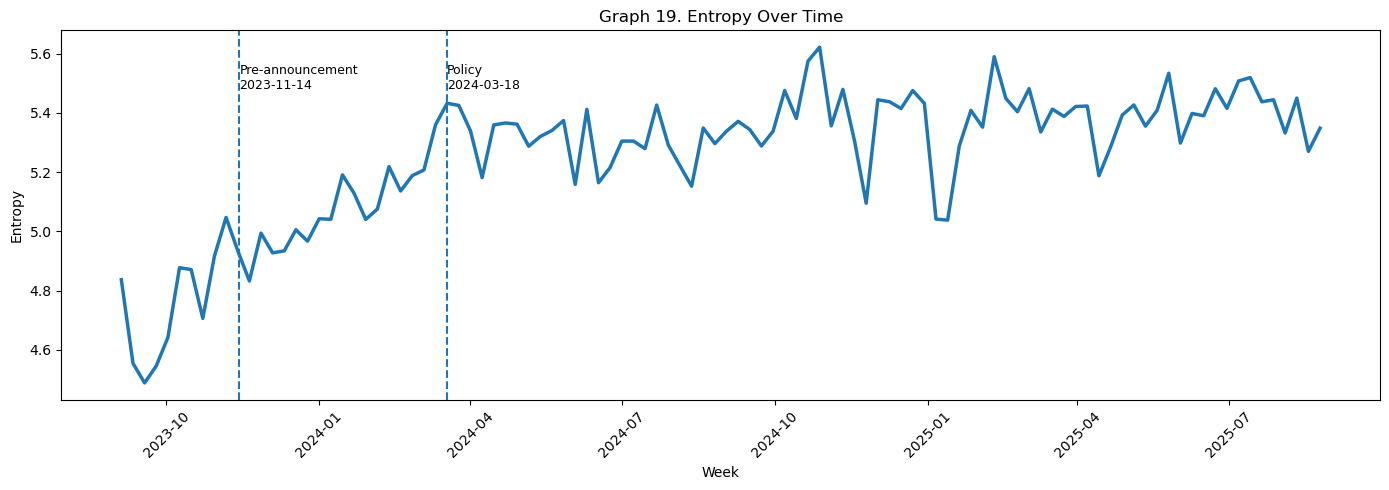

In [76]:
# Plot Graph 19

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    graph19["week"].dt.tz_localize(None),
    graph19["entropy"],
    linewidth=2.5
)

add_policy_lines_section36(ax)

format_axis_section36(
    ax,
    title="Graph 19. Entropy Over Time",
    xlabel="Week",
    ylabel="Entropy"
)

plt.show()

<a id="graph-20-upload-comparison-between-heavy-channels-and-light-channels"></a>
#### Graph 20. Upload Comparison between heavy Channels and light Channels

In [77]:
# ---------------------------------------------------------
# Graph 20. Upload Comparison between heavy Channels and light Channels
# ---------------------------------------------------------
# Definition requested:
# - classify channels using pre-period average weekly uploads
# - divide into quartiles
# - compare the extreme groups:
#   heavy = top quartile
#   light = bottom quartile
#
# Pre-period chosen here:
# before 2023-11-14 (pre-announcement)

PRE_PERIOD_END_FOR_INTENSITY = pd.Timestamp("2023-11-13 23:59:59", tz="UTC")

pre_period_ai = ai_all[ai_all["published_at"] <= PRE_PERIOD_END_FOR_INTENSITY].copy()

pre_period_weekly = (
    pre_period_ai
    .groupby(["channel_id", "week"], as_index=False)
    .agg(uploads=("video_id", "count"))
)

pre_period_avg = (
    pre_period_weekly
    .groupby("channel_id", as_index=False)
    .agg(avg_weekly_uploads_pre_period=("uploads", "mean"))
)

# Only channels present in analysis window matter for comparison
analysis_window_channels = set(ai_window["channel_id"].dropna().astype(str).unique())
pre_period_avg = pre_period_avg[pre_period_avg["channel_id"].isin(analysis_window_channels)].copy()

# Quartile classification
pre_period_avg["intensity_quartile"] = pd.qcut(
    pre_period_avg["avg_weekly_uploads_pre_period"].rank(method="first"),
    q=4,
    labels=["light_q1", "q2", "q3", "heavy_q4"]
).astype(str)

section36_cw_intensity = section36_weekly_channel_uploads.merge(
    pre_period_avg[["channel_id", "intensity_quartile"]],
    on="channel_id",
    how="left"
)

graph20_raw = (
    section36_cw_intensity[section36_cw_intensity["intensity_quartile"].isin(["light_q1", "heavy_q4"])]
    .groupby(["week", "intensity_quartile"], as_index=False)
    .agg(total_uploads=("uploads", "sum"))
)

print("graph20_raw shape:", graph20_raw.shape)
display(graph20_raw.head())

graph20_raw shape: (210, 3)


,week,intensity_quartile,total_uploads
0,2023-08-28 00:00:00+00:00,heavy_q4,198
1,2023-08-28 00:00:00+00:00,light_q1,17
2,2023-09-04 00:00:00+00:00,heavy_q4,464
3,2023-09-04 00:00:00+00:00,light_q1,28
4,2023-09-11 00:00:00+00:00,heavy_q4,467


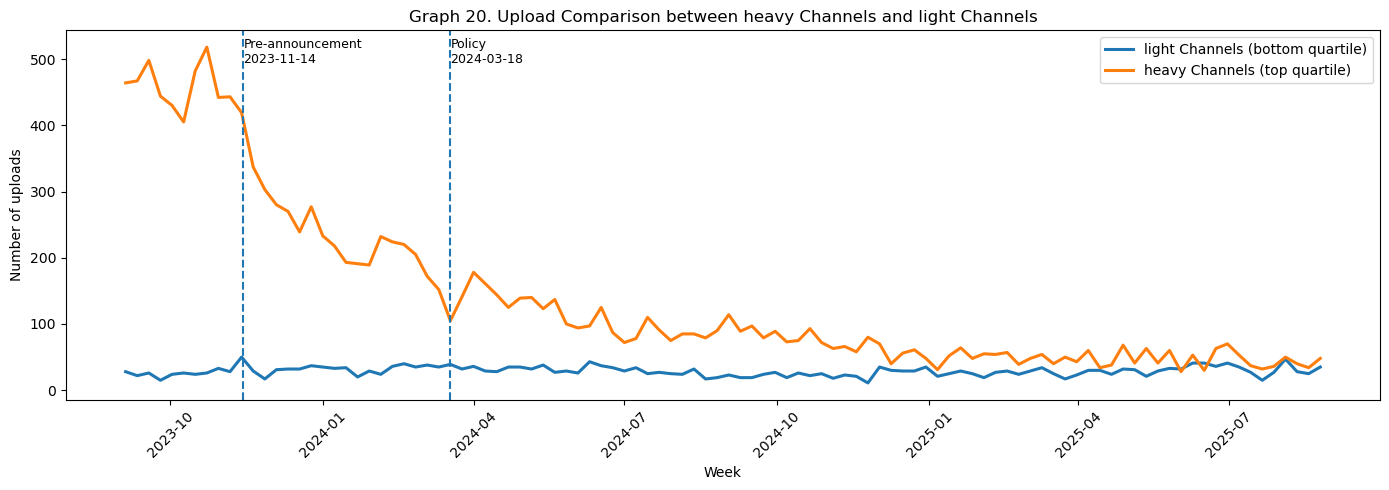

In [78]:
# Plot Graph 20

fig, ax = plt.subplots(figsize=(14, 5))

for group_name, label in [("light_q1", "light Channels (bottom quartile)"),
                          ("heavy_q4", "heavy Channels (top quartile)")]:
    sub = graph20_raw[graph20_raw["intensity_quartile"] == group_name].copy()

    sub = complete_weekly_to_last_observed_section36(
        df=sub,
        week_col="week",
        value_col="total_uploads",
        analysis_start=ANALYSIS_START_RAW
    )

    ax.plot(
        sub["week"].dt.tz_localize(None),
        sub["total_uploads"],
        linewidth=2.2,
        label=label
    )

add_policy_lines_section36(ax)
ax.legend()

format_axis_section36(
    ax,
    title="Graph 20. Upload Comparison between heavy Channels and light Channels",
    xlabel="Week",
    ylabel="Number of uploads"
)

plt.show()

<a id="graph-21-small-channel-upload-share-comparison-fewer-than-100-subscribers-fewer-than-500-subscribers-bottom-30"></a>
#### Graph 21. Small-Channel Upload Share Comparison (Fewer than 100 Subscribers, Fewer than 500 Subscribers, Bottom 30%)

In [79]:
# ---------------------------------------------------------
# Graph 21. Small-Channel Upload Share Comparison
# ---------------------------------------------------------
# We compare three definitions of "small channels":
# - fewer than 100 subscribers
# - fewer than 500 subscribers
# - bottom 30% of subscriber_count in the channel sample

# Bottom-30% threshold computed using channel-level subscriber counts
subscriber_distribution = pd.to_numeric(channels["subscriber_count"], errors="coerce").dropna()
bottom_30_threshold = subscriber_distribution.quantile(0.30)

graph21_input = section36_weekly_channel_uploads.copy()
graph21_input["is_sub_lt_100"] = (pd.to_numeric(graph21_input["subscriber_count"], errors="coerce") < 100).fillna(False)
graph21_input["is_sub_lt_500"] = (pd.to_numeric(graph21_input["subscriber_count"], errors="coerce") < 500).fillna(False)
graph21_input["is_bottom_30pct"] = (pd.to_numeric(graph21_input["subscriber_count"], errors="coerce") <= bottom_30_threshold).fillna(False)

graph21_total = (
    graph21_input
    .groupby("week", as_index=False)
    .agg(total_uploads=("uploads", "sum"))
)

graph21_100 = (
    graph21_input[graph21_input["is_sub_lt_100"]]
    .groupby("week", as_index=False)
    .agg(uploads_lt_100=("uploads", "sum"))
)

graph21_500 = (
    graph21_input[graph21_input["is_sub_lt_500"]]
    .groupby("week", as_index=False)
    .agg(uploads_lt_500=("uploads", "sum"))
)

graph21_bottom30 = (
    graph21_input[graph21_input["is_bottom_30pct"]]
    .groupby("week", as_index=False)
    .agg(uploads_bottom_30pct=("uploads", "sum"))
)

graph21_raw = (
    graph21_total
    .merge(graph21_100, on="week", how="left")
    .merge(graph21_500, on="week", how="left")
    .merge(graph21_bottom30, on="week", how="left")
)

for col in ["uploads_lt_100", "uploads_lt_500", "uploads_bottom_30pct"]:
    graph21_raw[col] = graph21_raw[col].fillna(0)

graph21_raw["share_lt_100"] = graph21_raw["uploads_lt_100"] / graph21_raw["total_uploads"].replace(0, np.nan)
graph21_raw["share_lt_500"] = graph21_raw["uploads_lt_500"] / graph21_raw["total_uploads"].replace(0, np.nan)
graph21_raw["share_bottom_30pct"] = graph21_raw["uploads_bottom_30pct"] / graph21_raw["total_uploads"].replace(0, np.nan)

graph21 = complete_weekly_to_last_observed_section36(
    df=graph21_raw,
    week_col="week",
    value_col="total_uploads",
    analysis_start=ANALYSIS_START_RAW
)

print("bottom_30_threshold:", bottom_30_threshold)
print("graph21_raw shape:", graph21_raw.shape)
display(graph21.head())

bottom_30_threshold: 227.5999999999999
graph21_raw shape: (105, 8)


,week,total_uploads,uploads_lt_100,uploads_lt_500,uploads_bottom_30pct,share_lt_100,share_lt_500,share_bottom_30pct
0,2023-09-04 00:00:00+00:00,652,56,157,89,0.085890,0.240798,0.136503
1,2023-09-11 00:00:00+00:00,639,42,115,63,0.065728,0.179969,0.098592
2,2023-09-18 00:00:00+00:00,668,36,114,83,0.053892,0.170659,0.124251
3,2023-09-25 00:00:00+00:00,600,29,72,46,0.048333,0.120000,0.076667
4,2023-10-02 00:00:00+00:00,596,36,93,73,0.060403,0.156040,0.122483


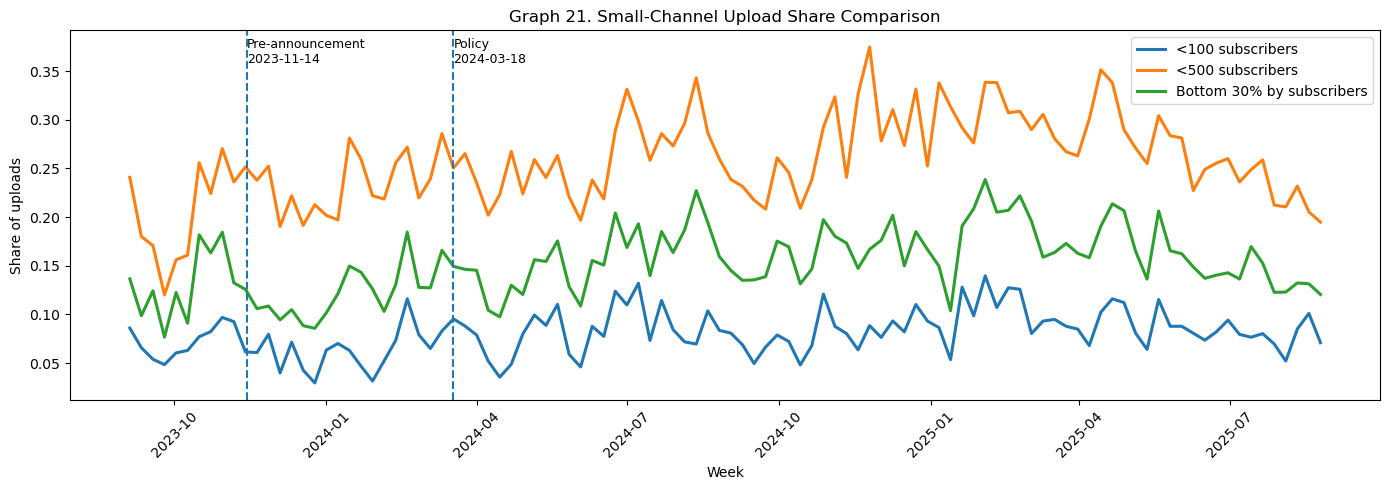

In [80]:
# Plot Graph 21

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(graph21["week"].dt.tz_localize(None), graph21["share_lt_100"], linewidth=2.2, label="<100 subscribers")
ax.plot(graph21["week"].dt.tz_localize(None), graph21["share_lt_500"], linewidth=2.2, label="<500 subscribers")
ax.plot(graph21["week"].dt.tz_localize(None), graph21["share_bottom_30pct"], linewidth=2.2, label="Bottom 30% by subscribers")

add_policy_lines_section36(ax)
ax.legend()

format_axis_section36(
    ax,
    title="Graph 21. Small-Channel Upload Share Comparison",
    xlabel="Week",
    ylabel="Share of uploads"
)

plt.show()

In [81]:
# ---------------------------------------------------------
# Optional export for collaborators
# ---------------------------------------------------------

graph16.to_csv(OUTPUT_DIR / "graph16_upload_concentration_by_rank_cutoffs.csv", index=False)
graph17.to_csv(OUTPUT_DIR / "graph17_market_concentration_and_small_channel_share.csv", index=False)
graph18.to_csv(OUTPUT_DIR / "graph18_median_subscriber_count_by_channel_cohort.csv", index=False)
graph19.to_csv(OUTPUT_DIR / "graph19_entropy_over_time.csv", index=False)
graph21.to_csv(OUTPUT_DIR / "graph21_small_channel_upload_share_comparison.csv", index=False)

# Heatmap / raw panel outputs
graph15_heat.to_csv(OUTPUT_DIR / "graph15_top10_channel_monthly_heatmap_table.csv")
graph20_raw.to_csv(OUTPUT_DIR / "graph20_heavy_vs_light_channel_uploads.csv", index=False)

print("Saved Section 3.6 outputs.")

Saved Section 3.6 outputs.


<a id="37-transition-visualization"></a>
### 3.7 Transition Visualization

<a id="graph-22-upload-weighted-alluvial-plot"></a>
#### Graph 22. Upload-weighted Alluvial Plot

In [82]:
# ---------------------------------------------------------
# Section 3.7 local helper functions
# ---------------------------------------------------------
# This section focuses on state transitions across broad policy periods.
# We define all helpers locally so the logic remains easy to audit.

def add_policy_dates_note():
    print("Period 1: Pre-announcement     = 2023-09-01 to 2023-11-13")
    print("Period 2: Announcement→Policy = 2023-11-14 to 2024-03-17")
    print("Period 3: Post-policy         = 2024-03-18 to 2025-08-31")

In [83]:
# ---------------------------------------------------------
# Period definitions
# ---------------------------------------------------------

PERIOD_1_NAME = "Pre-announcement"
PERIOD_1_START = pd.Timestamp("2023-09-01", tz="UTC")
PERIOD_1_END   = pd.Timestamp("2023-11-13 23:59:59", tz="UTC")

PERIOD_2_NAME = "Announcement→Policy"
PERIOD_2_START = pd.Timestamp("2023-11-14", tz="UTC")
PERIOD_2_END   = pd.Timestamp("2024-03-17 23:59:59", tz="UTC")

PERIOD_3_NAME = "Post-policy"
PERIOD_3_START = pd.Timestamp("2024-03-18", tz="UTC")
PERIOD_3_END   = pd.Timestamp("2025-08-31 23:59:59", tz="UTC")

# Default reactivation threshold for transition analysis
REACTIVATION_THRESHOLD_SECTION37 = 56

add_policy_dates_note()

Period 1: Pre-announcement     = 2023-09-01 to 2023-11-13
Period 2: Announcement→Policy = 2023-11-14 to 2024-03-17
Period 3: Post-policy         = 2024-03-18 to 2025-08-31


In [84]:
# ---------------------------------------------------------
# Build channel-level fast-start flag
# ---------------------------------------------------------
# Definition:
# A channel is classified as "new_fast_start" if its first AI Cover upload
# occurred within 7 days of channel creation.
#
# Why define this at the channel level?
# Because "fast-start" is an entry characteristic of the channel, not of a
# specific weekly upload.

if "ai_all" not in globals() or "channels_in_sample" not in globals():
    raise RuntimeError("Please run Section 2 first. 'ai_all' or 'channels_in_sample' is not available.")

section37_first_ai = (
    ai_all
    .groupby("channel_id", as_index=False)
    .agg(first_ai_upload_at=("published_at", "min"))
)

section37_channel_entry = (
    channels_in_sample[["channel_id", "channel_created_at"]]
    .drop_duplicates()
    .merge(section37_first_ai[["channel_id", "first_ai_upload_at"]], on="channel_id", how="left")
)

section37_channel_entry["days_to_first_ai_upload"] = (
    section37_channel_entry["first_ai_upload_at"] - section37_channel_entry["channel_created_at"]
).dt.total_seconds() / (60 * 60 * 24)

section37_channel_entry["is_new_fast_start"] = (
    section37_channel_entry["days_to_first_ai_upload"]
    .between(0, 7, inclusive="both")
    .fillna(False)
    .astype(int)
)

print("section37_channel_entry shape:", section37_channel_entry.shape)
display(section37_channel_entry.head())

section37_channel_entry shape: (3993, 5)


,channel_id,channel_created_at,first_ai_upload_at,days_to_first_ai_upload,is_new_fast_start
0,UC-ApDbE0Ub-Oyt9_rx8jlUw,2023-02-04 10:15:35.623816+00:00,2025-08-21 13:38:01+00:00,929.140571,0
1,UC-ZST-EDo89vpX41Uepsz-g,2023-08-03 15:21:20.132241+00:00,2023-08-07 16:46:43+00:00,4.059292,1
2,UC-hJLg5VPv_a3DA12NwaN3Q,2024-06-26 20:24:54.374629+00:00,2024-06-27 03:23:00+00:00,0.290343,1
3,UC-ZDsnQ66nsZ7tmY1VowuHQ,NaT,2023-09-17 16:47:30+00:00,NaN,0
4,UC-9H1PtHJ79--fnmknYmsyQ,2022-02-25 01:29:40.628010+00:00,2023-10-07 22:51:39+00:00,589.890259,0


In [85]:
# ---------------------------------------------------------
# Build a channel-week panel with reactivation flags
# ---------------------------------------------------------
# Why use ai_all instead of ai_window for gap computation?
# Because reactivation should depend on the true previous upload in full history,
# not just the previous upload observed inside the analysis window.

section37_ai_all = ai_all.copy()
section37_ai_all = section37_ai_all.sort_values(["channel_id", "published_at", "video_id"]).copy()

section37_ai_all["prev_ai_upload_at"] = section37_ai_all.groupby("channel_id")["published_at"].shift(1)
section37_ai_all["gap_days"] = (
    (section37_ai_all["published_at"] - section37_ai_all["prev_ai_upload_at"])
    .dt.total_seconds() / (60 * 60 * 24)
)

section37_ai_window = ai_window.merge(
    section37_ai_all[["video_id", "gap_days"]],
    on="video_id",
    how="left"
)

section37_cw = (
    section37_ai_window
    .groupby(["channel_id", "week"], as_index=False)
    .agg(
        uploads=("video_id", "count"),
        first_upload_in_week=("published_at", "min")
    )
)

section37_first_uploads_in_week = (
    section37_ai_window
    .sort_values(["channel_id", "week", "published_at", "video_id"])
    .groupby(["channel_id", "week"], as_index=False)
    .first()[["channel_id", "week", "gap_days"]]
    .rename(columns={"gap_days": "gap_days_first_upload"})
)

section37_cw = section37_cw.merge(
    section37_first_uploads_in_week,
    on=["channel_id", "week"],
    how="left"
)

section37_cw["is_reactivated"] = (
    (section37_cw["gap_days_first_upload"] >= REACTIVATION_THRESHOLD_SECTION37)
    .fillna(False)
    .astype(int)
)

section37_cw = section37_cw.merge(
    section37_channel_entry[["channel_id", "is_new_fast_start"]],
    on="channel_id",
    how="left"
)

section37_cw["is_new_fast_start"] = section37_cw["is_new_fast_start"].fillna(0).astype(int)

print("section37_cw shape:", section37_cw.shape)
display(section37_cw.head())

section37_cw shape: (32095, 7)


,channel_id,week,uploads,first_upload_in_week,gap_days_first_upload,is_reactivated,is_new_fast_start
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 00:00:00+00:00,2,2025-05-19 15:00:44+00:00,3.000475,0,0
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-26 00:00:00+00:00,1,2025-05-27 16:15:08+00:00,5.051192,0,0
2,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-04 00:00:00+00:00,1,2023-09-09 05:00:09+00:00,18.791181,0,0
3,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-18 00:00:00+00:00,1,2023-09-24 17:00:29+00:00,15.500231,0,0
4,UC-26K0B-XV5ieqZsQ3QPrcA,2024-02-05 00:00:00+00:00,1,2024-02-10 09:58:15+00:00,138.706782,1,0


In [86]:
# ---------------------------------------------------------
# Period-state classification helpers
# ---------------------------------------------------------
# Each channel gets exactly one state per period.
#
# Priority rule:
# 1. new_fast_start
# 2. reactivated
# 3. continuing
# 4. inactive
#
# Why prioritize this way?
# - new_fast_start captures fast entry into AI Cover after channel creation
# - reactivated captures return after a long inactivity gap
# - continuing captures active participation that is neither new-fast-start nor reactivated
# - inactive means no uploads in the period

def classify_period_state(channel_period_df):
    if len(channel_period_df) == 0:
        return "inactive"
    if channel_period_df["is_new_fast_start"].max() == 1:
        return "new_fast_start"
    if channel_period_df["is_reactivated"].max() == 1:
        return "reactivated"
    if channel_period_df["uploads"].sum() > 0:
        return "continuing"
    return "inactive"


def build_period_states(cw_df, all_channel_ids, period_name, start, end):
    """
    For each channel_id, compute:
    - state in the given period
    - total uploads in the given period
    """
    sub = cw_df[cw_df["week"].between(start, end, inclusive="both")].copy()

    rows = []
    for cid in all_channel_ids:
        ch_sub = sub[sub["channel_id"] == cid].copy()
        state = classify_period_state(ch_sub)
        uploads = ch_sub["uploads"].sum() if len(ch_sub) > 0 else 0

        rows.append({
            "channel_id": cid,
            f"state_{period_name}": state,
            f"uploads_{period_name}": uploads
        })

    return pd.DataFrame(rows)

In [87]:
# ---------------------------------------------------------
# Build the 3-period state table
# ---------------------------------------------------------
# This table is the core input for both:
# - Upload-weighted Alluvial Plot
# - 100% stacked bar composition chart

all_channel_ids_section37 = sorted(section37_cw["channel_id"].dropna().astype(str).unique().tolist())

state_p1 = build_period_states(
    section37_cw,
    all_channel_ids=all_channel_ids_section37,
    period_name="p1",
    start=PERIOD_1_START,
    end=PERIOD_1_END
)

state_p2 = build_period_states(
    section37_cw,
    all_channel_ids=all_channel_ids_section37,
    period_name="p2",
    start=PERIOD_2_START,
    end=PERIOD_2_END
)

state_p3 = build_period_states(
    section37_cw,
    all_channel_ids=all_channel_ids_section37,
    period_name="p3",
    start=PERIOD_3_START,
    end=PERIOD_3_END
)

section37_state_table = (
    state_p1
    .merge(state_p2, on="channel_id", how="outer")
    .merge(state_p3, on="channel_id", how="outer")
)

print("section37_state_table shape:", section37_state_table.shape)
display(section37_state_table.head())

section37_state_table shape: (3458, 7)


,channel_id,state_p1,uploads_p1,state_p2,uploads_p2,state_p3,uploads_p3
0,UC--Fkf3RGD_0MdJS2H_7tcQ,inactive,0,inactive,0,continuing,3
1,UC-26K0B-XV5ieqZsQ3QPrcA,continuing,2,reactivated,2,reactivated,2
2,UC-4mQA-mv5rbe8W-mgbl7vQ,inactive,0,inactive,0,new_fast_start,3
3,UC-58AFr18tKsOo6dlp9GlXA,continuing,2,continuing,10,reactivated,7
4,UC-6Gn8Gjk6c-ZPEdI-Bin-A,continuing,6,inactive,0,inactive,0


In [88]:
# ---------------------------------------------------------
# Graph 22. Upload-weighted Alluvial Plot
# ---------------------------------------------------------
# Link value = uploads in the destination period.
#
# Interpretation:
# - P1 -> P2 link thickness is weighted by uploads in P2
# - P2 -> P3 link thickness is weighted by uploads in P3
#
# This is useful when the research focus is supply contribution, not just
# the number of channels moving between states.

# If plotly is not installed, uncomment the next line:
# %pip install plotly

import plotly.graph_objects as go
import plotly.io as pio

# Use browser renderer if notebook inline rendering fails in some environments
# You can change this to "notebook" if your environment supports it.
pio.renderers.default = "browser"

states = ["new_fast_start", "reactivated", "continuing", "inactive"]

labels_p1 = [f"{PERIOD_1_NAME}: {s}" for s in states]
labels_p2 = [f"{PERIOD_2_NAME}: {s}" for s in states]
labels_p3 = [f"{PERIOD_3_NAME}: {s}" for s in states]
labels = labels_p1 + labels_p2 + labels_p3

label_to_idx = {lab: i for i, lab in enumerate(labels)}

# P1 -> P2: destination-period uploads = uploads_p2
flow12 = (
    section37_state_table
    .groupby(["state_p1", "state_p2"], as_index=False)
    .agg(link_uploads=("uploads_p2", "sum"))
)

# P2 -> P3: destination-period uploads = uploads_p3
flow23 = (
    section37_state_table
    .groupby(["state_p2", "state_p3"], as_index=False)
    .agg(link_uploads=("uploads_p3", "sum"))
)

source = []
target = []
value = []

for _, row in flow12.iterrows():
    if row["link_uploads"] > 0:
        source.append(label_to_idx[f"{PERIOD_1_NAME}: {row['state_p1']}"])
        target.append(label_to_idx[f"{PERIOD_2_NAME}: {row['state_p2']}"])
        value.append(row["link_uploads"])

for _, row in flow23.iterrows():
    if row["link_uploads"] > 0:
        source.append(label_to_idx[f"{PERIOD_2_NAME}: {row['state_p2']}"])
        target.append(label_to_idx[f"{PERIOD_3_NAME}: {row['state_p3']}"])
        value.append(row["link_uploads"])

fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=18,
        thickness=18
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title_text=f"Graph 22. Upload-weighted Alluvial Plot (Reactivation = {REACTIVATION_THRESHOLD_SECTION37}-day threshold)",
    font_size=11,
    height=700
)

fig.show()

In [89]:
# Optional check table for Graph 22
print("P1 -> P2 upload-weighted flows")
display(
    section37_state_table
    .groupby(["state_p1", "state_p2"], as_index=False)
    .agg(link_uploads=("uploads_p2", "sum"))
    .sort_values("link_uploads", ascending=False)
)

print("P2 -> P3 upload-weighted flows")
display(
    section37_state_table
    .groupby(["state_p2", "state_p3"], as_index=False)
    .agg(link_uploads=("uploads_p3", "sum"))
    .sort_values("link_uploads", ascending=False)
)

P1 -> P2 upload-weighted flows


,state_p1,state_p2,link_uploads
0,continuing,continuing,4545
3,inactive,continuing,3273
5,inactive,new_fast_start,1868
8,new_fast_start,new_fast_start,979
2,continuing,reactivated,618
6,inactive,reactivated,401
9,reactivated,continuing,282
11,reactivated,reactivated,104
1,continuing,inactive,0
4,inactive,inactive,0


P2 -> P3 upload-weighted flows


,state_p2,state_p3,link_uploads
3,inactive,continuing,16792
5,inactive,new_fast_start,13703
6,inactive,reactivated,11122
2,continuing,reactivated,7360
0,continuing,continuing,5997
8,new_fast_start,new_fast_start,3593
9,reactivated,continuing,1903
11,reactivated,reactivated,1764
1,continuing,inactive,0
4,inactive,inactive,0


<a id="graph-23-100-stacked-bar-version"></a>
#### Graph 23. 100% Stacked Bar Version

In [90]:
# ---------------------------------------------------------
# Graph 23. 100% Stacked Bar Version
# ---------------------------------------------------------
# Here we summarize the same state system at the period level.
# For each period, total uploads = 100, and we show how much of that supply
# came from each state category.

def summarize_period_upload_shares(cw_df, start, end, period_label):
    sub = cw_df[cw_df["week"].between(start, end, inclusive="both")].copy()

    # We classify state at the channel-period level
    rows = []
    for cid in sorted(sub["channel_id"].dropna().astype(str).unique().tolist()):
        ch_sub = sub[sub["channel_id"] == cid].copy()
        state = classify_period_state(ch_sub)
        uploads = ch_sub["uploads"].sum()

        rows.append({
            "channel_id": cid,
            "period": period_label,
            "state": state,
            "uploads": uploads
        })

    out = pd.DataFrame(rows)

    # If no uploads exist in a period, return an empty summary
    if len(out) == 0:
        return pd.DataFrame(columns=["period", "state", "uploads", "share"])

    summary = (
        out.groupby(["period", "state"], as_index=False)
           .agg(uploads=("uploads", "sum"))
    )

    total_uploads = summary["uploads"].sum()
    summary["share"] = summary["uploads"] / total_uploads if total_uploads > 0 else np.nan

    return summary

stack_p1 = summarize_period_upload_shares(section37_cw, PERIOD_1_START, PERIOD_1_END, PERIOD_1_NAME)
stack_p2 = summarize_period_upload_shares(section37_cw, PERIOD_2_START, PERIOD_2_END, PERIOD_2_NAME)
stack_p3 = summarize_period_upload_shares(section37_cw, PERIOD_3_START, PERIOD_3_END, PERIOD_3_NAME)

graph23_long = pd.concat([stack_p1, stack_p2, stack_p3], ignore_index=True)

# Ensure all states exist in each period
all_periods = [PERIOD_1_NAME, PERIOD_2_NAME, PERIOD_3_NAME]
all_states = ["new_fast_start", "reactivated", "continuing", "inactive"]

full_index = pd.MultiIndex.from_product([all_periods, all_states], names=["period", "state"])
graph23 = (
    graph23_long
    .set_index(["period", "state"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

print("graph23 shape:", graph23.shape)
display(graph23)

graph23 shape: (12, 4)


,period,state,uploads,share
0,Pre-announcement,new_fast_start,1804,0.255127
1,Pre-announcement,reactivated,346,0.048932
2,Pre-announcement,continuing,4921,0.695941
3,Pre-announcement,inactive,0,0.000000
4,Announcement→Policy,new_fast_start,2847,0.235874
5,Announcement→Policy,reactivated,1123,0.093041
6,Announcement→Policy,continuing,8100,0.671085
7,Announcement→Policy,inactive,0,0.000000
8,Post-policy,new_fast_start,17296,0.277919
9,Post-policy,reactivated,20246,0.325321


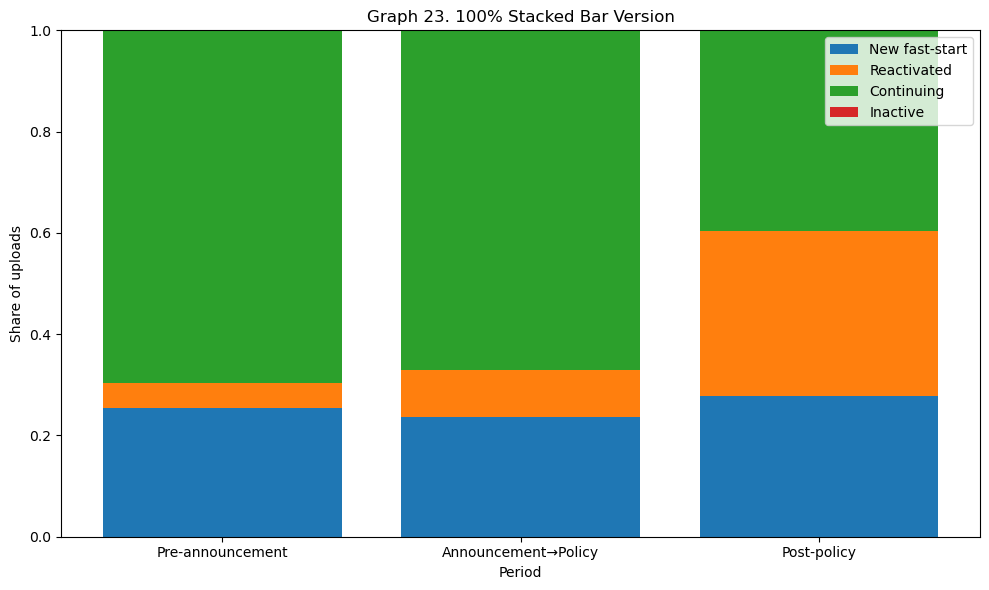

In [93]:
# Plot Graph 23
# ---------------------------------------------------------
# Force the x-axis period order to follow actual time:
# 1) Pre-announcement
# 2) Announcement→Policy
# 3) Post-policy

period_order = [
    PERIOD_1_NAME,   # "Pre-announcement"
    PERIOD_2_NAME,   # "Announcement→Policy"
    PERIOD_3_NAME    # "Post-policy"
]

graph23_wide = (
    graph23
    .pivot(index="period", columns="state", values="share")
    .fillna(0)
    .reindex(period_order)
)

plot_order = ["new_fast_start", "reactivated", "continuing", "inactive"]
plot_labels = {
    "new_fast_start": "New fast-start",
    "reactivated": "Reactivated",
    "continuing": "Continuing",
    "inactive": "Inactive"
}

fig, ax = plt.subplots(figsize=(10, 6))

bottom = np.zeros(len(graph23_wide))

for state in plot_order:
    ax.bar(
        graph23_wide.index,
        graph23_wide[state],
        bottom=bottom,
        label=plot_labels[state]
    )
    bottom = bottom + graph23_wide[state].values

ax.set_title("Graph 23. 100% Stacked Bar Version")
ax.set_xlabel("Period")
ax.set_ylabel("Share of uploads")
ax.legend()
plt.tight_layout()
plt.show()

In [92]:
# ---------------------------------------------------------
# Optional export for collaborators
# ---------------------------------------------------------

section37_state_table.to_csv(OUTPUT_DIR / "graph22_upload_weighted_alluvial_state_table.csv", index=False)
graph23.to_csv(OUTPUT_DIR / "graph23_stacked_bar_period_shares.csv", index=False)

print("Saved:")
print("-", OUTPUT_DIR / "graph22_upload_weighted_alluvial_state_table.csv")
print("-", OUTPUT_DIR / "graph23_stacked_bar_period_shares.csv")

Saved:
- data/visualization_outputs/graph22_upload_weighted_alluvial_state_table.csv
- data/visualization_outputs/graph23_stacked_bar_period_shares.csv


<a id="fig5-style-channel-share-groups"></a>
#### Supplementary Figure. Fig. 5-style Channel Share Groups

In [94]:
# ---------------------------------------------------------
# Fig. 5-style channel grouping by pre/post share change
# ---------------------------------------------------------
# Concept:
# 1) Compute each channel's upload share in a pre period
# 2) Compute each channel's upload share in a post period
# 3) delta_share = post_share - pre_share
# 4) Group channels by delta_share (quartiles)
# 5) Plot how those grouped channel sets account for upload share over time
#
# This mirrors the logic of Fig. 5 in the paper:
# groups are formed by how usage changes before vs after the AI shock,
# and low-frequency items can be grouped into a gray long-tail bucket.

def month_floor_fig5(series):
    """
    Convert datetime values to month start.
    Used because monthly composition is easier to read than weekly for this figure.
    """
    s = pd.to_datetime(series, utc=True, errors="coerce")
    return pd.Series(
        [pd.NaT if pd.isna(x) else pd.Timestamp(x.year, x.month, 1, tz="UTC") for x in s],
        index=s.index
    )


def add_policy_lines_monthly_fig5(ax):
    """
    Add policy markers for reference.
    """
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_axis_fig5(ax, title, xlabel, ylabel):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [95]:
# ---------------------------------------------------------
# Define pre/post windows for grouping
# ---------------------------------------------------------
# Recommended default:
# - Pre period  = 2023-09-01 to 2023-11-13
# - Post period = 2024-03-18 to 2025-08-31
#
# Why skip the announcement→policy window here?
# Because for grouping we want a cleaner "before vs after implementation" comparison.

FIG5_PRE_START  = pd.Timestamp("2023-09-01", tz="UTC")
FIG5_PRE_END    = pd.Timestamp("2023-11-13 23:59:59", tz="UTC")
FIG5_POST_START = pd.Timestamp("2024-03-18", tz="UTC")
FIG5_POST_END   = pd.Timestamp("2025-08-31 23:59:59", tz="UTC")

# Long-tail rule:
# channels with very low total uploads across the full analysis window
# are grouped into a gray "long_tail" bucket.
#
# You can tune this threshold.
# A slightly larger threshold makes the figure cleaner.
FIG5_LONG_TAIL_MIN_TOTAL_UPLOADS = 5

print("Pre period :", FIG5_PRE_START, "to", FIG5_PRE_END)
print("Post period:", FIG5_POST_START, "to", FIG5_POST_END)
print("Long-tail threshold (total uploads):", FIG5_LONG_TAIL_MIN_TOTAL_UPLOADS)

Pre period : 2023-09-01 00:00:00+00:00 to 2023-11-13 23:59:59+00:00
Post period: 2024-03-18 00:00:00+00:00 to 2025-08-31 23:59:59+00:00
Long-tail threshold (total uploads): 5


In [96]:
# ---------------------------------------------------------
# Step 1. Compute channel-level pre/post shares
# ---------------------------------------------------------

if "ai_window" not in globals():
    raise RuntimeError("Please run Section 2 first. 'ai_window' is not available.")

fig5_ai = ai_window.copy()

# Pre-period uploads by channel
fig5_pre = (
    fig5_ai[
        (fig5_ai["published_at"] >= FIG5_PRE_START) &
        (fig5_ai["published_at"] <= FIG5_PRE_END)
    ]
    .groupby("channel_id", as_index=False)
    .agg(pre_uploads=("video_id", "count"))
)

# Post-period uploads by channel
fig5_post = (
    fig5_ai[
        (fig5_ai["published_at"] >= FIG5_POST_START) &
        (fig5_ai["published_at"] <= FIG5_POST_END)
    ]
    .groupby("channel_id", as_index=False)
    .agg(post_uploads=("video_id", "count"))
)

# Total uploads over the whole analysis window
fig5_total = (
    fig5_ai
    .groupby("channel_id", as_index=False)
    .agg(total_uploads=("video_id", "count"))
)

fig5_channel = (
    fig5_total
    .merge(fig5_pre, on="channel_id", how="left")
    .merge(fig5_post, on="channel_id", how="left")
)

fig5_channel["pre_uploads"] = fig5_channel["pre_uploads"].fillna(0)
fig5_channel["post_uploads"] = fig5_channel["post_uploads"].fillna(0)

pre_total_uploads = fig5_channel["pre_uploads"].sum()
post_total_uploads = fig5_channel["post_uploads"].sum()

fig5_channel["pre_share"] = fig5_channel["pre_uploads"] / pre_total_uploads if pre_total_uploads > 0 else np.nan
fig5_channel["post_share"] = fig5_channel["post_uploads"] / post_total_uploads if post_total_uploads > 0 else np.nan
fig5_channel["delta_share"] = fig5_channel["post_share"].fillna(0) - fig5_channel["pre_share"].fillna(0)

# ---------------------------------------------------------
# Step 2. Define long-tail vs non-long-tail channels
# ---------------------------------------------------------
fig5_channel["is_long_tail"] = fig5_channel["total_uploads"] < FIG5_LONG_TAIL_MIN_TOTAL_UPLOADS

# ---------------------------------------------------------
# Step 3. Quartile grouping based on delta_share
# ---------------------------------------------------------
# Only non-long-tail channels are grouped into quartiles.
# Long-tail channels are assigned to a separate "long_tail" bucket.
non_tail = fig5_channel.loc[~fig5_channel["is_long_tail"]].copy()

if len(non_tail) >= 4:
    non_tail["change_group"] = pd.qcut(
        non_tail["delta_share"].rank(method="first"),
        q=4,
        labels=[
            "declining_q1",
            "declining_to_stable_q2",
            "stable_to_rising_q3",
            "rising_q4"
        ]
    ).astype(str)
else:
    # fallback if too few channels
    non_tail["change_group"] = "stable_to_rising_q3"

fig5_channel = fig5_channel.merge(
    non_tail[["channel_id", "change_group"]],
    on="channel_id",
    how="left"
)

fig5_channel["change_group"] = np.where(
    fig5_channel["is_long_tail"],
    "long_tail",
    fig5_channel["change_group"]
)

print("fig5_channel shape:", fig5_channel.shape)
display(fig5_channel.sort_values("delta_share", ascending=False).head(10))
display(fig5_channel.sort_values("delta_share", ascending=True).head(10))
print(fig5_channel["change_group"].value_counts(dropna=False))

fig5_channel shape: (3458, 9)


,channel_id,total_uploads,pre_uploads,post_uploads,pre_share,post_share,delta_share,is_long_tail,change_group
2885,UCpQPIukKb4w8tbwyiPIYxKQ,971,1.0,968.0,0.000147,0.015554,0.015407,False,rising_q4
409,UC6sJ95QRkiBenvKiIt1bfjQ,715,0.0,715.0,0.000000,0.011489,0.011489,False,rising_q4
3196,UCvNnSz6kfo8Ss4KAtXWTlxQ,575,0.0,575.0,0.000000,0.009239,0.009239,False,rising_q4
2660,UCkmKbBlrGrTyPVAPVuj4lvw,449,0.0,449.0,0.000000,0.007215,0.007215,False,rising_q4
155,UC1bZH1hpIrw8k9VP8_wTw8g,431,0.0,431.0,0.000000,0.006925,0.006925,False,rising_q4
32,UC-SK3AwA225LLXhv3AlZYKg,417,0.0,417.0,0.000000,0.006701,0.006701,False,rising_q4
1731,UCVZEM7UkETmxetacd9B9zPA,387,0.0,387.0,0.000000,0.006218,0.006218,False,rising_q4
9,UC-AJuNTBtuIub_tn8yds9ww,437,4.0,412.0,0.000590,0.006620,0.006030,False,rising_q4
823,UCEKsAz14DQMjXfy1pNb2otw,426,0.0,350.0,0.000000,0.005624,0.005624,False,rising_q4
1037,UCI9fSHujG-Btg-B4iCtFSNQ,345,0.0,345.0,0.000000,0.005544,0.005544,False,rising_q4


,channel_id,total_uploads,pre_uploads,post_uploads,pre_share,post_share,delta_share,is_long_tail,change_group
3236,UCwC0dvNBcVzhLr-zs3FolOA,1253,489.0,266.0,0.072124,0.004274,-0.067850,False,declining_q1
2341,UCfHiutp6YEutVFL6GJIzcHg,320,265.0,17.0,0.039086,0.000273,-0.038812,False,declining_q1
2464,UChLdcwwoKH9SAebjFwB4QJw,233,217.0,16.0,0.032006,0.000257,-0.031749,False,declining_q1
3408,UCyzvitoJFMVgOU2CjVGDymQ,192,145.0,0.0,0.021386,0.000000,-0.021386,False,declining_q1
2164,UCc4g0JH2RWzcN9wXh7vUlGQ,136,132.0,0.0,0.019469,0.000000,-0.019469,False,declining_q1
1038,UCIC9vGQkmXrm-OoikQdJcaw,508,121.0,57.0,0.017847,0.000916,-0.016931,False,declining_q1
1816,UCX-WouaPlOeRVnI60Glgd0g,198,108.0,3.0,0.015929,0.000048,-0.015881,False,declining_q1
1798,UCWi0NHCcwJ1m9llZQclFp6A,106,101.0,5.0,0.014897,0.000080,-0.014816,False,declining_q1
2979,UCqxp6ak3TKvqCIJOSwU54UA,113,85.0,0.0,0.012537,0.000000,-0.012537,False,declining_q1
1406,UCPFFm0FMZQpCw4DRdLr_zcw,109,76.0,3.0,0.011209,0.000048,-0.011161,False,declining_q1


change_group
long_tail                 1402
declining_q1               514
stable_to_rising_q3        514
rising_q4                  514
declining_to_stable_q2     514
Name: count, dtype: int64


In [97]:
# ---------------------------------------------------------
# Step 4. Build monthly upload composition by group
# ---------------------------------------------------------
# We use monthly shares because this kind of composition plot
# is usually easier to read at the monthly level than the weekly level.

fig5_monthly = fig5_ai.copy()
fig5_monthly["month"] = month_floor_fig5(fig5_monthly["published_at"])

fig5_monthly = fig5_monthly.merge(
    fig5_channel[["channel_id", "change_group"]],
    on="channel_id",
    how="left"
)

fig5_monthly["change_group"] = fig5_monthly["change_group"].fillna("long_tail")

fig5_monthly_group = (
    fig5_monthly
    .groupby(["month", "change_group"], as_index=False)
    .agg(uploads=("video_id", "count"))
)

fig5_monthly_total = (
    fig5_monthly
    .groupby("month", as_index=False)
    .agg(total_uploads=("video_id", "count"))
)

fig5_monthly_group = fig5_monthly_group.merge(fig5_monthly_total, on="month", how="left")
fig5_monthly_group["share"] = fig5_monthly_group["uploads"] / fig5_monthly_group["total_uploads"].replace(0, np.nan)

# Wide format for plotting
fig5_plot = (
    fig5_monthly_group
    .pivot(index="month", columns="change_group", values="share")
    .fillna(0)
    .sort_index()
)

# Explicit order for interpretability
fig5_group_order = [
    "rising_q4",
    "stable_to_rising_q3",
    "declining_to_stable_q2",
    "declining_q1",
    "long_tail"
]

for col in fig5_group_order:
    if col not in fig5_plot.columns:
        fig5_plot[col] = 0

fig5_plot = fig5_plot[fig5_group_order]

print("fig5_plot shape:", fig5_plot.shape)
display(fig5_plot.head())
display(fig5_plot.tail())

fig5_plot shape: (24, 5)


change_group,rising_q4,stable_to_rising_q3,declining_to_stable_q2,declining_q1,long_tail
month,,,,,
2023-09-01 00:00:00+00:00,0.013262,0.004301,0.002509,0.905376,0.074552
2023-10-01 00:00:00+00:00,0.022841,0.004283,0.003569,0.898287,0.071021
2023-11-01 00:00:00+00:00,0.060015,0.027246,0.022828,0.835788,0.054124
2023-12-01 00:00:00+00:00,0.191946,0.060403,0.087584,0.619128,0.040940
2024-01-01 00:00:00+00:00,0.266796,0.116602,0.106266,0.471253,0.039083


change_group,rising_q4,stable_to_rising_q3,declining_to_stable_q2,declining_q1,long_tail
month,,,,,
2025-04-01 00:00:00+00:00,0.722038,0.155864,0.035574,0.063612,0.022912
2025-05-01 00:00:00+00:00,0.733421,0.158947,0.027368,0.052368,0.027895
2025-06-01 00:00:00+00:00,0.751429,0.143377,0.034286,0.049610,0.021299
2025-07-01 00:00:00+00:00,0.720232,0.139884,0.060854,0.054268,0.024763
2025-08-01 00:00:00+00:00,0.695317,0.177818,0.054297,0.041945,0.030623


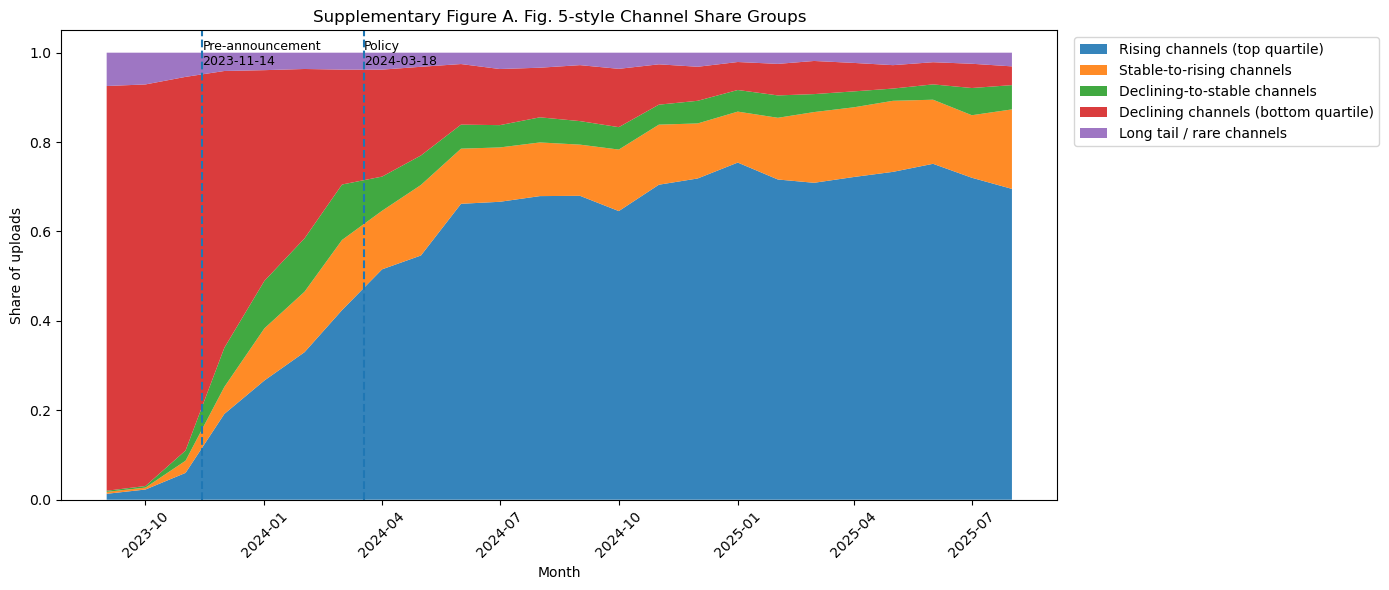

In [98]:
# ---------------------------------------------------------
# Supplementary Figure A. Fig. 5-style stacked area chart
# ---------------------------------------------------------
# Interpretation:
# - rising_q4: channels whose supply share increased the most post-policy
# - declining_q1: channels whose share declined the most
# - long_tail: low-frequency channels grouped together

fig, ax = plt.subplots(figsize=(14, 6))

x = fig5_plot.index.tz_localize(None)

ax.stackplot(
    x,
    [fig5_plot[col].values for col in fig5_group_order],
    labels=[
        "Rising channels (top quartile)",
        "Stable-to-rising channels",
        "Declining-to-stable channels",
        "Declining channels (bottom quartile)",
        "Long tail / rare channels"
    ],
    alpha=0.9
)

add_policy_lines_monthly_fig5(ax)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))

format_axis_fig5(
    ax,
    title="Supplementary Figure A. Fig. 5-style Channel Share Groups",
    xlabel="Month",
    ylabel="Share of uploads"
)

plt.show()

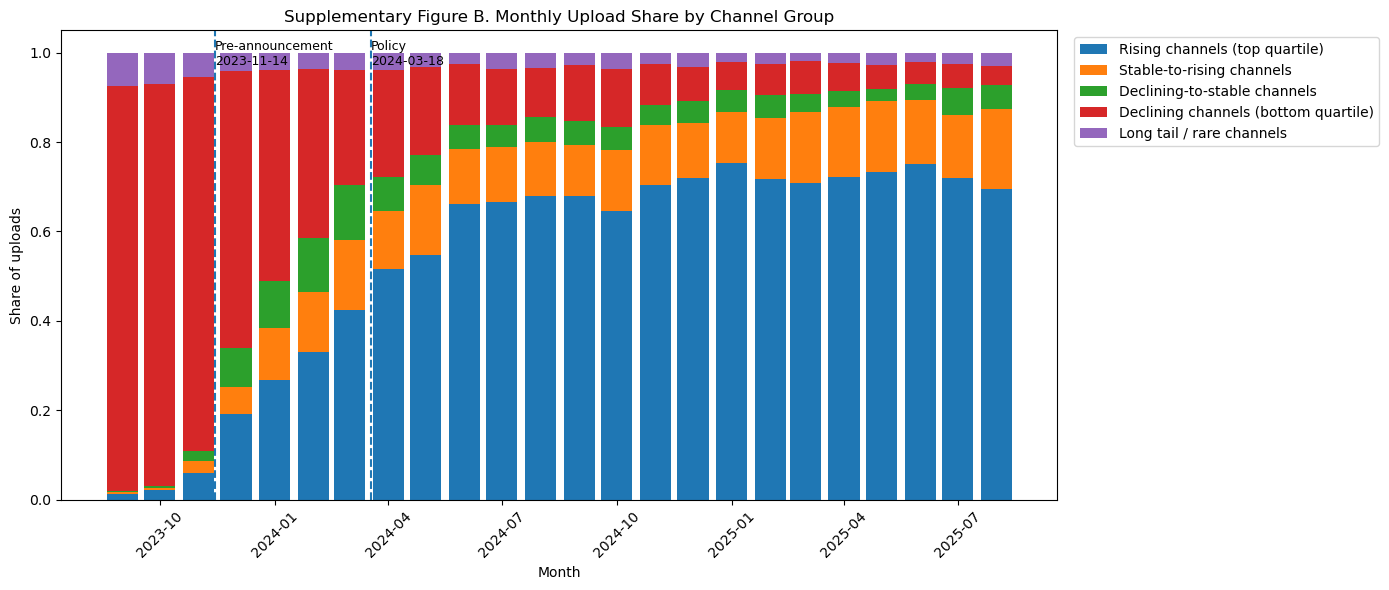

In [99]:
# ---------------------------------------------------------
# Supplementary Figure B. Monthly 100% stacked bar version
# ---------------------------------------------------------
# This version is sometimes easier to read than an area chart
# if you want to compare relative shares month by month.

fig, ax = plt.subplots(figsize=(14, 6))

bottom = np.zeros(len(fig5_plot))
x = fig5_plot.index.tz_localize(None)

labels_map = {
    "rising_q4": "Rising channels (top quartile)",
    "stable_to_rising_q3": "Stable-to-rising channels",
    "declining_to_stable_q2": "Declining-to-stable channels",
    "declining_q1": "Declining channels (bottom quartile)",
    "long_tail": "Long tail / rare channels"
}

for col in fig5_group_order:
    ax.bar(
        x,
        fig5_plot[col].values,
        bottom=bottom,
        width=25,
        label=labels_map[col]
    )
    bottom = bottom + fig5_plot[col].values

add_policy_lines_monthly_fig5(ax)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))

format_axis_fig5(
    ax,
    title="Supplementary Figure B. Monthly Upload Share by Channel Group",
    xlabel="Month",
    ylabel="Share of uploads"
)

plt.show()

<a id="weekly-supply-composition-by-channel-type-5way"></a>
#### Supplementary Figure. Weekly Supply Composition by Channel Type (5-way)

In [100]:
# ---------------------------------------------------------
# 5-way supply composition: local helpers
# ---------------------------------------------------------

def first_full_monday_supply_comp(start_ts):
    """
    Return the first Monday inside the analysis window.
    """
    ts = pd.Timestamp(start_ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    ts = ts.normalize()
    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def complete_weekly_to_last_observed_supply_comp(df, week_col, value_col, analysis_start):
    """
    Create a continuous weekly series from the first Monday in the analysis window
    to the last observed week with positive activity.
    """
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday_supply_comp(analysis_start)

    observed = out[out[value_col] > 0].copy()
    if len(observed) == 0:
        return out.iloc[0:0].copy()

    last_week = observed[week_col].max()

    full_weeks = pd.date_range(start=start_week, end=last_week, freq="W-MON", tz="UTC")

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .fillna(0)
           .rename_axis(week_col)
           .reset_index()
    )
    return out


def month_floor_supply_comp(series):
    """
    Convert datetimes to month start.
    """
    s = pd.to_datetime(series, utc=True, errors="coerce")
    return pd.Series(
        [pd.NaT if pd.isna(x) else pd.Timestamp(x.year, x.month, 1, tz="UTC") for x in s],
        index=s.index
    )


def add_policy_lines_supply_comp(ax):
    """
    Add pre-announcement and policy dates.
    """
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_axis_supply_comp(ax, title, xlabel, ylabel):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [102]:
# ---------------------------------------------------------
# Step 1. Build the core channel-week input
# ---------------------------------------------------------
# We use:
# - ai_all for full-history gap calculation
# - ai_window for plotting window
#
# We classify each channel-week into exactly one of five groups.

if "ai_all" not in globals() or "ai_window" not in globals() or "channels_in_sample" not in globals():
    raise RuntimeError("Please run Section 2 first. Required objects are missing.")

# Work on copies
_supply_ai_all = ai_all.copy()
_supply_ai_window = ai_window.copy()
_supply_channels = channels_in_sample.copy()

# Standardize IDs just in case
for df_ in [_supply_ai_all, _supply_ai_window, _supply_channels]:
    df_["channel_id"] = df_["channel_id"].astype(str).str.strip()

# 1) Top 10 channels over the full analysis window
top10_core_ids = set(
    _supply_ai_window
    .groupby("channel_id", as_index=False)
    .agg(total_uploads=("video_id", "count"))
    .sort_values("total_uploads", ascending=False)
    .head(10)["channel_id"]
    .astype(str)
    .tolist()
)

print("Top 10 core channels:", len(top10_core_ids))

# 2) Pre-announcement active legacy cohort
pre_active_start = pd.Timestamp("2023-09-01", tz="UTC")
pre_active_end   = pd.Timestamp("2023-11-13 23:59:59", tz="UTC")

pre_announcement_active_legacy_ids = set(
    _supply_ai_all[
        (_supply_ai_all["published_at"] >= pre_active_start) &
        (_supply_ai_all["published_at"] <= pre_active_end)
    ]["channel_id"].dropna().astype(str).unique()
)

print("Pre-announcement active legacy channels:", len(pre_announcement_active_legacy_ids))

# 3) Channel-level first AI upload
supply_first_ai = (
    _supply_ai_all
    .groupby("channel_id", as_index=False)
    .agg(first_ai_upload_at=("published_at", "min"))
)

# Safer weekly conversion: Monday of the week containing first_ai_upload_at
supply_first_ai["first_ai_week"] = (
    supply_first_ai["first_ai_upload_at"]
    .dt.to_period("W-SUN")
    .dt.start_time
)
supply_first_ai["first_ai_week"] = pd.to_datetime(supply_first_ai["first_ai_week"], utc=True)

# 4) Fast-start entry flag
supply_channel_entry = (
    _supply_channels[["channel_id", "channel_created_at"]]
    .drop_duplicates()
    .merge(supply_first_ai[["channel_id", "first_ai_upload_at"]], on="channel_id", how="left")
)

supply_channel_entry["days_to_first_ai_upload"] = (
    supply_channel_entry["first_ai_upload_at"] - supply_channel_entry["channel_created_at"]
).dt.total_seconds() / (60 * 60 * 24)

supply_channel_entry["is_new_fast_start"] = (
    supply_channel_entry["days_to_first_ai_upload"]
    .between(0, 7, inclusive="both")
    .fillna(False)
    .astype(int)
)

# 5) Full-history gaps for reactivation
_supply_ai_all = _supply_ai_all.sort_values(["channel_id", "published_at", "video_id"]).copy()
_supply_ai_all["prev_ai_upload_at"] = _supply_ai_all.groupby("channel_id")["published_at"].shift(1)
_supply_ai_all["gap_days"] = (
    (_supply_ai_all["published_at"] - _supply_ai_all["prev_ai_upload_at"])
    .dt.total_seconds() / (60 * 60 * 24)
)

# Bring gap info into analysis window
supply_ai_window = _supply_ai_window.merge(
    _supply_ai_all[["video_id", "gap_days"]],
    on="video_id",
    how="left"
)

# 6) Channel-week panel
supply_cw = (
    supply_ai_window
    .groupby(["channel_id", "week"], as_index=False)
    .agg(
        uploads=("video_id", "count"),
        first_upload_in_week=("published_at", "min"),
        subscriber_count=("subscriber_count", "first")
    )
)

# Attach first AI week
supply_cw = supply_cw.merge(
    supply_first_ai[["channel_id", "first_ai_week"]],
    on="channel_id",
    how="left"
)

supply_cw["is_new_entrant_week"] = (supply_cw["week"] == supply_cw["first_ai_week"]).astype(int)

# First-upload gap in each week
supply_first_uploads_in_week = (
    supply_ai_window
    .sort_values(["channel_id", "week", "published_at", "video_id"])
    .groupby(["channel_id", "week"], as_index=False)
    .first()[["channel_id", "week", "gap_days"]]
    .rename(columns={"gap_days": "gap_days_first_upload"})
)

supply_cw = supply_cw.merge(
    supply_first_uploads_in_week,
    on=["channel_id", "week"],
    how="left"
)

REACTIVATION_THRESHOLD_SUPPLY = 56

supply_cw["is_reactivated_week"] = (
    (supply_cw["gap_days_first_upload"] >= REACTIVATION_THRESHOLD_SUPPLY)
    .fillna(False)
    .astype(int)
)

# Attach fast-start flag
supply_cw = supply_cw.merge(
    supply_channel_entry[["channel_id", "is_new_fast_start"]],
    on="channel_id",
    how="left"
)

supply_cw["is_new_fast_start"] = supply_cw["is_new_fast_start"].fillna(0).astype(int)

print("supply_first_ai shape:", supply_first_ai.shape)
print("supply_channel_entry shape:", supply_channel_entry.shape)
print("supply_ai_window shape:", supply_ai_window.shape)
print("supply_cw shape:", supply_cw.shape)

display(supply_cw.head())

Top 10 core channels: 10
Pre-announcement active legacy channels: 796


/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/1190645461.py:58: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("W-SUN")


supply_first_ai shape: (3993, 3)
supply_channel_entry shape: (3993, 5)
supply_ai_window shape: (81670, 19)
supply_cw shape: (32095, 10)


,channel_id,week,uploads,first_upload_in_week,subscriber_count,first_ai_week,is_new_entrant_week,gap_days_first_upload,is_reactivated_week,is_new_fast_start
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 00:00:00+00:00,2,2025-05-19 15:00:44+00:00,29.0,2025-05-19 00:00:00+00:00,1,3.000475,0,0
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-26 00:00:00+00:00,1,2025-05-27 16:15:08+00:00,29.0,2025-05-19 00:00:00+00:00,0,5.051192,0,0
2,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-04 00:00:00+00:00,1,2023-09-09 05:00:09+00:00,268.0,2023-08-07 00:00:00+00:00,0,18.791181,0,0
3,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-18 00:00:00+00:00,1,2023-09-24 17:00:29+00:00,268.0,2023-08-07 00:00:00+00:00,0,15.500231,0,0
4,UC-26K0B-XV5ieqZsQ3QPrcA,2024-02-05 00:00:00+00:00,1,2024-02-10 09:58:15+00:00,268.0,2023-08-07 00:00:00+00:00,0,138.706782,1,0


In [103]:
# ---------------------------------------------------------
# Step 2. Assign one mutually exclusive group to each channel-week
# ---------------------------------------------------------
# Priority order:
# 1. top10_core
# 2. new_fast_start
# 3. reactivated
# 4. pre_announcement_active_legacy
# 5. other_continuing

def assign_supply_group(row):
    cid = str(row["channel_id"])

    if cid in top10_core_ids:
        return "top10_core"
    elif row["is_new_fast_start"] == 1:
        return "new_fast_start"
    elif row["is_reactivated_week"] == 1:
        return "reactivated"
    elif cid in pre_announcement_active_legacy_ids:
        return "pre_announcement_active_legacy"
    else:
        return "other_continuing"

supply_cw["channel_type_group"] = supply_cw.apply(assign_supply_group, axis=1)

print(supply_cw["channel_type_group"].value_counts(dropna=False))
display(
    supply_cw[["channel_id", "week", "uploads", "is_new_fast_start", "is_reactivated_week", "channel_type_group"]]
    .head(20)
)

channel_type_group
other_continuing                  14906
pre_announcement_active_legacy     7548
new_fast_start                     6859
reactivated                        2149
top10_core                          633
Name: count, dtype: int64


,channel_id,week,uploads,is_new_fast_start,is_reactivated_week,channel_type_group
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 00:00:00+00:00,2,0,0,other_continuing
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-26 00:00:00+00:00,1,0,0,other_continuing
2,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-04 00:00:00+00:00,1,0,0,pre_announcement_active_legacy
3,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-18 00:00:00+00:00,1,0,0,pre_announcement_active_legacy
4,UC-26K0B-XV5ieqZsQ3QPrcA,2024-02-05 00:00:00+00:00,1,0,1,reactivated
5,UC-26K0B-XV5ieqZsQ3QPrcA,2024-03-04 00:00:00+00:00,1,0,0,pre_announcement_active_legacy
6,UC-26K0B-XV5ieqZsQ3QPrcA,2024-10-21 00:00:00+00:00,2,0,1,reactivated
7,UC-4mQA-mv5rbe8W-mgbl7vQ,2024-11-18 00:00:00+00:00,2,1,0,new_fast_start
8,UC-4mQA-mv5rbe8W-mgbl7vQ,2024-11-25 00:00:00+00:00,1,1,0,new_fast_start
9,UC-58AFr18tKsOo6dlp9GlXA,2023-08-28 00:00:00+00:00,1,0,0,pre_announcement_active_legacy


In [104]:
# ---------------------------------------------------------
# Main Figure. Weekly Supply Composition by Channel Type (5-way)
# ---------------------------------------------------------
# We compute weekly upload shares for the five mutually exclusive groups.

main_weekly_raw = (
    supply_cw
    .groupby(["week", "channel_type_group"], as_index=False)
    .agg(uploads=("uploads", "sum"))
)

main_weekly_total = (
    supply_cw
    .groupby("week", as_index=False)
    .agg(total_uploads=("uploads", "sum"))
)

main_weekly_raw = main_weekly_raw.merge(main_weekly_total, on="week", how="left")
main_weekly_raw["share"] = main_weekly_raw["uploads"] / main_weekly_raw["total_uploads"].replace(0, np.nan)

main_weekly = (
    main_weekly_raw
    .pivot(index="week", columns="channel_type_group", values="share")
    .fillna(0)
    .sort_index()
)

group_order = [
    "top10_core",
    "new_fast_start",
    "reactivated",
    "pre_announcement_active_legacy",
    "other_continuing"
]

for col in group_order:
    if col not in main_weekly.columns:
        main_weekly[col] = 0

main_weekly = main_weekly[group_order].reset_index()

# continuous weekly support
main_weekly_anchor = (
    supply_cw
    .groupby("week", as_index=False)
    .agg(total_uploads=("uploads", "sum"))
)

main_weekly_complete = complete_weekly_to_last_observed_supply_comp(
    df=main_weekly_anchor,
    week_col="week",
    value_col="total_uploads",
    analysis_start=ANALYSIS_START_RAW
)[["week"]]

main_weekly = main_weekly_complete.merge(main_weekly, on="week", how="left")
for col in group_order:
    main_weekly[col] = main_weekly[col].fillna(0)

print("main_weekly shape:", main_weekly.shape)
display(main_weekly.head())
display(main_weekly.tail())

main_weekly shape: (104, 6)


,week,top10_core,new_fast_start,reactivated,pre_announcement_active_legacy,other_continuing
0,2023-09-04 00:00:00+00:00,0.087423,0.234663,0.021472,0.656442,0.0
1,2023-09-11 00:00:00+00:00,0.142410,0.287950,0.006260,0.563380,0.0
2,2023-09-18 00:00:00+00:00,0.080838,0.344311,0.043413,0.531437,0.0
3,2023-09-25 00:00:00+00:00,0.110000,0.290000,0.006667,0.593333,0.0
4,2023-10-02 00:00:00+00:00,0.124161,0.231544,0.021812,0.622483,0.0


,week,top10_core,new_fast_start,reactivated,pre_announcement_active_legacy,other_continuing
99,2025-07-28 00:00:00+00:00,0.009434,0.254717,0.036557,0.108491,0.590802
100,2025-08-04 00:00:00+00:00,0.007752,0.205980,0.031008,0.104097,0.651163
101,2025-08-11 00:00:00+00:00,0.013350,0.224515,0.078883,0.094660,0.588592
102,2025-08-18 00:00:00+00:00,0.005429,0.242128,0.046688,0.078176,0.627579
103,2025-08-25 00:00:00+00:00,0.006757,0.269144,0.033784,0.075450,0.614865


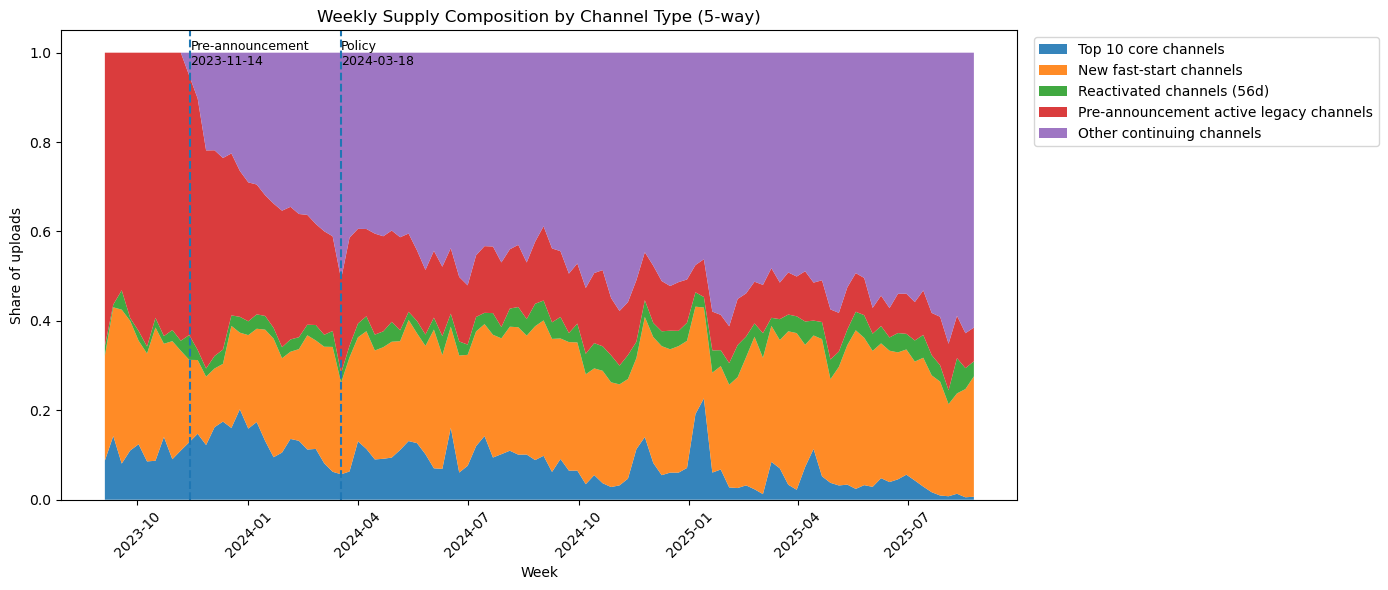

In [105]:
# Plot main figure: stacked area

fig, ax = plt.subplots(figsize=(14, 6))

x = main_weekly["week"].dt.tz_localize(None)

ax.stackplot(
    x,
    [main_weekly[col].values for col in group_order],
    labels=[
        "Top 10 core channels",
        "New fast-start channels",
        f"Reactivated channels ({REACTIVATION_THRESHOLD_SUPPLY}d)",
        "Pre-announcement active legacy channels",
        "Other continuing channels"
    ],
    alpha=0.9
)

add_policy_lines_supply_comp(ax)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))

format_axis_supply_comp(
    ax,
    title="Weekly Supply Composition by Channel Type (5-way)",
    xlabel="Week",
    ylabel="Share of uploads"
)

plt.show()

In [107]:
# ---------------------------------------------------------
# Supplementary 1. Monthly 100% stacked bar version
# ---------------------------------------------------------
# Same 5-way grouping, but monthly aggregation is easier to read.

supp1_video = supply_ai_window.copy()

# Make sure published_at is UTC-aware
supp1_video["published_at"] = pd.to_datetime(supp1_video["published_at"], utc=True, errors="coerce")

# Build a UTC-aware week key that matches supply_cw["week"]
supp1_video["week"] = (
    supp1_video["published_at"]
    .dt.to_period("W-SUN")
    .dt.start_time
)
supp1_video["week"] = pd.to_datetime(supp1_video["week"], utc=True)

# Month key for monthly aggregation
supp1_video["month"] = (
    supp1_video["published_at"]
    .dt.to_period("M")
    .dt.start_time
)
supp1_video["month"] = pd.to_datetime(supp1_video["month"], utc=True)

# Attach channel-week group assignment back to video-level uploads
supp1_video = supp1_video.merge(
    supply_cw[["channel_id", "week", "channel_type_group"]],
    on=["channel_id", "week"],
    how="left"
)

supp1_video["channel_type_group"] = supp1_video["channel_type_group"].fillna("other_continuing")

# Monthly uploads by group
supp1_monthly_long = (
    supp1_video
    .groupby(["month", "channel_type_group"], as_index=False)
    .agg(uploads=("video_id", "count"))
)

# Monthly total uploads
supp1_monthly_total = (
    supp1_video
    .groupby("month", as_index=False)
    .agg(total_uploads=("video_id", "count"))
)

supp1_monthly_long = supp1_monthly_long.merge(supp1_monthly_total, on="month", how="left")
supp1_monthly_long["share"] = (
    supp1_monthly_long["uploads"] /
    supp1_monthly_long["total_uploads"].replace(0, np.nan)
)

# Wide table for plotting
supp1_monthly = (
    supp1_monthly_long
    .pivot(index="month", columns="channel_type_group", values="share")
    .fillna(0)
    .sort_index()
)

for col in group_order:
    if col not in supp1_monthly.columns:
        supp1_monthly[col] = 0

supp1_monthly = supp1_monthly[group_order]

print("supp1_video shape:", supp1_video.shape)
print("supp1_monthly_long shape:", supp1_monthly_long.shape)
print("supp1_monthly shape:", supp1_monthly.shape)

display(supp1_monthly.head())
display(supp1_monthly.tail())

supp1_video shape: (81670, 21)
supp1_monthly_long shape: (118, 5)
supp1_monthly shape: (24, 5)


/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/1455348547.py:14: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("W-SUN")
/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/1455348547.py:22: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


channel_type_group,top10_core,new_fast_start,reactivated,pre_announcement_active_legacy,other_continuing
month,,,,,
2023-09-01 00:00:00+00:00,0.095699,0.280645,0.019355,0.604301,0.000000
2023-10-01 00:00:00+00:00,0.109565,0.246966,0.019272,0.624197,0.000000
2023-11-01 00:00:00+00:00,0.116716,0.202872,0.030560,0.586156,0.063697
2023-12-01 00:00:00+00:00,0.173154,0.161745,0.028523,0.402013,0.234564
2024-01-01 00:00:00+00:00,0.134367,0.234173,0.028424,0.287145,0.315891


channel_type_group,top10_core,new_fast_start,reactivated,pre_announcement_active_legacy,other_continuing
month,,,,,
2025-04-01 00:00:00+00:00,0.064818,0.286403,0.040699,0.095568,0.512511
2025-05-01 00:00:00+00:00,0.031579,0.303421,0.040263,0.093684,0.531053
2025-06-01 00:00:00+00:00,0.042597,0.296364,0.038961,0.070130,0.551948
2025-07-01 00:00:00+00:00,0.032666,0.270021,0.044257,0.095890,0.557165
2025-08-01 00:00:00+00:00,0.007977,0.238806,0.044776,0.087494,0.620947


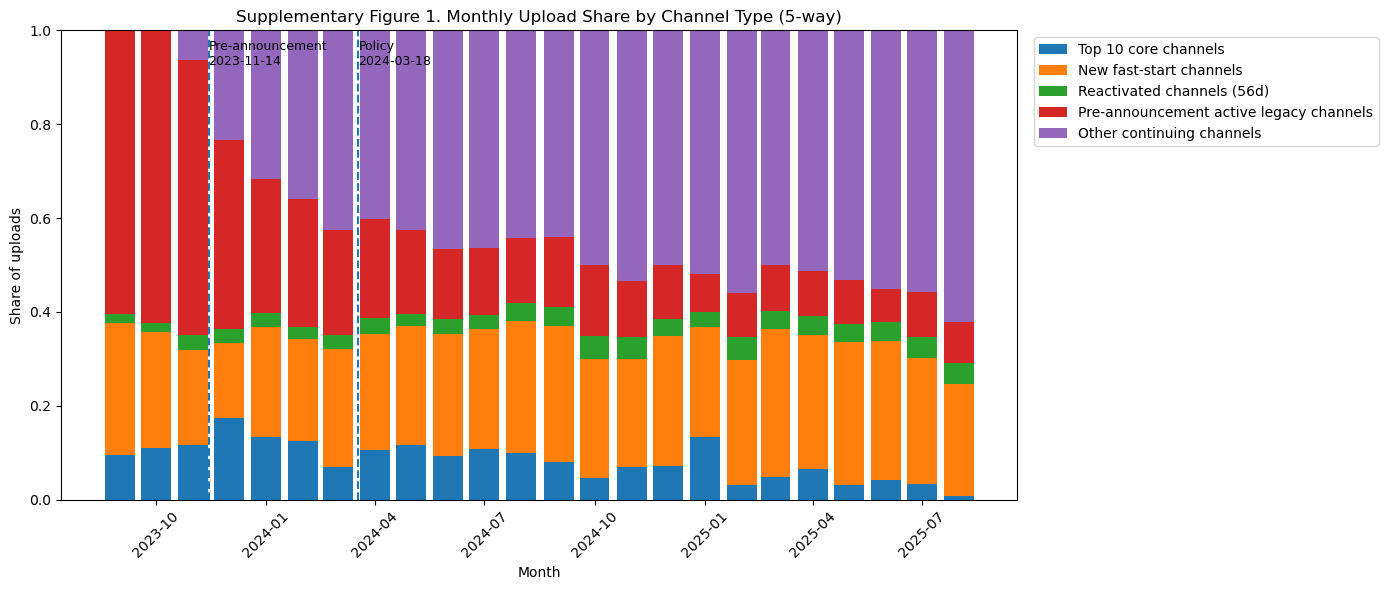

In [108]:
# Plot supplementary 1: monthly 100% stacked bar

fig, ax = plt.subplots(figsize=(14, 6))

bottom = np.zeros(len(supp1_monthly))
x = supp1_monthly.index.tz_localize(None)

label_map = {
    "top10_core": "Top 10 core channels",
    "new_fast_start": "New fast-start channels",
    "reactivated": f"Reactivated channels ({REACTIVATION_THRESHOLD_SUPPLY}d)",
    "pre_announcement_active_legacy": "Pre-announcement active legacy channels",
    "other_continuing": "Other continuing channels"
}

for col in group_order:
    ax.bar(
        x,
        supp1_monthly[col].values,
        bottom=bottom,
        width=25,
        label=label_map[col]
    )
    bottom = bottom + supp1_monthly[col].values

add_policy_lines_supply_comp(ax)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))

format_axis_supply_comp(
    ax,
    title="Supplementary Figure 1. Monthly Upload Share by Channel Type (5-way)",
    xlabel="Month",
    ylabel="Share of uploads"
)

plt.show()

#### Supplementary Diagnostics. Profiling `other_continuing` Channels

In [109]:
# ---------------------------------------------------------
# Step 1. Extract only the other_continuing group
# ---------------------------------------------------------
# We profile the residual purple group separately before deciding
# whether it should be split into additional interpretable subgroups.

if "supply_cw" not in globals():
    raise RuntimeError("Please run the 5-way supply composition section first. 'supply_cw' is missing.")

other_cont_cw = supply_cw[supply_cw["channel_type_group"] == "other_continuing"].copy()

other_cont_channel_ids = set(other_cont_cw["channel_id"].astype(str).unique())

print("Number of channel-weeks in other_continuing:", len(other_cont_cw))
print("Number of unique channels in other_continuing:", len(other_cont_channel_ids))

display(other_cont_cw.head())

Number of channel-weeks in other_continuing: 14906
Number of unique channels in other_continuing: 2118


,channel_id,week,uploads,first_upload_in_week,subscriber_count,first_ai_week,is_new_entrant_week,gap_days_first_upload,is_reactivated_week,is_new_fast_start,channel_type_group
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 00:00:00+00:00,2,2025-05-19 15:00:44+00:00,29.0,2025-05-19 00:00:00+00:00,1,3.000475,0,0,other_continuing
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-26 00:00:00+00:00,1,2025-05-27 16:15:08+00:00,29.0,2025-05-19 00:00:00+00:00,0,5.051192,0,0,other_continuing
31,UC-6gFOmgVu8OZtONway4a7w,2024-04-01 00:00:00+00:00,2,2024-04-02 13:45:27+00:00,4390.0,2024-04-01 00:00:00+00:00,1,2.883229,0,0,other_continuing
32,UC-6gFOmgVu8OZtONway4a7w,2024-05-06 00:00:00+00:00,1,2024-05-12 10:32:18+00:00,4390.0,2024-04-01 00:00:00+00:00,0,36.982639,0,0,other_continuing
62,UC-8MCMa1NH57TGFXm0BAkMg,2025-03-31 00:00:00+00:00,1,2025-04-01 17:59:01+00:00,1520.0,2023-08-21 00:00:00+00:00,0,48.884687,0,0,other_continuing


In [110]:
# ---------------------------------------------------------
# Step 2. Build a channel-level profile table for other_continuing
# ---------------------------------------------------------
# This table summarizes who these channels are:
# - how much they upload
# - when they first appear
# - whether they were ever reactivated
# - whether they belong to pre-announcement legacy
# - subscriber size

# First AI upload date over full history
other_first_ai = (
    ai_all[ai_all["channel_id"].astype(str).isin(other_cont_channel_ids)]
    .groupby("channel_id", as_index=False)
    .agg(
        first_ai_upload_at=("published_at", "min"),
        last_ai_upload_at=("published_at", "max"),
        total_ai_uploads_full_history=("video_id", "count")
    )
)

# Window-only summary
other_window_summary = (
    supply_ai_window[supply_ai_window["channel_id"].astype(str).isin(other_cont_channel_ids)]
    .groupby("channel_id", as_index=False)
    .agg(
        total_uploads_window=("video_id", "count"),
        first_upload_window=("published_at", "min"),
        last_upload_window=("published_at", "max"),
        active_weeks_window=("week", "nunique"),
        subscriber_count=("subscriber_count", "first")
    )
)

# Reactivation summary at channel level
other_reactivation = (
    other_cont_cw
    .groupby("channel_id", as_index=False)
    .agg(
        ever_reactivated_56d=("is_reactivated_week", "max"),
        reactivated_weeks_56d=("is_reactivated_week", "sum"),
        total_channel_weeks=("week", "nunique"),
        total_uploads_channel_week_panel=("uploads", "sum")
    )
)

# Legacy indicator
other_legacy = pd.DataFrame({
    "channel_id": list(other_cont_channel_ids)
})
other_legacy["is_pre_announcement_active_legacy"] = (
    other_legacy["channel_id"].astype(str).isin(pre_announcement_active_legacy_ids)
).astype(int)

# Top10 indicator just as a sanity check (should be zero by construction)
other_legacy["is_top10_core"] = (
    other_legacy["channel_id"].astype(str).isin(top10_core_ids)
).astype(int)

other_profile = (
    other_window_summary
    .merge(other_first_ai, on="channel_id", how="left")
    .merge(other_reactivation, on="channel_id", how="left")
    .merge(other_legacy, on="channel_id", how="left")
)

# Derived features
other_profile["uploads_per_active_week"] = (
    other_profile["total_uploads_window"] / other_profile["active_weeks_window"].replace(0, np.nan)
)

other_profile["first_upload_year_month"] = (
    pd.to_datetime(other_profile["first_upload_window"], utc=True, errors="coerce")
    .dt.strftime("%Y-%m")
)

other_profile["first_ai_year_month"] = (
    pd.to_datetime(other_profile["first_ai_upload_at"], utc=True, errors="coerce")
    .dt.strftime("%Y-%m")
)

print("other_profile shape:", other_profile.shape)
display(other_profile.head())

other_profile shape: (2118, 18)


,channel_id,total_uploads_window,first_upload_window,last_upload_window,active_weeks_window,subscriber_count,first_ai_upload_at,last_ai_upload_at,total_ai_uploads_full_history,ever_reactivated_56d,reactivated_weeks_56d,total_channel_weeks,total_uploads_channel_week_panel,is_pre_announcement_active_legacy,is_top10_core,uploads_per_active_week,first_upload_year_month,first_ai_year_month
0,UC--Fkf3RGD_0MdJS2H_7tcQ,3,2025-05-19 15:00:44+00:00,2025-05-27 16:15:08+00:00,2,29.0,2025-05-19 15:00:44+00:00,2025-05-27 16:15:08+00:00,3,0,0,2,3,0,0,1.500000,2025-05,2025-05
1,UC-6gFOmgVu8OZtONway4a7w,4,2024-04-02 13:45:27+00:00,2025-02-25 16:15:03+00:00,3,4390.0,2024-04-02 13:45:27+00:00,2025-02-25 16:15:03+00:00,4,0,0,2,3,0,0,1.333333,2024-04,2024-04
2,UC-8MCMa1NH57TGFXm0BAkMg,23,2024-10-19 15:49:04+00:00,2025-08-28 17:54:31+00:00,13,1520.0,2023-08-25 18:18:46+00:00,2026-03-21 15:18:49+00:00,32,0,0,11,20,0,0,1.769231,2024-10,2023-08
3,UC-ApDbE0Ub-Oyt9_rx8jlUw,1,2025-08-21 13:38:01+00:00,2025-08-21 13:38:01+00:00,1,6.0,2025-08-21 13:38:01+00:00,2025-08-21 13:38:01+00:00,1,0,0,1,1,0,0,1.000000,2025-08,2025-08
4,UC-DOuynbVBODGLjXZxIi96w,1,2024-06-02 19:08:38+00:00,2024-06-02 19:08:38+00:00,1,476.0,2024-06-02 19:08:38+00:00,2024-06-02 19:08:38+00:00,1,0,0,1,1,0,0,1.000000,2024-06,2024-06


In [111]:
# ---------------------------------------------------------
# Step 3. High-level summary table
# ---------------------------------------------------------
# This gives a quick statistical profile of the purple group.

other_summary = pd.DataFrame({
    "metric": [
        "unique_channels",
        "median_subscribers",
        "mean_subscribers",
        "median_total_uploads_window",
        "mean_total_uploads_window",
        "median_active_weeks_window",
        "mean_active_weeks_window",
        "median_uploads_per_active_week",
        "mean_uploads_per_active_week",
        "share_ever_reactivated_56d",
        "share_pre_announcement_active_legacy"
    ],
    "value": [
        other_profile["channel_id"].nunique(),
        other_profile["subscriber_count"].median(),
        other_profile["subscriber_count"].mean(),
        other_profile["total_uploads_window"].median(),
        other_profile["total_uploads_window"].mean(),
        other_profile["active_weeks_window"].median(),
        other_profile["active_weeks_window"].mean(),
        other_profile["uploads_per_active_week"].median(),
        other_profile["uploads_per_active_week"].mean(),
        other_profile["ever_reactivated_56d"].mean(),
        other_profile["is_pre_announcement_active_legacy"].mean()
    ]
})

display(other_summary)

,metric,value
0,unique_channels,2118.000000
1,median_subscribers,742.500000
2,mean_subscribers,66902.307838
3,median_total_uploads_window,6.000000
4,mean_total_uploads_window,17.363551
5,median_active_weeks_window,4.000000
6,mean_active_weeks_window,7.647309
7,median_uploads_per_active_week,1.323462
8,mean_uploads_per_active_week,1.841861
9,share_ever_reactivated_56d,0.000000


In [112]:
# ---------------------------------------------------------
# Step 4. Distribution tables that help decide subgroup design
# ---------------------------------------------------------

# Subscriber-size bins
other_profile["subscriber_bin"] = pd.cut(
    other_profile["subscriber_count"],
    bins=[-np.inf, 100, 500, 5000, np.inf],
    labels=["<100", "100-499", "500-4,999", "5,000+"]
)

subscriber_bin_table = (
    other_profile["subscriber_bin"]
    .value_counts(dropna=False)
    .rename_axis("subscriber_bin")
    .reset_index(name="channels")
)

# Upload-intensity bins (window total uploads)
other_profile["window_upload_bin"] = pd.cut(
    other_profile["total_uploads_window"],
    bins=[0, 5, 20, 100, np.inf],
    labels=["1-5", "6-20", "21-100", "100+"],
    include_lowest=True
)

upload_bin_table = (
    other_profile["window_upload_bin"]
    .value_counts(dropna=False)
    .rename_axis("window_upload_bin")
    .reset_index(name="channels")
)

# Entry timing bins
entry_timing_table = (
    other_profile["first_ai_year_month"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("first_ai_year_month")
    .reset_index(name="channels")
)

# Reactivation frequency
reactivation_table = (
    other_profile["ever_reactivated_56d"]
    .value_counts(dropna=False)
    .rename_axis("ever_reactivated_56d")
    .reset_index(name="channels")
)

display(subscriber_bin_table)
display(upload_bin_table)
display(reactivation_table)
display(entry_timing_table.head(20))

,subscriber_bin,channels
0,"500-4,999",744
1,100-499,497
2,"5,000+",449
3,<100,428


,window_upload_bin,channels
0,1-5,1049
1,6-20,606
2,21-100,402
3,100+,61


,ever_reactivated_56d,channels
0,0,2118


,first_ai_year_month,channels
0,2014-01,1
1,2016-09,1
2,2017-04,1
3,2017-09,1
4,2019-05,1
5,2019-08,1
6,2019-09,1
7,2019-11,1
8,2020-02,1
9,2020-04,2


In [113]:
# ---------------------------------------------------------
# Step 5. Weekly contribution of other_continuing itself
# ---------------------------------------------------------
# This shows whether the purple group is large because:
# - many channels are active, or
# - a small number of channels upload a lot.

other_weekly_profile = (
    other_cont_cw
    .groupby("week", as_index=False)
    .agg(
        channels=("channel_id", "nunique"),
        uploads=("uploads", "sum")
    )
)

other_weekly_profile["uploads_per_active_channel"] = (
    other_weekly_profile["uploads"] / other_weekly_profile["channels"].replace(0, np.nan)
)

display(other_weekly_profile.head())
display(other_weekly_profile.tail())

,week,channels,uploads,uploads_per_active_channel
0,2023-11-13 00:00:00+00:00,21,35,1.666667
1,2023-11-20 00:00:00+00:00,35,59,1.685714
2,2023-11-27 00:00:00+00:00,56,143,2.553571
3,2023-12-04 00:00:00+00:00,56,148,2.642857
4,2023-12-11 00:00:00+00:00,65,155,2.384615


,week,channels,uploads,uploads_per_active_channel
89,2025-07-28 00:00:00+00:00,200,501,2.505000
90,2025-08-04 00:00:00+00:00,208,588,2.826923
91,2025-08-11 00:00:00+00:00,192,485,2.526042
92,2025-08-18 00:00:00+00:00,205,578,2.819512
93,2025-08-25 00:00:00+00:00,194,546,2.814433


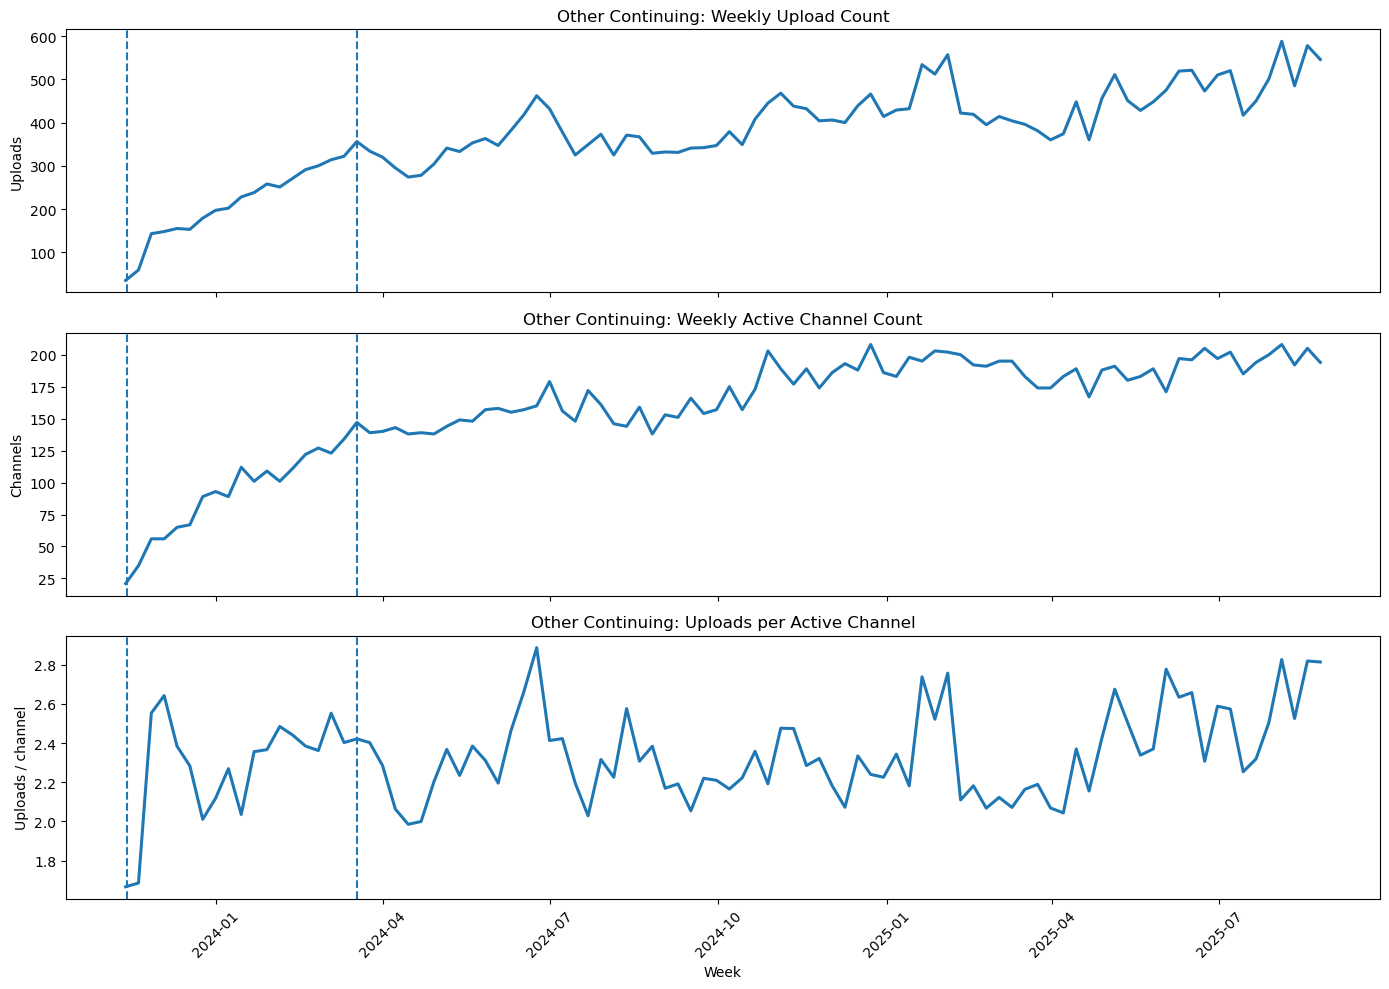

In [114]:
# Plot weekly diagnostics for other_continuing

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(
    other_weekly_profile["week"].dt.tz_localize(None),
    other_weekly_profile["uploads"],
    linewidth=2.2
)
axes[0].set_title("Other Continuing: Weekly Upload Count")
axes[0].set_ylabel("Uploads")

axes[1].plot(
    other_weekly_profile["week"].dt.tz_localize(None),
    other_weekly_profile["channels"],
    linewidth=2.2
)
axes[1].set_title("Other Continuing: Weekly Active Channel Count")
axes[1].set_ylabel("Channels")

axes[2].plot(
    other_weekly_profile["week"].dt.tz_localize(None),
    other_weekly_profile["uploads_per_active_channel"],
    linewidth=2.2
)
axes[2].set_title("Other Continuing: Uploads per Active Channel")
axes[2].set_ylabel("Uploads / channel")
axes[2].set_xlabel("Week")

for ax in axes:
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [115]:
# ---------------------------------------------------------
# Step 6. Which channels dominate the purple group?
# ---------------------------------------------------------
# This is often the most useful diagnostic.
# If the top 20 channels account for most of the purple group's uploads,
# then the group is not really a broad residual pool.

other_channel_contrib = (
    other_cont_cw
    .groupby("channel_id", as_index=False)
    .agg(
        uploads=("uploads", "sum"),
        active_weeks=("week", "nunique")
    )
    .merge(
        other_profile[[
            "channel_id",
            "subscriber_count",
            "uploads_per_active_week",
            "ever_reactivated_56d",
            "is_pre_announcement_active_legacy",
            "first_ai_year_month"
        ]],
        on="channel_id",
        how="left"
    )
    .sort_values("uploads", ascending=False)
)

other_channel_contrib["upload_share_within_other_continuing"] = (
    other_channel_contrib["uploads"] / other_channel_contrib["uploads"].sum()
)

other_channel_contrib["cum_share_within_other_continuing"] = (
    other_channel_contrib["upload_share_within_other_continuing"].cumsum()
)

display(other_channel_contrib.head(30))

,channel_id,uploads,active_weeks,subscriber_count,uploads_per_active_week,ever_reactivated_56d,is_pre_announcement_active_legacy,first_ai_year_month,upload_share_within_other_continuing,cum_share_within_other_continuing
500,UCEKsAz14DQMjXfy1pNb2otw,424,69,34600.0,6.085714,0,0,2023-12,0.012112,0.012112
17,UC-SK3AwA225LLXhv3AlZYKg,417,26,29800.0,16.038462,0,0,2025-03,0.011912,0.024023
1061,UCVZEM7UkETmxetacd9B9zPA,387,65,2660.0,5.953846,0,0,2024-06,0.011055,0.035078
633,UCI9fSHujG-Btg-B4iCtFSNQ,345,73,9070.0,4.726027,0,0,2024-03,0.009855,0.044933
557,UCFaJ-ZVtM8RlC5r9P3mGp1g,335,61,13500.0,5.491803,0,0,2024-07,0.009569,0.054502
1187,UCZ-zLA2Lva_e9ZVo91tghzA,299,21,395000.0,14.238095,0,0,2025-04,0.008541,0.063043
2016,UCwrFhcHlyUPJEduFoFGGcJg,283,31,32600.0,9.129032,0,0,2024-12,0.008084,0.071127
2092,UCz7dHs2HwFeFebIS5tzPW4A,276,70,3470.0,3.957746,0,0,2017-04,0.007884,0.079011
58,UC0Y5a3e5tWaYKZn8PzJwPMA,274,81,9590.0,3.382716,0,0,2024-02,0.007827,0.086837
1986,UCwGLOq_TLTEXVHgT6Ge1ZgQ,266,58,5110.0,4.525424,0,0,2024-01,0.007598,0.094436


In [116]:
# ---------------------------------------------------------
# Step 7. Candidate subgroup diagnostics
# ---------------------------------------------------------
# These summaries help decide whether 'other_continuing' should be split into:
# - mid-tier continuing
# - small continuing
# - post-policy established continuing
# or something else.

candidate_subgroup_summary = pd.DataFrame({
    "candidate_group": [
        "mid_tier_by_uploads_top20_within_other",
        "small_continuing_<100_subs",
        "small_continuing_<500_subs",
        "post_policy_established_continuing",
        "legacy_but_not_top10_or_reactivated"
    ],
    "channels": [
        other_channel_contrib.head(20)["channel_id"].nunique(),
        other_profile[other_profile["subscriber_count"] < 100]["channel_id"].nunique(),
        other_profile[other_profile["subscriber_count"] < 500]["channel_id"].nunique(),
        other_profile[
            pd.to_datetime(other_profile["first_ai_upload_at"], utc=True, errors="coerce") >= pd.Timestamp("2024-03-18", tz="UTC")
        ]["channel_id"].nunique(),
        other_profile[
            other_profile["is_pre_announcement_active_legacy"] == 1
        ]["channel_id"].nunique()
    ],
    "upload_share_within_other_continuing": [
        other_channel_contrib.head(20)["upload_share_within_other_continuing"].sum(),
        other_channel_contrib[
            other_channel_contrib["subscriber_count"] < 100
        ]["upload_share_within_other_continuing"].sum(),
        other_channel_contrib[
            other_channel_contrib["subscriber_count"] < 500
        ]["upload_share_within_other_continuing"].sum(),
        other_channel_contrib[
            pd.to_datetime(other_channel_contrib["first_ai_year_month"], errors="coerce").notna()
        ]["upload_share_within_other_continuing"].sum(),  # placeholder, refined below
        other_channel_contrib[
            other_channel_contrib["is_pre_announcement_active_legacy"] == 1
        ]["upload_share_within_other_continuing"].sum()
    ]
})

# refine post-policy established share using actual datetime
post_policy_established_ids = set(
    other_profile[
        pd.to_datetime(other_profile["first_ai_upload_at"], utc=True, errors="coerce") >= pd.Timestamp("2024-03-18", tz="UTC")
    ]["channel_id"]
)

candidate_subgroup_summary.loc[
    candidate_subgroup_summary["candidate_group"] == "post_policy_established_continuing",
    "upload_share_within_other_continuing"
] = other_channel_contrib[
    other_channel_contrib["channel_id"].isin(post_policy_established_ids)
]["upload_share_within_other_continuing"].sum()

display(candidate_subgroup_summary)

,candidate_group,channels,upload_share_within_other_continuing
0,mid_tier_by_uploads_top20_within_other,20,0.148052
1,small_continuing_<100_subs,425,0.095864
2,small_continuing_<500_subs,924,0.289620
3,post_policy_established_continuing,1481,0.679302
4,legacy_but_not_top10_or_reactivated,0,0.000000


#### Supply Composition by Channel Type (6-way)

In [117]:
# ---------------------------------------------------------
# 6-way supply composition: local helpers
# ---------------------------------------------------------

def first_full_monday_supply_comp_6way(start_ts):
    ts = pd.Timestamp(start_ts)
    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")
    ts = ts.normalize()
    days_to_next_monday = (7 - ts.weekday()) % 7
    return ts + pd.Timedelta(days=days_to_next_monday)


def complete_weekly_to_last_observed_supply_comp_6way(df, week_col, value_col, analysis_start):
    out = df.copy()
    out[week_col] = pd.to_datetime(out[week_col], utc=True, errors="coerce")
    out = out.dropna(subset=[week_col]).sort_values(week_col)

    start_week = first_full_monday_supply_comp_6way(analysis_start)

    observed = out[out[value_col] > 0].copy()
    if len(observed) == 0:
        return out.iloc[0:0].copy()

    last_week = observed[week_col].max()

    full_weeks = pd.date_range(start=start_week, end=last_week, freq="W-MON", tz="UTC")

    out = (
        out.set_index(week_col)
           .reindex(full_weeks)
           .fillna(0)
           .rename_axis(week_col)
           .reset_index()
    )
    return out


def month_floor_supply_comp_6way(series):
    s = pd.to_datetime(series, utc=True, errors="coerce")
    return pd.Series(
        [pd.NaT if pd.isna(x) else pd.Timestamp(x.year, x.month, 1, tz="UTC") for x in s],
        index=s.index
    )


def add_policy_lines_supply_comp_6way(ax):
    ax.axvline(PRE_ANNOUNCEMENT_DATE, linestyle="--", linewidth=1.5)
    ax.axvline(POLICY_DATE, linestyle="--", linewidth=1.5)

    ymax = ax.get_ylim()[1]
    ax.text(
        PRE_ANNOUNCEMENT_DATE, ymax * 0.98,
        "Pre-announcement\n2023-11-14",
        ha="left", va="top", fontsize=9
    )
    ax.text(
        POLICY_DATE, ymax * 0.98,
        "Policy\n2024-03-18",
        ha="left", va="top", fontsize=9
    )


def format_axis_supply_comp_6way(ax, title, xlabel, ylabel):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.xticks(rotation=45)
    plt.tight_layout()

In [118]:
# ---------------------------------------------------------
# Step 1. Build the core channel-week input
# ---------------------------------------------------------
# Group definitions:
# 1. top50_core
# 2. new_account_channels
# 3. pre_announcement_active_cohort
# 4. old_account_new_ai_entrants
# 5. reactivated_old_accounts
# 6. other_continuing

if "ai_all" not in globals() or "ai_window" not in globals() or "channels_in_sample" not in globals():
    raise RuntimeError("Please run Section 2 first. Required objects are missing.")

_supply_ai_all = ai_all.copy()
_supply_ai_window = ai_window.copy()
_supply_channels = channels_in_sample.copy()

for df_ in [_supply_ai_all, _supply_ai_window, _supply_channels]:
    df_["channel_id"] = df_["channel_id"].astype(str).str.strip()

# Policy date
POLICY_TS = pd.Timestamp("2024-03-18", tz="UTC")

# 1) Top 50 channels over the analysis window
top50_core_ids = set(
    _supply_ai_window
    .groupby("channel_id", as_index=False)
    .agg(total_uploads=("video_id", "count"))
    .sort_values("total_uploads", ascending=False)
    .head(50)["channel_id"]
    .astype(str)
    .tolist()
)

print("Top 50 core channels:", len(top50_core_ids))

# 2) Pre-announcement active cohort
pre_active_start = pd.Timestamp("2023-09-01", tz="UTC")
pre_active_end   = pd.Timestamp("2023-11-13 23:59:59", tz="UTC")

pre_announcement_active_cohort_ids = set(
    _supply_ai_all[
        (_supply_ai_all["published_at"] >= pre_active_start) &
        (_supply_ai_all["published_at"] <= pre_active_end)
    ]["channel_id"].dropna().astype(str).unique()
)

print("Pre-announcement active cohort channels:", len(pre_announcement_active_cohort_ids))

# 3) Channel-level first AI upload
supply6_first_ai = (
    _supply_ai_all
    .groupby("channel_id", as_index=False)
    .agg(first_ai_upload_at=("published_at", "min"))
)

supply6_first_ai["first_ai_week"] = (
    supply6_first_ai["first_ai_upload_at"]
    .dt.to_period("W-SUN")
    .dt.start_time
)
supply6_first_ai["first_ai_week"] = pd.to_datetime(supply6_first_ai["first_ai_week"], utc=True)

# 4) Channel-level account creation info
supply6_channel_entry = (
    _supply_channels[["channel_id", "channel_created_at"]]
    .drop_duplicates()
    .merge(supply6_first_ai[["channel_id", "first_ai_upload_at"]], on="channel_id", how="left")
)

supply6_channel_entry["is_new_account_post_policy"] = (
    (supply6_channel_entry["channel_created_at"] >= POLICY_TS)
    .fillna(False)
    .astype(int)
)

supply6_channel_entry["is_old_account"] = (
    (supply6_channel_entry["channel_created_at"] < POLICY_TS)
    .fillna(False)
    .astype(int)
)

supply6_channel_entry["is_old_account_new_ai_entrant"] = (
    (supply6_channel_entry["channel_created_at"] < POLICY_TS) &
    (supply6_channel_entry["first_ai_upload_at"] >= POLICY_TS)
).fillna(False).astype(int)

# 5) Full-history gaps for reactivation
_supply_ai_all = _supply_ai_all.sort_values(["channel_id", "published_at", "video_id"]).copy()
_supply_ai_all["prev_ai_upload_at"] = _supply_ai_all.groupby("channel_id")["published_at"].shift(1)
_supply_ai_all["gap_days"] = (
    (_supply_ai_all["published_at"] - _supply_ai_all["prev_ai_upload_at"])
    .dt.total_seconds() / (60 * 60 * 24)
)

supply6_ai_window = _supply_ai_window.merge(
    _supply_ai_all[["video_id", "gap_days"]],
    on="video_id",
    how="left"
)

# 6) Channel-week panel
supply6_cw = (
    supply6_ai_window
    .groupby(["channel_id", "week"], as_index=False)
    .agg(
        uploads=("video_id", "count"),
        first_upload_in_week=("published_at", "min"),
        subscriber_count=("subscriber_count", "first")
    )
)

supply6_cw = supply6_cw.merge(
    supply6_first_ai[["channel_id", "first_ai_week", "first_ai_upload_at"]],
    on="channel_id",
    how="left"
)

# first upload gap in each week
supply6_first_uploads_in_week = (
    supply6_ai_window
    .sort_values(["channel_id", "week", "published_at", "video_id"])
    .groupby(["channel_id", "week"], as_index=False)
    .first()[["channel_id", "week", "gap_days"]]
    .rename(columns={"gap_days": "gap_days_first_upload"})
)

supply6_cw = supply6_cw.merge(
    supply6_first_uploads_in_week,
    on=["channel_id", "week"],
    how="left"
)

REACTIVATION_THRESHOLD_SUPPLY6 = 56

supply6_cw["is_reactivated_week"] = (
    (supply6_cw["gap_days_first_upload"] >= REACTIVATION_THRESHOLD_SUPPLY6)
    .fillna(False)
    .astype(int)
)

# Attach channel-level account flags
supply6_cw = supply6_cw.merge(
    supply6_channel_entry[[
        "channel_id",
        "channel_created_at",
        "is_new_account_post_policy",
        "is_old_account",
        "is_old_account_new_ai_entrant"
    ]],
    on="channel_id",
    how="left"
)

print("supply6_channel_entry shape:", supply6_channel_entry.shape)
print("supply6_ai_window shape:", supply6_ai_window.shape)
print("supply6_cw shape:", supply6_cw.shape)

display(supply6_cw.head())

Top 50 core channels: 50
Pre-announcement active cohort channels: 796


/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/1428852373.py:60: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("W-SUN")


supply6_channel_entry shape: (3993, 6)
supply6_ai_window shape: (81670, 19)
supply6_cw shape: (32095, 13)


,channel_id,week,uploads,first_upload_in_week,subscriber_count,first_ai_week,first_ai_upload_at,gap_days_first_upload,is_reactivated_week,channel_created_at,is_new_account_post_policy,is_old_account,is_old_account_new_ai_entrant
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 00:00:00+00:00,2,2025-05-19 15:00:44+00:00,29.0,2025-05-19 00:00:00+00:00,2025-05-19 15:00:44+00:00,3.000475,0,2024-04-14 02:53:02.923826+00:00,1,0,0
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-26 00:00:00+00:00,1,2025-05-27 16:15:08+00:00,29.0,2025-05-19 00:00:00+00:00,2025-05-19 15:00:44+00:00,5.051192,0,2024-04-14 02:53:02.923826+00:00,1,0,0
2,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-04 00:00:00+00:00,1,2023-09-09 05:00:09+00:00,268.0,2023-08-07 00:00:00+00:00,2023-08-07 09:09:11+00:00,18.791181,0,2020-12-11 21:58:46.058826+00:00,0,1,0
3,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-18 00:00:00+00:00,1,2023-09-24 17:00:29+00:00,268.0,2023-08-07 00:00:00+00:00,2023-08-07 09:09:11+00:00,15.500231,0,2020-12-11 21:58:46.058826+00:00,0,1,0
4,UC-26K0B-XV5ieqZsQ3QPrcA,2024-02-05 00:00:00+00:00,1,2024-02-10 09:58:15+00:00,268.0,2023-08-07 00:00:00+00:00,2023-08-07 09:09:11+00:00,138.706782,1,2020-12-11 21:58:46.058826+00:00,0,1,0


In [119]:
# ---------------------------------------------------------
# Step 2. Assign one mutually exclusive group to each channel-week
# ---------------------------------------------------------
# Priority order:
# 1. top50_core
# 2. new_account_channels
# 3. pre_announcement_active_cohort
# 4. old_account_new_ai_entrants
# 5. reactivated_old_accounts
# 6. other_continuing

def assign_supply_group_6way(row):
    cid = str(row["channel_id"])

    if cid in top50_core_ids:
        return "top50_core"
    elif row["is_new_account_post_policy"] == 1:
        return "new_account_channels"
    elif cid in pre_announcement_active_cohort_ids:
        return "pre_announcement_active_cohort"
    elif row["is_old_account_new_ai_entrant"] == 1:
        return "old_account_new_ai_entrants"
    elif (row["is_old_account"] == 1) and (row["is_reactivated_week"] == 1):
        return "reactivated_old_accounts"
    else:
        return "other_continuing"

supply6_cw["channel_type_group_6way"] = supply6_cw.apply(assign_supply_group_6way, axis=1)

print(supply6_cw["channel_type_group_6way"].value_counts(dropna=False))
display(
    supply6_cw[[
        "channel_id", "week", "uploads", "channel_created_at",
        "first_ai_upload_at", "is_reactivated_week", "channel_type_group_6way"
    ]].head(20)
)

channel_type_group_6way
other_continuing                  9435
pre_announcement_active_cohort    8837
new_account_channels              6178
old_account_new_ai_entrants       4185
top50_core                        2961
reactivated_old_accounts           499
Name: count, dtype: int64


,channel_id,week,uploads,channel_created_at,first_ai_upload_at,is_reactivated_week,channel_type_group_6way
0,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-19 00:00:00+00:00,2,2024-04-14 02:53:02.923826+00:00,2025-05-19 15:00:44+00:00,0,new_account_channels
1,UC--Fkf3RGD_0MdJS2H_7tcQ,2025-05-26 00:00:00+00:00,1,2024-04-14 02:53:02.923826+00:00,2025-05-19 15:00:44+00:00,0,new_account_channels
2,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-04 00:00:00+00:00,1,2020-12-11 21:58:46.058826+00:00,2023-08-07 09:09:11+00:00,0,pre_announcement_active_cohort
3,UC-26K0B-XV5ieqZsQ3QPrcA,2023-09-18 00:00:00+00:00,1,2020-12-11 21:58:46.058826+00:00,2023-08-07 09:09:11+00:00,0,pre_announcement_active_cohort
4,UC-26K0B-XV5ieqZsQ3QPrcA,2024-02-05 00:00:00+00:00,1,2020-12-11 21:58:46.058826+00:00,2023-08-07 09:09:11+00:00,1,pre_announcement_active_cohort
5,UC-26K0B-XV5ieqZsQ3QPrcA,2024-03-04 00:00:00+00:00,1,2020-12-11 21:58:46.058826+00:00,2023-08-07 09:09:11+00:00,0,pre_announcement_active_cohort
6,UC-26K0B-XV5ieqZsQ3QPrcA,2024-10-21 00:00:00+00:00,2,2020-12-11 21:58:46.058826+00:00,2023-08-07 09:09:11+00:00,1,pre_announcement_active_cohort
7,UC-4mQA-mv5rbe8W-mgbl7vQ,2024-11-18 00:00:00+00:00,2,2024-11-18 16:48:09.921572+00:00,2024-11-18 21:03:12+00:00,0,new_account_channels
8,UC-4mQA-mv5rbe8W-mgbl7vQ,2024-11-25 00:00:00+00:00,1,2024-11-18 16:48:09.921572+00:00,2024-11-18 21:03:12+00:00,0,new_account_channels
9,UC-58AFr18tKsOo6dlp9GlXA,2023-08-28 00:00:00+00:00,1,2020-06-29 17:42:16.474451+00:00,2023-08-03 12:04:50+00:00,0,pre_announcement_active_cohort


In [120]:
# ---------------------------------------------------------
# Main Figure. Weekly Supply Composition by Channel Type (6-way)
# ---------------------------------------------------------

main6_weekly_raw = (
    supply6_cw
    .groupby(["week", "channel_type_group_6way"], as_index=False)
    .agg(uploads=("uploads", "sum"))
)

main6_weekly_total = (
    supply6_cw
    .groupby("week", as_index=False)
    .agg(total_uploads=("uploads", "sum"))
)

main6_weekly_raw = main6_weekly_raw.merge(main6_weekly_total, on="week", how="left")
main6_weekly_raw["share"] = main6_weekly_raw["uploads"] / main6_weekly_raw["total_uploads"].replace(0, np.nan)

main6_weekly = (
    main6_weekly_raw
    .pivot(index="week", columns="channel_type_group_6way", values="share")
    .fillna(0)
    .sort_index()
)

group_order_6way = [
    "top50_core",
    "new_account_channels",
    "pre_announcement_active_cohort",
    "old_account_new_ai_entrants",
    "reactivated_old_accounts",
    "other_continuing"
]

for col in group_order_6way:
    if col not in main6_weekly.columns:
        main6_weekly[col] = 0

main6_weekly = main6_weekly[group_order_6way].reset_index()

main6_anchor = (
    supply6_cw
    .groupby("week", as_index=False)
    .agg(total_uploads=("uploads", "sum"))
)

main6_weekly_complete = complete_weekly_to_last_observed_supply_comp_6way(
    df=main6_anchor,
    week_col="week",
    value_col="total_uploads",
    analysis_start=ANALYSIS_START_RAW
)[["week"]]

main6_weekly = main6_weekly_complete.merge(main6_weekly, on="week", how="left")
for col in group_order_6way:
    main6_weekly[col] = main6_weekly[col].fillna(0)

print("main6_weekly shape:", main6_weekly.shape)
display(main6_weekly.head())
display(main6_weekly.tail())

main6_weekly shape: (104, 7)


,week,top50_core,new_account_channels,pre_announcement_active_cohort,old_account_new_ai_entrants,reactivated_old_accounts,other_continuing
0,2023-09-04 00:00:00+00:00,0.167178,0.0,0.832822,0.0,0.0,0.0
1,2023-09-11 00:00:00+00:00,0.316119,0.0,0.683881,0.0,0.0,0.0
2,2023-09-18 00:00:00+00:00,0.309880,0.0,0.690120,0.0,0.0,0.0
3,2023-09-25 00:00:00+00:00,0.306667,0.0,0.693333,0.0,0.0,0.0
4,2023-10-02 00:00:00+00:00,0.263423,0.0,0.736577,0.0,0.0,0.0


,week,top50_core,new_account_channels,pre_announcement_active_cohort,old_account_new_ai_entrants,reactivated_old_accounts,other_continuing
99,2025-07-28 00:00:00+00:00,0.180425,0.384434,0.069575,0.153302,0.005896,0.206368
100,2025-08-04 00:00:00+00:00,0.156146,0.377630,0.065338,0.176080,0.006645,0.218162
101,2025-08-11 00:00:00+00:00,0.194175,0.350728,0.048544,0.194175,0.002427,0.209951
102,2025-08-18 00:00:00+00:00,0.185668,0.369164,0.038002,0.179153,0.010858,0.217155
103,2025-08-25 00:00:00+00:00,0.161036,0.416667,0.059685,0.168919,0.003378,0.190315


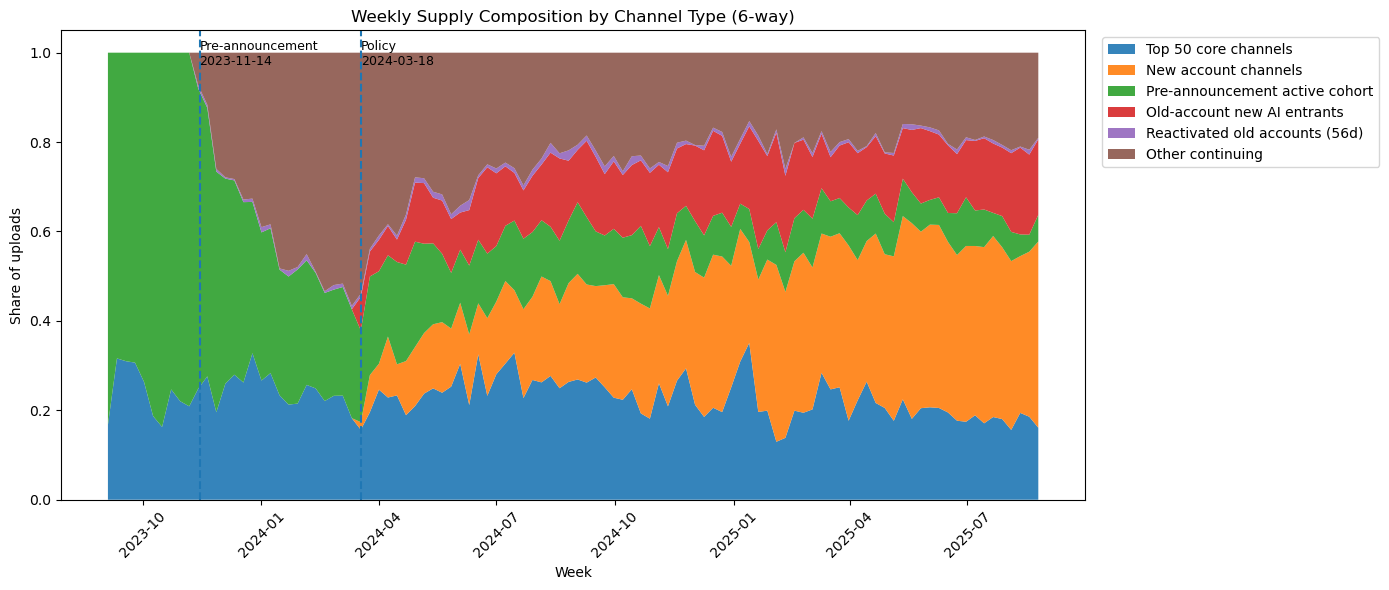

In [121]:
# Plot main figure: stacked area

fig, ax = plt.subplots(figsize=(14, 6))

x = main6_weekly["week"].dt.tz_localize(None)

ax.stackplot(
    x,
    [main6_weekly[col].values for col in group_order_6way],
    labels=[
        "Top 50 core channels",
        "New account channels",
        "Pre-announcement active cohort",
        "Old-account new AI entrants",
        f"Reactivated old accounts ({REACTIVATION_THRESHOLD_SUPPLY6}d)",
        "Other continuing"
    ],
    alpha=0.9
)

add_policy_lines_supply_comp_6way(ax)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))

format_axis_supply_comp_6way(
    ax,
    title="Weekly Supply Composition by Channel Type (6-way)",
    xlabel="Week",
    ylabel="Share of uploads"
)

plt.show()

In [122]:
# ---------------------------------------------------------
# Supplementary 1. Monthly 100% stacked bar version
# ---------------------------------------------------------

supp6_video = supply6_ai_window.copy()

supp6_video["published_at"] = pd.to_datetime(supp6_video["published_at"], utc=True, errors="coerce")

supp6_video["week"] = (
    supp6_video["published_at"]
    .dt.to_period("W-SUN")
    .dt.start_time
)
supp6_video["week"] = pd.to_datetime(supp6_video["week"], utc=True)

supp6_video["month"] = (
    supp6_video["published_at"]
    .dt.to_period("M")
    .dt.start_time
)
supp6_video["month"] = pd.to_datetime(supp6_video["month"], utc=True)

supp6_video = supp6_video.merge(
    supply6_cw[["channel_id", "week", "channel_type_group_6way"]],
    on=["channel_id", "week"],
    how="left"
)

supp6_video["channel_type_group_6way"] = supp6_video["channel_type_group_6way"].fillna("other_continuing")

supp6_monthly_long = (
    supp6_video
    .groupby(["month", "channel_type_group_6way"], as_index=False)
    .agg(uploads=("video_id", "count"))
)

supp6_monthly_total = (
    supp6_video
    .groupby("month", as_index=False)
    .agg(total_uploads=("video_id", "count"))
)

supp6_monthly_long = supp6_monthly_long.merge(supp6_monthly_total, on="month", how="left")
supp6_monthly_long["share"] = (
    supp6_monthly_long["uploads"] /
    supp6_monthly_long["total_uploads"].replace(0, np.nan)
)

supp6_monthly = (
    supp6_monthly_long
    .pivot(index="month", columns="channel_type_group_6way", values="share")
    .fillna(0)
    .sort_index()
)

for col in group_order_6way:
    if col not in supp6_monthly.columns:
        supp6_monthly[col] = 0

supp6_monthly = supp6_monthly[group_order_6way]

print("supp6_monthly shape:", supp6_monthly.shape)
display(supp6_monthly.head())
display(supp6_monthly.tail())

supp6_monthly shape: (24, 6)


/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/1776349827.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("W-SUN")
/var/folders/pn/6qmlvv9j6t327fp5zkxtzk940000gn/T/ipykernel_14350/1776349827.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


channel_type_group_6way,top50_core,new_account_channels,pre_announcement_active_cohort,old_account_new_ai_entrants,reactivated_old_accounts,other_continuing
month,,,,,,
2023-09-01 00:00:00+00:00,0.256631,0.0,0.743369,0.0,0.000000,0.000000
2023-10-01 00:00:00+00:00,0.216274,0.0,0.783726,0.0,0.000000,0.000000
2023-11-01 00:00:00+00:00,0.230118,0.0,0.686303,0.0,0.004050,0.079529
2023-12-01 00:00:00+00:00,0.276510,0.0,0.419799,0.0,0.005034,0.298658
2024-01-01 00:00:00+00:00,0.244509,0.0,0.302003,0.0,0.008721,0.444767


channel_type_group_6way,top50_core,new_account_channels,pre_announcement_active_cohort,old_account_new_ai_entrants,reactivated_old_accounts,other_continuing
month,,,,,,
2025-04-01 00:00:00+00:00,0.221586,0.344287,0.091649,0.132349,0.004522,0.205607
2025-05-01 00:00:00+00:00,0.197632,0.395000,0.077105,0.141316,0.007895,0.181053
2025-06-01 00:00:00+00:00,0.196883,0.392468,0.069351,0.143896,0.008312,0.189091
2025-07-01 00:00:00+00:00,0.182034,0.387513,0.079031,0.151475,0.004478,0.195469
2025-08-01 00:00:00+00:00,0.171899,0.383428,0.054555,0.176531,0.005661,0.207926


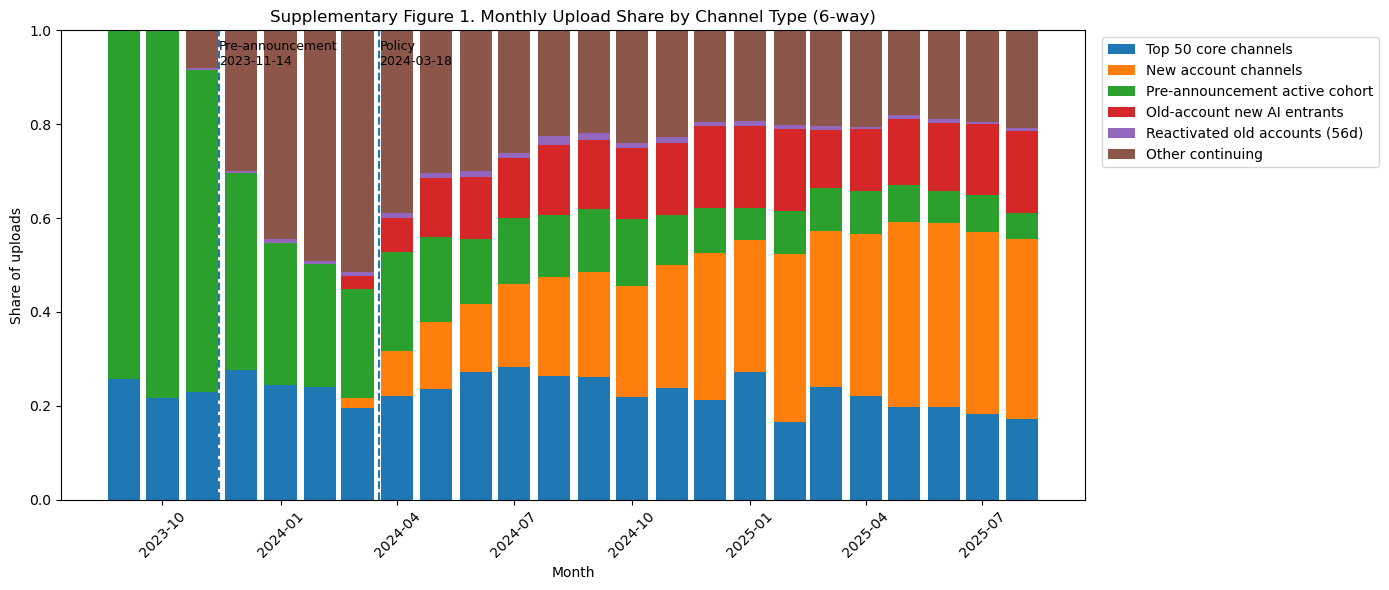

In [123]:
# Plot supplementary 1: monthly 100% stacked bar

fig, ax = plt.subplots(figsize=(14, 6))

bottom = np.zeros(len(supp6_monthly))
x = supp6_monthly.index.tz_localize(None)

label_map_6way = {
    "top50_core": "Top 50 core channels",
    "new_account_channels": "New account channels",
    "pre_announcement_active_cohort": "Pre-announcement active cohort",
    "old_account_new_ai_entrants": "Old-account new AI entrants",
    "reactivated_old_accounts": f"Reactivated old accounts ({REACTIVATION_THRESHOLD_SUPPLY6}d)",
    "other_continuing": "Other continuing"
}

for col in group_order_6way:
    ax.bar(
        x,
        supp6_monthly[col].values,
        bottom=bottom,
        width=25,
        label=label_map_6way[col]
    )
    bottom = bottom + supp6_monthly[col].values

add_policy_lines_supply_comp_6way(ax)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0))

format_axis_supply_comp_6way(
    ax,
    title="Supplementary Figure 1. Monthly Upload Share by Channel Type (6-way)",
    xlabel="Month",
    ylabel="Share of uploads"
)

plt.show()